# SeamlessM4T v2 Large: Structured Compression 2.3B to ~1B

## Compression Pipeline
| Phase | Technique | Paper | Expected |
|-------|-----------|-------|----------|
| 0 | Baseline benchmark | - | reference |
| 1 | Vocabulary/Embedding pruning | Asahi (EMNLP 2023) | -200M |
| 2 | Text encoder removal (S2S-only) | Architecture analysis | -350M |
| 3 | Text decoder iterative layer pruning | Moslem (IWSLT 2025) | -150M |
| 4 | Speech encoder iterative layer pruning | ShortGPT (ACL 2025) | -150M |
| 5 | Width pruning (FLAP on FFN + heads) | FLAP (AAAI 2024) | -200M |
| 6 | T2U model pruning | Iterative layer pruning | -50M |
| 7 | Recovery fine-tuning (LoRA + S2TT CE) | Moslem (IWSLT 2025) | quality up |
| 8 | Final benchmark + paper table | - | - |

## Setup Cells 1-8
Run these at the **start of every** Kaggle session.

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil
import warnings; warnings.filterwarnings('ignore')

# ── Platform detection ────────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE  # safe assumption for this notebook
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

# ── Path layout ───────────────────────────────────────────────────────────────
# Kaggle : rclone syncs to/from gdrive:cse465v5/  ←→  /kaggle/working/
# Colab  : Google Drive is mounted at /content/drive/MyDrive/
#          We work DIRECTLY inside the mounted folder — no copying, no rclone.
GDRIVE_MOUNT   = '/content/drive/MyDrive/cse465v5'   # <-- your Drive folder
KAGGLE_WORK    = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK    if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'

# rclone remote root (Kaggle only — unused on Colab)
GDRIVE_ROOT = 'gdrive:cse465v5'

for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')
print(f'Checkpts : {CKPT_DIR}')

Platform : kaggle
Work dir : /kaggle/working
Checkpts : /kaggle/working/checkpoints


In [2]:
# rclone is only needed on Kaggle. On Colab we use the mounted Drive directly.
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])
else:
    print('Colab: rclone not needed — using mounted Google Drive directly.')
    print(f'Drive path: {GDRIVE_MOUNT}')
    if not os.path.exists('/content/drive/MyDrive'):
        print('WARNING: Drive does not appear to be mounted. Run Cell 22 (drive.mount) first.')
    else:
        print('Drive mount: OK')

rclone v1.73.4


In [3]:
if ON_KAGGLE:
    print('[audio] Syncing audio to rclone remote...')
    r = subprocess.run(
        f'rclone sync "{AUDIO_DIR}/" "{GDRIVE_ROOT}/audio/"',
        shell=True,
        capture_output=True,
        text=True
    )

    if r.returncode != 0:
        print(f'[audio] WARNING: {r.stderr[:300]}')
    else:
        print('[audio] Sync complete.')

else:
    print(f'[audio] Colab: files already in Google Drive at {AUDIO_DIR} (no sync needed)')

[audio] Syncing audio to rclone remote...
[audio] WARNING: 2026/04/12 04:45:59 NOTICE: Config file "/root/.config/rclone/rclone.conf" not found - using defaults
2026/04/12 04:45:59 CRITICAL: Failed to create file system for "gdrive:cse465v5/audio/": didn't find section in config file ("gdrive")



In [4]:
if ON_KAGGLE:
    print('[figures] Syncing figures to rclone remote...')
    r = subprocess.run(
        f'rclone sync "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/"',
        shell=True,
        capture_output=True,
        text=True
    )

    if r.returncode != 0:
        print(f'[figure] WARNING: {r.stderr[:300]}')
    else:
        print('[figure] Sync complete.')

else:
    print(f'[figure] Colab: files already in Google Drive at {FIG_DIR} (no sync needed)')

[figures] Syncing figures to rclone remote...
[figure] WARNING: 2026/04/12 04:46:00 NOTICE: Config file "/root/.config/rclone/rclone.conf" not found - using defaults
2026/04/12 04:46:00 CRITICAL: Failed to create file system for "gdrive:cse465v5/figures/": didn't find section in config file ("gdrive")



In [5]:
# !rm -rf /content/drive

In [6]:
# !fusermount -u /content/drive

In [7]:
# Mount Google Drive — only needed on Colab.
# On Kaggle, rclone handles the remote; skip this cell entirely there.
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted. Working folder: {GDRIVE_MOUNT}')
    # if not os.path.exists(GDRIVE_MOUNT):
    #     os.makedirs(GDRIVE_MOUNT, exist_ok=True)
    #     print(f'Created {GDRIVE_MOUNT}')
    # else:
    #     print(f'Folder exists: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')

Kaggle: skipping Drive mount.


In [8]:
def _get_secret(key):
    """Fetch a secret from Kaggle Secrets or Colab userdata."""
    if ON_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(key)
        except Exception as e:
            raise RuntimeError(f'Kaggle secret {key!r} not found: {e}')
    else:
        try:
            from google.colab import userdata
            return userdata.get(key)
        except Exception as e:
            raise RuntimeError(
                f'Colab secret {key!r} not found. '
                f'Add it via the 🔑 Secrets panel in Colab: {e}')

if ON_KAGGLE:
    # rclone config is only needed on Kaggle
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root:' if r.returncode == 0 else 'rclone FAILED:')
    print(r.stdout[:300] or r.stderr[:300])
else:
    print('Colab: skipping rclone config — using mounted Drive.')
    print(f'Working directory on Drive: {WORK_DIR}')

Drive root:
           0 2026-04-11 05:42:37        -1 .ipynb_checkpoints
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-10 22:10:29        -1 cse465v3
           0 2026-04-10 22:07:51        -1 cse465v3 saved
           0 2026-04-11


In [9]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
], check=True)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 40.0 MB/s eta 0:00:00
All packages installed.


In [10]:
if ON_KAGGLE:
    print('Pulling checkpoints from Google Drive via rclone...')
    r = subprocess.run(
        f'rclone sync {GDRIVE_ROOT}/checkpoints/ {CKPT_DIR}/',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'WARNING: rclone sync failed:\n{r.stderr[:300]}')
    else:
        print('rclone sync OK.')
else:
    print(f'Colab: checkpoints are on mounted Drive at {CKPT_DIR}')
    print('No sync needed — reading directly from Drive.')

files = sorted(os.listdir(CKPT_DIR)) if os.path.isdir(CKPT_DIR) else []
if files:
    print(f'{len(files)} file(s) found:')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>8.1f} MB')
else:
    print('No checkpoints yet.')

Pulling checkpoints from Google Drive via rclone...
rclone sync OK.
15 file(s) found:
  all_summaries_step000000.pt                                  0.0 MB
  phase0_baseline_step000000.pt                                0.0 MB
  phase1_benchmark_step000000.pt                               0.0 MB
  phase1_vocab_step000000.pt                                   0.1 MB
  phase3_benchmark_step000000.pt                               0.0 MB
  phase3_dec_pruning_step000000.pt                             0.0 MB
  phase4_benchmark_step000000.pt                               0.0 MB
  phase4_enc_pruning_step000000.pt                             0.0 MB
  phase5_benchmark_step000000.pt                               0.0 MB
  phase5_flap2_step000000.pt                                   0.0 MB
  phase5_flap_step000000.pt                                    0.0 MB
  phase6_benchmark_step000000.pt                               0.0 MB
  phase6_t2u_pruning_step000000.pt                             0.0 MB
  ph

In [11]:
# os.listdir('/content/drive/MyDrive/cse465v5/checkpoints')

In [12]:
import torch
from datetime import datetime

_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST = 'pruning_manifest.pt'  # optional extra metadata (e.g. T2U removal log copy)

def _rclone_push(local_path, remote_subpath):
    """Push a single file or folder to rclone remote. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab writes directly to Drive — nothing to push
    r = subprocess.run(
        f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_pull_model(stage_name):
    """Pull models/<stage_name> from rclone remote into local MODEL_DIR. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab reads directly from Drive — nothing to pull
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(
        f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

# ── Checkpoint helpers ────────────────────────────────────────────────────────

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')

    # On Kaggle, push to rclone remote so it survives session end
    if ON_KAGGLE:
        _rclone_push(path, 'checkpoints')

    # Prune old local copies
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f):
            os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive(names=None):
    if ON_KAGGLE:
        print('[ckpt] Syncing checkpoints from rclone remote...')
        r = subprocess.run(
            f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR} (no sync needed)')

    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} checkpoint(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

# ── Config sync: make config.json match actual architecture ───────────────────

def _find_layers(component):
    """Find the main transformer-layer ModuleList inside a component."""
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None

def _sync_config_to_architecture(mdl):
    """
    Walk the model, count actual layers / dimensions, and update every
    config field that from_pretrained uses to build the architecture.
    This guarantees the saved config.json matches the saved weights.
    """
    cfg = mdl.config
    updates = {}

    def _set(key, new_val):
        if hasattr(cfg, key) and getattr(cfg, key) != new_val:
            updates[key] = (getattr(cfg, key), new_val)
            setattr(cfg, key, new_val)

    # ── vocab ──
    if hasattr(mdl, 'shared') and hasattr(mdl.shared, 'num_embeddings'):
        _set('vocab_size', mdl.shared.num_embeddings)

    # ── text decoder ──
    if hasattr(mdl, 'text_decoder'):
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            _set('decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('decoder_ffn_dim', first.ffn.fc1.out_features)

    # ── text encoder ──
    if hasattr(mdl, 'text_encoder'):
        layers = _find_layers(mdl.text_encoder)
        if layers is not None:
            _set('encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('encoder_ffn_dim', first.ffn.fc1.out_features)

    # ── speech encoder (nested: speech_encoder.encoder.layers etc.) ──
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        layers = None
        for parent in [enc, getattr(enc, 'encoder', None)]:
            if parent is not None:
                layers = _find_layers(parent)
                if layers is not None:
                    break
        if layers is None:
            for _, child in enc.named_children():
                layers = _find_layers(child)
                if layers is not None:
                    break
        if layers is not None:
            _set('speech_encoder_layers', len(layers))
            first = layers[0]
            for ffn_path in ['ffn', 'feed_forward']:
                ffn = getattr(first, ffn_path, None)
                if ffn is not None:
                    fc = getattr(ffn, 'intermediate_dense', getattr(ffn, 'fc1', None))
                    if fc is not None and hasattr(fc, 'out_features'):
                        _set('speech_encoder_intermediate_size', fc.out_features)
                    break

    # ── T2U model ──
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is not None:
        for sub, key_layers, key_ffn in [
            ('encoder', 't2u_encoder_layers', 't2u_encoder_ffn_dim'),
            ('decoder', 't2u_decoder_layers', 't2u_decoder_ffn_dim'),
        ]:
            comp = getattr(t2u, sub, None)
            if comp is None:
                continue
            layers = _find_layers(comp)
            if layers is not None:
                _set(key_layers, len(layers))
                first = layers[0]
                if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                    _set(key_ffn, first.ffn.fc1.out_features)

    if updates:
        for k, (old, new) in updates.items():
            print(f'  config.{k}: {old} -> {new}')
    return updates

# ── Custom state sidecar (vocab remap, etc.) ──────────────────────────────────

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    """Save non-standard model attributes (e.g. vocab remap) as a sidecar file."""
    state = {}
    for attr in _CUSTOM_ATTR_NAMES:
        if hasattr(mdl, attr):
            state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    """Restore non-standard model attributes from the sidecar file."""
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath):
        return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items():
        setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

# ── device consolidation ──────────────────────────────────────────────────────

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split across devices by device_map='auto'."""
    if hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1:
        print('  Multi-device map detected, consolidating to cuda:0...')
        from accelerate.hooks import remove_hook_from_submodules
        remove_hook_from_submodules(mdl)
        mdl = mdl.to('cuda:0')
        torch.cuda.empty_cache()
        print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl


# ── Model save / load ─────────────────────────────────────────────────────────

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    """
    Save model weights + processor to MODEL_DIR/<stage_name>.

    Why not torch.save(model) alone?
    - HuggingFace needs config.json, tokenizer, preprocessor_config.json,
      generation_config.json, etc. Processor + trimmed vocab (id_to_text,
      lang code maps) live outside nn.Module state_dict.
    - We therefore use save_pretrained (canonical HF layout) and add:
        * _sync_config_to_architecture + sync_model_config so layer counts
          match pruned ModuleLists (avoids MISSING / surprise init on load).
        * _custom_state.pt for non-pickled attrs (_vocab_remap_to_old).
        * pruning_manifest.pt for optional bookkeeping (e.g. T2u removal log).

    manifest_extra: optional dict merged into pruning_manifest.pt (e.g.
        {'t2u_removed': all_removed} for Phase 6).
    """
    target_dir = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target_dir, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target_dir} ...')

    _sync_config_to_architecture(mdl)
    try:
        sync_model_config(mdl)
    except Exception as e:
        print(f'  [model] sync_model_config skipped: {e}')
    _save_custom_state(mdl, target_dir)

    man = {'stage_name': stage_name}
    if manifest_extra:
        man.update(manifest_extra)
    torch.save(man, os.path.join(target_dir, _PRUNING_MANIFEST))
    print(f'  Saved {_PRUNING_MANIFEST} keys={list(man.keys())}')

    try:
        mdl.save_pretrained(target_dir, safe_serialization=True)
    except Exception as e:
        print(f'  [model] safe_serialization failed ({e}); saving .bin')
        mdl.save_pretrained(target_dir)
    proc.save_pretrained(target_dir)

    total = sum(os.path.getsize(f'{target_dir}/{f}')
                for f in os.listdir(target_dir)) / 1e6
    print(f'[model] Local save done. {total:.0f} MB in {len(os.listdir(target_dir))} files.')

    if ON_KAGGLE:
        print(f'[model] Pushing to rclone remote...')
        r = subprocess.run(
            f'rclone sync "{target_dir}/" "{GDRIVE_ROOT}/models/{stage_name}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING: rclone push failed: {r.stderr[:300]}')
        else:
            rv = subprocess.run(
                f'rclone ls "{GDRIVE_ROOT}/models/{stage_name}/"',
                shell=True, capture_output=True, text=True)
            n_remote = len(rv.stdout.strip().splitlines()) if rv.stdout.strip() else 0
            print(f'[model] Verified {n_remote} files on remote.')
    else:
        print(f'[model] Colab: saved directly to Drive. No additional sync needed.')


def load_hf_weights_dict(model_dir):
    """Load flat state_dict from HF save (safetensors or pytorch_model.bin)."""
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            return load_file(safe)
        except ImportError:
            print('  [model] safetensors not installed; cannot read model.safetensors')
    pt = os.path.join(model_dir, 'pytorch_model.bin')
    if os.path.isfile(pt):
        blob = torch.load(pt, map_location='cpu', weights_only=False)
        if isinstance(blob, dict) and 'model' in blob:
            inner = blob['model']
            if isinstance(inner, dict):
                return inner
        return blob
    return None


def load_model_from_drive(stage_name):
    """
    Load a model from MODEL_DIR/<stage_name>.
    - Colab:  reads directly from mounted Drive.
    - Kaggle: checks local cache first; pulls from rclone remote if missing.
    """
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
    local = f'{MODEL_DIR}/{stage_name}'

    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache, pulling from remote...')
        _rclone_pull_model(stage_name)

    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Path not found or empty: {local}')

    weight_files = [f for f in os.listdir(local)
                    if f.endswith('.safetensors') or f.endswith('.bin')]
    if not weight_files:
        raise RuntimeError(f'[model] No weight files in {local}')

    print(f'[model] Loading {stage_name} from {local} ...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    pm = os.path.join(local, _PRUNING_MANIFEST)
    if os.path.isfile(pm):
        meta = torch.load(pm, map_location='cpu', weights_only=False)
        print(f'  [model] pruning_manifest: {list(meta.keys())}')
    mdl.eval()
    return mdl, proc

print('I/O helpers ready.')
print(f'  Platform  : {PLATFORM}')
print(f'  Model dir : {MODEL_DIR}')
print(f'  Ckpt dir  : {CKPT_DIR}')
if ON_KAGGLE:
    print(f'  rclone    : {GDRIVE_ROOT}')
else:
    print(f'  Drive     : mounted at /content/drive, working in {GDRIVE_MOUNT}')


I/O helpers ready.
  Platform  : kaggle
  Model dir : /kaggle/working/models
  Ckpt dir  : /kaggle/working/checkpoints
  rclone    : gdrive:cse465v5


In [13]:
sync_checkpoints_from_drive()

[ckpt] Syncing checkpoints from rclone remote...
[ckpt] 15 checkpoint(s) available
  all_summaries_step000000.pt                                 0.0 MB
  phase0_baseline_step000000.pt                               0.0 MB
  phase1_benchmark_step000000.pt                              0.0 MB
  phase1_vocab_step000000.pt                                  0.1 MB
  phase3_benchmark_step000000.pt                              0.0 MB
  phase3_dec_pruning_step000000.pt                            0.0 MB
  phase4_benchmark_step000000.pt                              0.0 MB
  phase4_enc_pruning_step000000.pt                            0.0 MB
  phase5_benchmark_step000000.pt                              0.0 MB
  phase5_flap2_step000000.pt                                  0.0 MB
  phase5_flap_step000000.pt                                   0.0 MB
  phase6_benchmark_step000000.pt                              0.0 MB
  phase6_t2u_pruning_step000000.pt                            0.0 MB
  phase6_t2u_t2u_mod

In [14]:
import torchaudio, numpy as np
from IPython.display import Audio as IPAudio, display

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename, label=''):
    path = f'{AUDIO_DIR}/{filename}'
    if hasattr(audio, 'numpy'): t = audio.squeeze().unsqueeze(0).float()
    else: t = torch.tensor(audio).unsqueeze(0).float()
    torchaudio.save(path, t, sr)
    mb = os.path.getsize(path) / 1e6
    print(f'[audio] Saved {filename} ({mb:.1f} MB)')

print('Audio helpers ready.')

Audio helpers ready.


In [15]:
import os
import glob
import torch
from datetime import datetime

def session_status():
    print('=' * 60)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')

    # Gathering files from the checkpoint directory
    if os.path.exists(CKPT_DIR):
        local_files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) if os.path.isfile(f)]
        print(f'  Checkpoint files in {CKPT_DIR}: {len(local_files)}')
        for f in sorted(local_files)[:20]:
            rel_path = os.path.relpath(f, CKPT_DIR)
            print(f'    {rel_path:<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    else:
        print(f'  Directory not found: {CKPT_DIR}')

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}')
        print(f'  VRAM: {props.total_memory / 1e9:.1f} GB')

    print('=' * 60)

session_status()

  Platform : kaggle   Time : 2026-04-12 04:46
  Checkpoint files in /kaggle/working/checkpoints: 15
    all_summaries_step000000.pt                             0.0 MB
    phase0_baseline_step000000.pt                           0.0 MB
    phase1_benchmark_step000000.pt                          0.0 MB
    phase1_vocab_step000000.pt                              0.1 MB
    phase3_benchmark_step000000.pt                          0.0 MB
    phase3_dec_pruning_step000000.pt                        0.0 MB
    phase4_benchmark_step000000.pt                          0.0 MB
    phase4_enc_pruning_step000000.pt                        0.0 MB
    phase5_benchmark_step000000.pt                          0.0 MB
    phase5_flap2_step000000.pt                              0.0 MB
    phase5_flap_step000000.pt                               0.0 MB
    phase6_benchmark_step000000.pt                          0.0 MB
    phase6_t2u_pruning_step000000.pt                        0.0 MB
    phase6_t2u_t2u_model_mode

## Core Library: Model, Benchmark, Plotting

In [16]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {}
    for name, child in model.named_children():
        bd[name] = count_params(child)
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved() / 1e9
        print(f'  GPU mem: {a:.2f} GB alloc / {r:.2f} GB reserved')

print('Core utilities ready.')

Core utilities ready.


In [17]:
from sacrebleu.metrics import BLEU, CHRF

_bleu = BLEU(effective_order=True)
_chrf = CHRF()


def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None
    
def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    """Remap trimmed vocab IDs back to original IDs for tokenizer decoding."""
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    """Device where speech inputs should be placed (first speech encoder param)."""
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full S2ST: returns (text, audio_numpy). Falls back to text-only if vocoder fails."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            # Vocoder fails when T2U produces a very short unit sequence (<3 units).
            # Fall back to text-only to still get BLEU/ChrF for this sample.
            text = run_s2t_only(mdl, wav, tgt_lang)
            return text, np.zeros(16000)

# ── Add this function to Cell 13 (alongside run_s2t_only) ────────────────────

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}

    orig_voc = mdl.vocoder
    inp_device = next(iter(inputs.values())).device

    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs):
            return torch.zeros(1, 1, device=inp_device), [1]

    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc

    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]


def sync_model_config(mdl):
    """
    After structural pruning, sync config layer counts to actual module counts.
    Without this, generate()'s beam search indexes past_key_values by layer
    number from config and throws IndexError when layers have been removed.
    """
    # Speech encoder (SeamlessM4Tv2 uses flat config.speech_encoder_layers)
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            if hasattr(mdl.config, 'speech_encoder_layers'):
                old = mdl.config.speech_encoder_layers
                if old != actual:
                    mdl.config.speech_encoder_layers = actual
                    print(f'  [config] speech_encoder_layers: {old} -> {actual}')
            if hasattr(mdl.config, 'speech_encoder_config') and hasattr(
                    mdl.config.speech_encoder_config, 'num_hidden_layers'):
                old = mdl.config.speech_encoder_config.num_hidden_layers
                if old != actual:
                    mdl.config.speech_encoder_config.num_hidden_layers = actual
                    print(f'  [config] speech_encoder_config.num_hidden_layers: {old} -> {actual}')
            subcfg = getattr(mdl.speech_encoder, 'config', None)
            if subcfg is not None and hasattr(subcfg, 'num_hidden_layers'):
                old2 = subcfg.num_hidden_layers
                if old2 != actual:
                    subcfg.num_hidden_layers = actual
                    print(f'  [config] speech_encoder.config.num_hidden_layers: {old2} -> {actual}')

    # Text decoder
    if hasattr(mdl, 'text_decoder'):
        dec = mdl.text_decoder
        la = find_layers_attr(dec)
        if la:
            actual = len(getattr(dec, la))
            if hasattr(mdl.config, 'decoder_layers'):
                old = mdl.config.decoder_layers
                if old != actual:
                    mdl.config.decoder_layers = actual
                    print(f'  [config] decoder_layers: {old} -> {actual}')
            # also patch text_decoder config if it has its own
            if hasattr(dec, 'config') and hasattr(dec.config, 'decoder_layers'):
                dec.config.decoder_layers = actual

    # T2U model
    if hasattr(mdl, 't2u_model'):
        for sub_name in ['encoder', 'decoder']:
            sub = getattr(mdl.t2u_model, sub_name, None)
            if sub is None: continue
            la = find_layers_attr(sub)
            if la:
                actual = len(getattr(sub, la))
                cfg_key = f't2u_{sub_name}_layers'
                if hasattr(mdl.config, cfg_key):
                    old = getattr(mdl.config, cfg_key)
                    if old != actual:
                        setattr(mdl.config, cfg_key, actual)
                        print(f'  [config] {cfg_key}: {old} -> {actual}')

    print('  [config] sync done.')

def remap_label_ids(token_ids, mdl):
    """
    Map tokenizer output IDs (original tokenizer space) -> trimmed model embedding space.
    Supports [seq_len] or [batch, seq_len]. Positions already -100 stay -100.
    """
    if not hasattr(mdl, '_vocab_remap_to_old'):
        return token_ids
    remap = mdl._vocab_remap_to_old
    old_to_new = {old.item(): new for new, old in enumerate(remap)}
    if token_ids.dim() == 1:
        return torch.tensor(
            [(-100 if t in (-100, -1) else old_to_new.get(t, -100))
             for t in token_ids.tolist()],
            dtype=token_ids.dtype, device=token_ids.device)
    out = token_ids.clone()
    for bi in range(out.shape[0]):
        for j in range(out.shape[1]):
            t = out[bi, j].item()
            if t in (-100, -1):
                continue
            out[bi, j] = old_to_new.get(t, -100)
    return out

def run_benchmark(mdl, samples, label='model', tgt_lang='ben', save_n=4):
    """
    Benchmark using text-only generation for BLEU/ChrF/RTF (fast, no vocoder).
    Full S2ST is only run for the first save_n samples to save audio clips.
    RTF reflects the speech-encoder + text-decoder cost, which is what matters
    for quality-per-compute comparisons across pruning phases.
    """
    print(f'\n{"="*60}\n  BENCHMARK: {label}\n  Samples: {len(samples)}  Target: {tgt_lang}\n{"="*60}\n')
    gpu_mem()
    results = []
    for i, s in enumerate(samples):
        try:
            dur = len(s['wav']) / 16000
            t0 = time.time()
            pred_text = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf  = elapsed / dur
            bleu = compute_bleu(pred_text, s['ref'])
            chrf = compute_chrf(pred_text, s['ref'])
            print(f'  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}  id={s["id"]}')
            print(f'              pred: {pred_text[:80]}')
            if save_n > 0 and i < save_n:
                _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                save_audio(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                play(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                save_audio(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
                play(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
            results.append(dict(id=s['id'], bleu=bleu, chrf=chrf, rtf=rtf, pred=pred_text, ref=s['ref']))
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'  [{i+1:>2}/{len(samples)}] ERROR: {e}')
            results.append(dict(id=s['id'], bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r['rtf'] for r in valid])) if valid else 0,
        params_M=count_params(mdl))
    print(f'\n  Summary: BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M\n')
    return results, summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_samples=10):
    """Fast ChrF eval (text-only). For iterative pruning decisions."""
    scores = []
    for s in samples[:max_samples]:
        try: scores.append(compute_chrf(run_s2t_only(mdl, s['wav'], tgt_lang), s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores))

print('Benchmark functions ready.')


Benchmark functions ready.


In [18]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

# Login to HuggingFace only if token is available (needed on Kaggle; Colab may cache it)
try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('Logged into HuggingFace Hub.')
except Exception as e:
    print(f'HF login skipped (token not found or already cached): {e}')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'

def load_base_model():
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model  -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    return mdl, proc

print('load_base_model() ready.')

Logged into HuggingFace Hub.
load_base_model() ready.


In [19]:
def _load_summaries_from_drive():
    """Pull the summary ledger from Drive once at session start."""
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES: dict = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    """Upsert by label: insert new or update existing, then persist to Drive."""
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    ordered = list(ALL_SUMMARIES.values())
    save_checkpoint({'summaries': ordered}, name='all_summaries', step=0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    """Return summaries as an ordered list (by label) for plotting."""
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Compression Pipeline: Phase Comparison', fontsize=15, fontweight='bold')
    metrics = [('avg_bleu', 'BLEU (higher=better)', '#2196F3'),
               ('avg_chrf', 'ChrF (higher=better)', '#4CAF50'),
               ('avg_rtf',  'RTF (lower=faster)', '#FF9800'),
               ('params_M', 'Parameters (M)', '#9C27B0')]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_size_vs_quality(summaries=None, save_name='size_vs_quality.png'):
    data = summaries or get_summaries()
    if not data: return
    fig, ax = plt.subplots(figsize=(10, 7))
    params = [s['params_M'] for s in data]
    bleu = [s['avg_bleu'] for s in data]
    chrf = [s['avg_chrf'] for s in data]
    ax.scatter(params, bleu, s=120, c='#2196F3', zorder=5, label='BLEU')
    ax.scatter(params, chrf, s=120, c='#4CAF50', marker='s', zorder=5, label='ChrF')
    for i, lbl in enumerate([s['label'] for s in data]):
        ax.annotate(lbl, (params[i], bleu[i]), fontsize=7, xytext=(5,5), textcoords='offset points')
    ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
    ax.set_title('Model Size vs Translation Quality', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_layer_scores(scores_dict, title='Layer Importance', save_name=None):
    indices = sorted(scores_dict.keys())
    vals = [scores_dict[i] for i in indices]
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#d32f2f' if v > np.percentile(vals, 75) else '#ff9800' if v > np.percentile(vals, 50) else '#4caf50' if v > np.percentile(vals, 25) else '#90caf9' for v in vals]
    ax.bar(indices, vals, color=colors, edgecolor='white')
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold'); ax.set_xticks(indices)
    plt.tight_layout()
    if save_name: plt.savefig(f'{FIG_DIR}/{save_name}')
    plt.show()

print('Plotting helpers ready.')

[ckpt] Loaded all_summaries_step000000.pt
Loaded 6 existing summaries: ['P0_Baseline', 'P1_VocabTrim', 'P3_DecPrune', 'P4_EncPrune', 'P5_FLAP', 'P6_T2UIter']
Plotting helpers ready.


---
# Phase 0: Baseline Benchmark
Load the full teacher model, measure size and translation quality.

In [20]:
model, processor = load_base_model()
baseline_breakdown = print_model_breakdown(model, 'Baseline Model')

Loading processor from facebook/seamless-m4t-v2-large...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.v_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.weight   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias         | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded.
  GPU mem: 1.79 GB alloc / 1.80 GB reserved

--- Baseline Model ---
  text_decoder                           866.8M  ( 48.0%)
  speech_encoder                         635.0M  ( 35.2%)
  shared                                 262.2M  ( 14.5%)
  lm_head                                262.2M  ( 14.5%)
  t2u_model                              261.8M  ( 14.5%)
  vocoder                                 41.9M  (  2.3%)
  TOTAL                                 1805.5M
---


In [21]:
import numpy as np
import torch
import torchaudio
from datasets import load_dataset

TARGET_LANG = "ben"
FLEURS_SRC, FLEURS_TGT = "en_us", "bn_in"
N_EVAL = 25

BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"

print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} ({N_EVAL} samples)")

ds_src = load_dataset(
    "parquet",
    data_files=f"{BASE}/{FLEURS_SRC}/test/*.parquet",
    split="train",
    streaming=True
)

ds_tgt = load_dataset(
    "parquet",
    data_files=f"{BASE}/{FLEURS_TGT}/test/*.parquet",
    split="train",
    streaming=True
)

# build small dictionaries only for needed items
src_by_id = {}
tgt_by_id = {}

for ex in ds_src:
    src_by_id[ex["id"]] = ex
    if len(src_by_id) >= N_EVAL * 5:
        break

for ex in ds_tgt:
    tgt_by_id[ex["id"]] = ex
    if len(tgt_by_id) >= N_EVAL * 5:
        break

common_ids = sorted(set(src_by_id) & set(tgt_by_id))[:N_EVAL]

eval_samples = []

for sid in common_ids:
    wav = np.array(src_by_id[sid]["audio"]["array"], dtype=np.float32)
    sr = src_by_id[sid]["audio"]["sampling_rate"]

    if sr != 16000:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, 16000
        ).numpy()

    eval_samples.append(
        dict(
            id=sid,
            wav=wav,
            ref=tgt_by_id[sid]["transcription"],
            en_text=src_by_id[sid]["transcription"]
        )
    )

print(f"Loaded {len(eval_samples)} eval samples.")

Loading FLEURS en_us->bn_in (25 samples)
Loaded 25 eval samples.


In [22]:
# import shutil
# import os

# folder = "/kaggle/working/checkpoints"

# if os.path.exists(folder):
#     shutil.rmtree(folder)   # deletes the folder and everything inside it
#     os.makedirs(folder)     # recreate empty folder

[ckpt] Loaded phase0_baseline_step000000.pt
Loaded baseline: BLEU=11.94
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P0_Baseline (6 total)


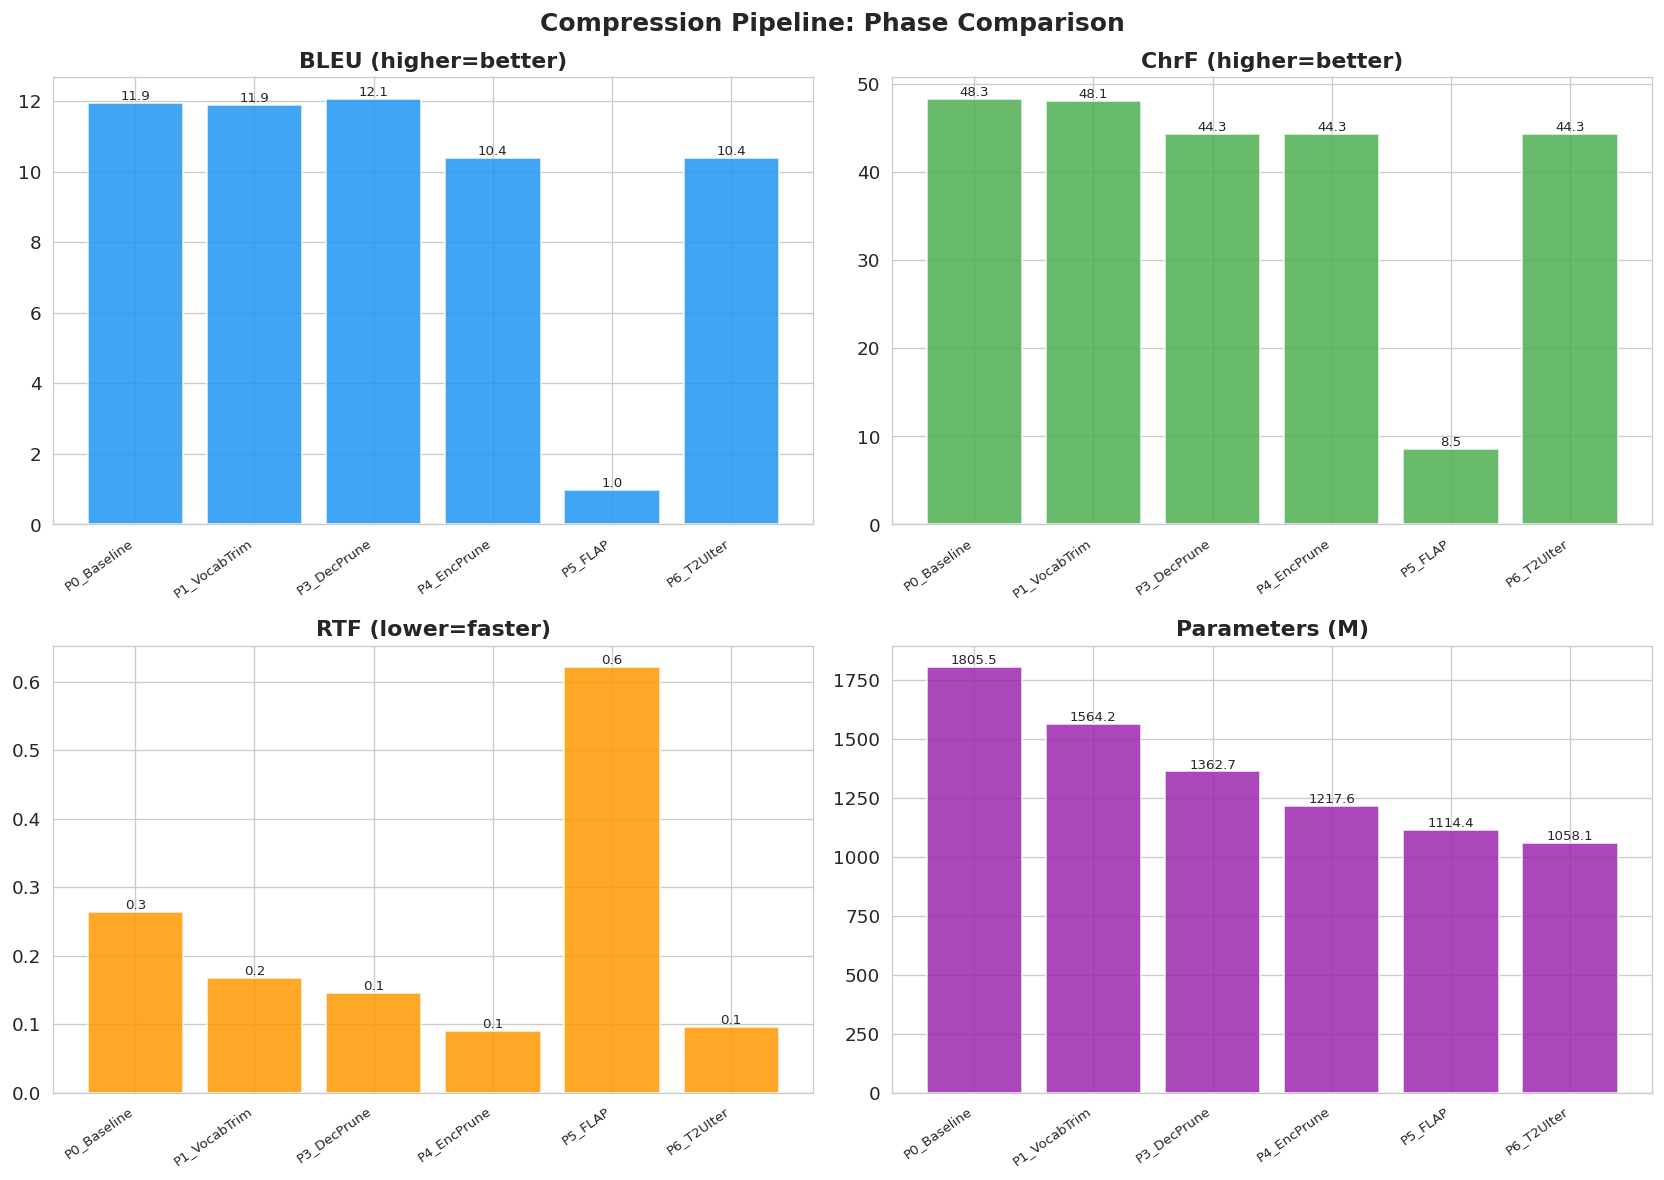

In [23]:
baseline_ckpt = load_latest_checkpoint('phase0_baseline')
if baseline_ckpt:
    baseline_results = baseline_ckpt['results']
    baseline_summary = baseline_ckpt['summary']
    print(f'Loaded baseline: BLEU={baseline_summary["avg_bleu"]:.2f}')
else:
    baseline_results, baseline_summary = run_benchmark(
        model, eval_samples, label='P0_Baseline', save_n=2)
    save_checkpoint(dict(results=baseline_results, summary=baseline_summary,
                         breakdown=baseline_breakdown), name='phase0_baseline', step=0)

store_summary(baseline_summary)
plot_phase_comparison()

---
# Phase 1: Vocabulary / Embedding Pruning
**Paper:** Asahi et al. (EMNLP 2023)

NLLB vocabulary has **256,102 tokens** for ~100 languages.
We keep only ~5-7 languages. Trimming saves ~200M params with near-zero quality impact.

In [74]:
def identify_used_tokens(proc, target_lang_codes, n_corpus=2000):
    from datasets import load_dataset
    fleurs_codes = dict(eng='en_us', ben='bn_in', cmn='cmn_hans_cn',
                        fra='fr_fr', deu='de_de', hin='hi_in', urd='ur_pk')
    BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"
    used = set()
    tok = proc.tokenizer
    if hasattr(tok, 'all_special_ids'): used.update(tok.all_special_ids)
    for tid in range(len(tok)):
        t = tok.convert_ids_to_tokens(tid)
        if t and t.startswith('__') and t.endswith('__'): used.add(tid)
    for lang, fc in fleurs_codes.items():
        if lang not in target_lang_codes: continue
        print(f'  Scanning {lang} ({fc})...')
        try:
            ds = load_dataset("parquet",
                              data_files={"train": f"{BASE}/{fc}/train/*.parquet"},
                              split="train")
            for i, ex in enumerate(ds):
                if i >= n_corpus: break
                text = ex.get('transcription', '')
                if text: used.update(tok.encode(text, add_special_tokens=False))
        except Exception as e:
            print(f'    Warning: {lang}: {e}')
    print(f'  Unique tokens: {len(used)} / {len(tok)}')
    return sorted(used)


def trim_vocabulary(mdl, proc, keep_ids):
    """
    Trim the NLLB text vocabulary to only the kept token IDs.

    Correctly handles:
    - SeamlessM4Tv2ScaledWordEmbedding (preserves embed_scale for decoder)
    - generation_config.id_to_text mapping (required by T2U _indices_to_subwords)
    - Tied weights: shared <-> text_decoder.embed_tokens <-> lm_head
    - Correct padding_idx remapping from old to new ID space

    Based on Asahi et al. (EMNLP 2023) vocabulary trimming methodology.
    """
    keep_t = torch.tensor(keep_ids, dtype=torch.long)
    old_v = mdl.config.vocab_size
    new_v = len(keep_ids)
    hidden = mdl.config.hidden_size
    print(f'  Vocabulary: {old_v} -> {new_v} ({new_v/old_v*100:.1f}%)')

    old_shared = mdl.shared
    if old_shared.num_embeddings != old_v:
        print(f'  ERROR: shared.num_embeddings={old_shared.num_embeddings}, '
              f'expected {old_v}. Reload base model first.')
        return mdl

    dev = old_shared.weight.device
    dtype = old_shared.weight.dtype
    keep_t_dev = keep_t.to(dev)

    old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}

    old_pad = old_shared.padding_idx
    new_pad = old_to_new.get(old_pad) if old_pad is not None else None
    if old_pad is not None and new_pad is None:
        print(f'  WARNING: pad token {old_pad} not in keep_ids!')

    embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)
    print(f'  text_decoder.embed_tokens.embed_scale = {embed_scale}')

    # --- 1. Create trimmed shared embedding ---
    new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
    new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
    mdl.shared = new_shared.to(device=dev, dtype=dtype)
    print(f'  shared: [{old_v}, {hidden}] -> [{new_v}, {hidden}]')

    # --- 2. Update text_decoder.embed_tokens IN-PLACE ---
    # Keeps the SeamlessM4Tv2ScaledWordEmbedding class and its embed_scale.
    # The original forward() multiplies by embed_scale ~32.0;
    # replacing with plain nn.Embedding would lose this scaling entirely.
    dec_emb = mdl.text_decoder.embed_tokens
    dec_emb.weight = mdl.shared.weight
    dec_emb.num_embeddings = new_v
    dec_emb.padding_idx = new_pad
    print(f'  text_decoder.embed_tokens: tied to shared, embed_scale={dec_emb.embed_scale}')

    # --- 3. Handle text_encoder.embed_tokens if present ---
    if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
        enc_emb = getattr(mdl.text_encoder, 'embed_tokens', None)
        if enc_emb is not None:
            enc_emb.weight = mdl.shared.weight
            enc_emb.num_embeddings = new_v
            enc_emb.padding_idx = new_pad
            print(f'  text_encoder.embed_tokens: tied to shared')

    # --- 4. Tie lm_head to shared (preserves original tied-weight architecture) ---
    mdl.lm_head.weight = mdl.shared.weight
    mdl.lm_head.out_features = new_v
    if mdl.lm_head.bias is not None:
        mdl.lm_head.bias = nn.Parameter(mdl.lm_head.bias.data[keep_t_dev].clone())
    print(f'  lm_head: tied to shared [{new_v}, {hidden}]')

    # --- 5. Update model config ---
    mdl.config.vocab_size = new_v
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id', 'decoder_start_token_id']:
        old_id = getattr(mdl.config, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(mdl.config, attr, old_to_new[old_id])

    if hasattr(mdl.text_decoder, 'vocab_size'):
        mdl.text_decoder.vocab_size = new_v
    if hasattr(mdl.text_decoder, 'padding_idx'):
        mdl.text_decoder.padding_idx = new_pad
    print(f'  config: vocab_size={new_v}')

    # --- 6. Update generation_config ---
    # Use `gen_cfg` (not `gc`) so we never shadow Python's garbage-collector module.
    gen_cfg = mdl.generation_config

    # 6a. text_decoder_lang_to_code_id (lang -> text-vocab token ID for decoder_input)
    if hasattr(gen_cfg, 'text_decoder_lang_to_code_id') and gen_cfg.text_decoder_lang_to_code_id:
        gen_cfg.text_decoder_lang_to_code_id = {
            lang: old_to_new[oid]
            for lang, oid in gen_cfg.text_decoder_lang_to_code_id.items()
            if oid in old_to_new
        }
        print(f'  text_decoder_lang_to_code_id: {len(gen_cfg.text_decoder_lang_to_code_id)} langs')

    # 6b. id_to_text (CRITICAL for T2U character-level input)
    #     generate() calls _indices_to_subwords(t2u_input_ids) which does:
    #       id_to_text.get(str(token_id)) for each generated text token
    #     Without remapping, every lookup returns None -> T2U gets garbage chars
    if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
        old_map = gen_cfg.id_to_text
        new_map = {}
        for key_str, text_val in old_map.items():
            old_id = int(key_str)
            if old_id in old_to_new:
                new_map[str(old_to_new[old_id])] = text_val
        gen_cfg.id_to_text = new_map
        print(f'  id_to_text: {len(old_map)} -> {len(new_map)} entries')
    else:
        print(f'  WARNING: no id_to_text in generation_config (T2U may fail for S2ST)')

    # 6c. Special token IDs in generation_config
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id',
                 'decoder_start_token_id', 'forced_bos_token_id']:
        old_id = getattr(gen_cfg, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(gen_cfg, attr, old_to_new[old_id])
    print(f'  generation_config special tokens remapped')

    # --- 7. Store remap for decode-time NEW->OLD conversion ---
    # _remap_ids_for_decode() maps model output (new IDs) back to original tokenizer
    # IDs for batch_decode. The tokenizer itself stays in original ID space.
    mdl._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)

    saved_params = (old_v - new_v) * hidden / 1e6
    print(f'  Done: ~{saved_params:.0f}M shared-embedding params removed '
          f'(lm_head tied, not double-counted)')
    return mdl


print('Vocab trimming functions ready.')


Vocab trimming functions ready.


In [25]:
try:
    model_p1, processor = load_model_from_drive('phase1_vocab_trimmed')
    p1_ckpt = load_latest_checkpoint('phase1_vocab')
    if p1_ckpt and 'keep_ids' in p1_ckpt:
        keep_ids = p1_ckpt['keep_ids']
        model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
        print(f'  Restored vocab remap ({len(keep_ids)} tokens)')

        # Validate id_to_text was correctly remapped (guards against stale saves
        # from the old broken trim_vocabulary that didn't remap id_to_text)
        gen_cfg = model_p1.generation_config
        if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
            max_key = max(int(k) for k in gen_cfg.id_to_text.keys())
            if max_key >= model_p1.config.vocab_size:
                print(f'  WARNING: id_to_text has stale keys (max={max_key} >= vocab_size={model_p1.config.vocab_size})')
                print(f'  Re-remapping id_to_text from checkpoint keep_ids...')
                old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
                old_map = gen_cfg.id_to_text
                new_map = {}
                for key_str, text_val in old_map.items():
                    old_id = int(key_str)
                    if old_id in old_to_new:
                        new_map[str(old_to_new[old_id])] = text_val
                gen_cfg.id_to_text = new_map
                print(f'  Fixed id_to_text: {len(old_map)} -> {len(new_map)} entries')
    print('Loaded Phase 1 model from Drive.')
except Exception as e:
    print(f'Load failed ({e}), running vocab trimming...')
    if model.config.vocab_size != 256102:
        print(f'  Model vocab is {model.config.vocab_size}, expected 256102. Reloading base model...')
        model, processor = load_base_model()
    TARGET_LANGS = ['eng', 'ben', 'cmn', 'fra', 'hin']
    keep_ids = identify_used_tokens(processor, TARGET_LANGS)
    pre = count_params(model)
    model = trim_vocabulary(model, processor, keep_ids)
    post = count_params(model)
    print(f'  Params: {pre:.1f}M to {post:.1f}M (saved {pre-post:.1f}M)')
    save_checkpoint(dict(keep_ids=keep_ids, pre=pre, post=post), name='phase1_vocab', step=0)
    save_model_to_drive(model, processor, 'phase1_vocab_trimmed')
    model_p1 = model

print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed')


[model] Not in local cache, pulling from remote...
[rclone] Pulled phase1_vocab_trimmed → /kaggle/working/models/phase1_vocab_trimmed
[model] Loading phase1_vocab_trimmed from /kaggle/working/models/phase1_vocab_trimmed ...


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
[ckpt] Loaded phase1_vocab_step000000.pt
  Restored vocab remap (20425 tokens)
Loaded Phase 1 model from Drive.

--- After Phase 1: Vocab Trimmed ---
  speech_encoder                         635.0M  ( 40.6%)
  text_decoder                           625.5M  ( 40.0%)
  t2u_model                              261.8M  ( 16.7%)
  vocoder                                 41.9M  (  2.7%)
  shared                                  20.9M  (  1.3%)
  lm_head                                 20.9M  (  1.3%)
  TOTAL                                 1564.2M
---


{'shared': 20.9152,
 'speech_encoder': 635.04672,
 'text_decoder': 625.462272,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1564.180101}

[ckpt] Loaded phase1_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P1_VocabTrim (6 total)


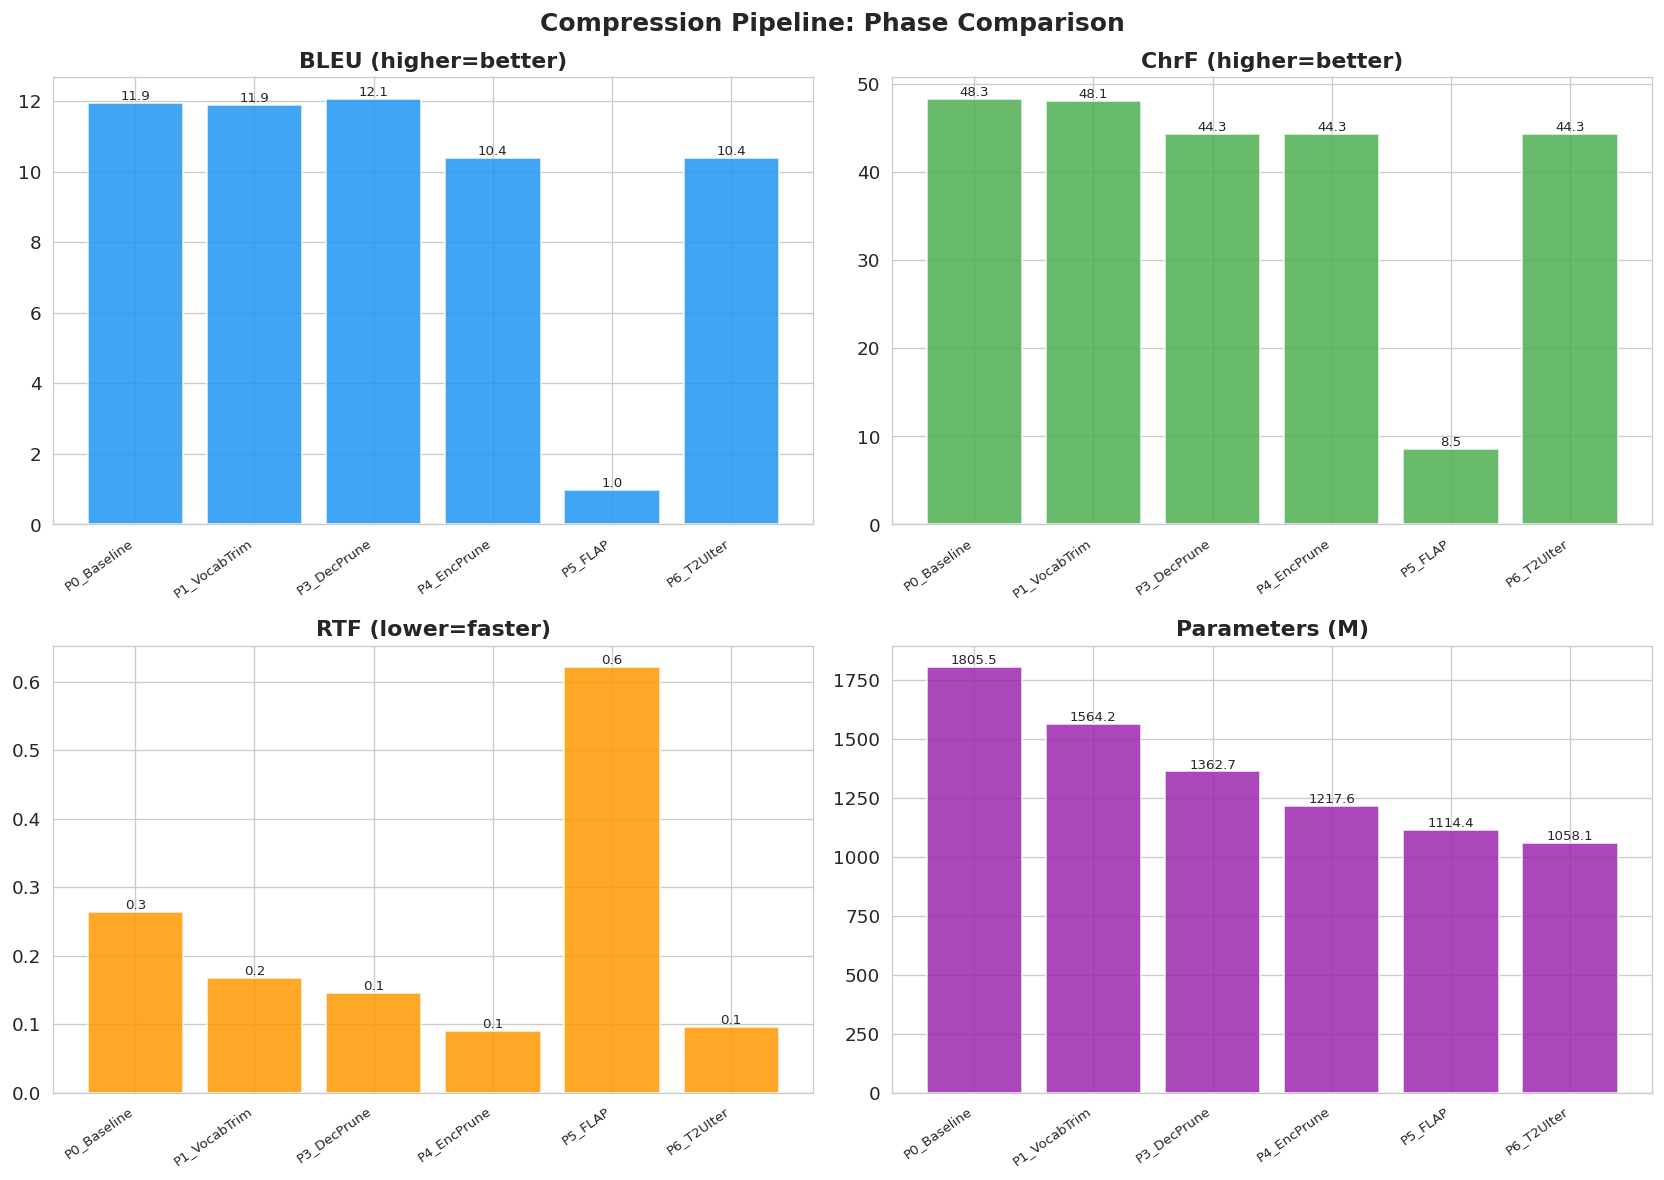

In [26]:
# for f in glob.glob(f'{CKPT_DIR}/phase1_benchmark_step*.pt'):
#     os.remove(f); print(f'Deleted stale: {f}')

p1_ckpt = load_latest_checkpoint('phase1_benchmark')
if p1_ckpt and p1_ckpt['summary'].get('avg_bleu', 0) > 0:
    p1_results, p1_summary = p1_ckpt['results'], p1_ckpt['summary']
else:
    p1_results, p1_summary = run_benchmark(model_p1, eval_samples, label='P1_VocabTrim', save_n=2)
    save_checkpoint(dict(results=p1_results, summary=p1_summary), name='phase1_benchmark', step=0)
store_summary(p1_summary)
plot_phase_comparison()

In [27]:
# run_benchmark(model_p1, eval_samples, label='P1_VocabTrim', save_n=2)
# import shutil
# stale = f'{MODEL_DIR}/phase1_vocab_trimmed'
# if os.path.exists(stale):
#     shutil.rmtree(stale)
#     print(f'Deleted stale: {stale}')
# # Also clear from Drive:
# subprocess.run(f'rclone delete {GDRIVE_ROOT}/phase1_vocab_trimmed/', shell=True)

---
# Phase 2: Text Encoder Removal
# Actually it was never in the first place, we never loaded the textEncoder as we are using
# from transformers import SeamlessM4Tv2ForSpeechToSpeech
For S2S, the pipeline is: Speech Encoder -> Text Decoder -> T2U -> Vocoder.
The text_encoder is only used for T2T/T2S tasks. We verify and remove it.

In [28]:
# def check_text_encoder_used(mdl):
#     if not hasattr(mdl, 'text_encoder') or mdl.text_encoder is None:
#         print('  text_encoder not present.'); return False
#     called = [False]
#     def hook(mod, inp, out): called[0] = True
#     h = mdl.text_encoder.register_forward_hook(hook)
#     try: _ = run_s2st(mdl, np.random.randn(48000).astype(np.float32), 'ben')
#     except: pass
#     h.remove()
#     return called[0]

# def remove_text_encoder(mdl):
#     if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
#         enc_p = count_params(mdl.text_encoder)
#         del mdl.text_encoder; mdl.text_encoder = None
#         _stdlib_gc.collect(); torch.cuda.empty_cache()
#         print(f'  Removed text_encoder ({enc_p:.1f}M params)')
#     return mdl

# print('Text encoder analysis ready.')

In [29]:
# try:
#     model_p2, processor = load_model_from_drive('phase2_no_text_enc')
#     print('Loaded Phase 2 from Drive.')
# except:
#     model_p2 = model_p1
#     used = check_text_encoder_used(model_p2)
#     print(f'  text_encoder used in S2S: {used}')
#     if not used:
#         print('  Safe to remove for S2S-only.')
#         model_p2 = remove_text_encoder(model_p2)
#     else:
#         print('  text_encoder IS used. Keeping 8 of 24 layers.')
#         layers = model_p2.text_encoder.layers
#         keep = list(range(4)) + list(range(len(layers)-4, len(layers)))
#         model_p2.text_encoder.layers = nn.ModuleList([layers[i] for i in keep])
#     save_model_to_drive(model_p2, processor, 'phase2_no_text_enc')

# print_model_breakdown(model_p2, 'After Phase 2: Text Encoder Removed')

In [30]:
# p2_ckpt = load_latest_checkpoint('phase2_benchmark')
# if p2_ckpt:
#     p2_results, p2_summary = p2_ckpt['results'], p2_ckpt['summary']
# else:
#     p2_results, p2_summary = run_benchmark(model_p2, eval_samples, label='P2_NoTextEnc', save_n=2)
#     save_checkpoint(dict(results=p2_results, summary=p2_summary), name='phase2_benchmark', step=0)
# store_summary(p2_summary)
# plot_phase_comparison()

---
# Phase 3: Text Decoder Iterative Layer Pruning
**Paper:** Moslem (IWSLT 2025), CULL-MT (2024)

Iterative greedy pruning: remove one layer at a time, evaluate ChrF, repeat.
Target: remove 6-8 of 24 text decoder layers.

In [31]:
# def find_layers_attr(component):
#     for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
#         if hasattr(component, attr): return attr
#     return None

def _get_protected_indices(n_total):
    """
    Custom protection rule:
      - First layer  (index 0)
      - Last layer   (index n_total - 1)
      - Middle layer (index n_total // 2)
    Returns a set of original indices that must never be pruned.
    """
    first  = 0
    last   = n_total - 1
    middle = n_total // 2
    protected = {first, last, middle}
    print(f'  Protected layers (first/mid/last): {sorted(protected)}')
    return protected

def iterative_layer_prune(mdl, component_name, samples, n_remove,
                          tgt_lang='ben', max_eval=10,
                          ckpt_name='phase3_dec_pruning'):
    """
    Iterative greedy layer pruning (Moslem, IWSLT 2025).
    Custom rule: never prune the first, last, or middle layer.
    Removes one layer per iteration, picking the candidate whose removal
    causes the LEAST ChrF degradation (highest remaining ChrF).
    Saves checkpoint after every iteration.
    """
    parent = getattr(mdl, component_name)
    layers_attr = find_layers_attr(parent)
    if layers_attr is None:
        print(f'  No layers found on {component_name}'); return [], []
    current = list(getattr(parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)
    removed, log = [], []

    # ── Protected indices (never prunable) ──
    protected = _get_protected_indices(n_total_orig)

    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = partial['removed']
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        # Eligible candidates: not in protected set, not already removed
        eligible = [idx for idx in range(len(current))
                    if orig_indices[idx] not in protected]
        if not eligible:
            print(f'  WARNING: No eligible (non-protected) layers left to prune! Stopping.')
            break

        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
              f'{len(eligible)} eligible candidates)')
        scores = {}
        for idx in eligible:
            temp = current[:idx] + current[idx+1:]
            setattr(parent, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[idx] = (orig_indices[idx], sc)
            orig_label = orig_indices[idx]
            prot_note = ' [PROTECTED-skip]' if orig_label in protected else ''
            print(f'    Remove L{orig_label:>2} -> ChrF={sc:.2f}{prot_note}')
        setattr(parent, layers_attr, nn.ModuleList(current))

        # Pick the eligible candidate causing the least harm
        best_idx = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_idx]
        current.pop(best_idx)
        orig_indices.pop(best_idx)
        setattr(parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed layer {best_orig} (ChrF={best_sc:.2f})')
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')

    return removed, log

print('iterative_layer_prune() with first/mid/last protection ready.')

iterative_layer_prune() with first/mid/last protection ready.


In [32]:
# ── Phase 3: Text Decoder Iterative Layer Pruning ────────────────────────────
# Text decoder has 24 layers. Protected: L0, L12, L23.
# We remove 8 of the remaining 21 eligible layers.
N_DEC_REMOVE = 8   # ← increased from 6

p3_ckpt = load_latest_checkpoint('phase3_dec_pruning')
p3_complete = p3_ckpt and len(p3_ckpt.get('removed', [])) >= N_DEC_REMOVE

if p3_complete:
    removed_dec = p3_ckpt['removed']; p3_log = p3_ckpt['log']
    print(f'Phase 3 complete: removed {removed_dec}')
    try:
        model_p3, processor = load_model_from_drive('phase3_dec_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p1...')
        model_p3 = model_p1
        parent = model_p3.text_decoder
        la = find_layers_attr(parent)
        cur = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_dec]
        setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
        # Critical: Sync config before saving or using
        sync_model_config(model_p3)
        save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')
else:
    done_so_far = len(p3_ckpt['removed']) if p3_ckpt else 0
    print(f'{"Resuming" if done_so_far else "Running"} Phase 3: '
          f'decoder pruning ({done_so_far}/{N_DEC_REMOVE} done)...')
    model_p3 = _consolidate_to_single_gpu(model_p1)
    removed_dec, p3_log = iterative_layer_prune(
        model_p3, 'text_decoder', eval_samples, N_DEC_REMOVE, TARGET_LANG,
        ckpt_name='phase3_dec_pruning')
    # Sync config after pruning is finished
    sync_model_config(model_p3)
    save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')

print(f'Decoder layers removed: {removed_dec}')
print_model_breakdown(model_p3, 'After Phase 3: Decoder Pruned')

[ckpt] Loaded phase3_dec_pruning_step000000.pt
Phase 3 complete: removed [2, 14, 6, 7, 15, 22, 8, 4]
[model] Not in local cache, pulling from remote...
[rclone] Pulled phase3_dec_pruned → /kaggle/working/models/phase3_dec_pruned
[model] Loading phase3_dec_pruned from /kaggle/working/models/phase3_dec_pruned ...


Loading weights:   0%|          | 0/1638 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
Decoder layers removed: [2, 14, 6, 7, 15, 22, 8, 4]

--- After Phase 3: Decoder Pruned ---
  speech_encoder                         635.0M  ( 46.6%)
  text_decoder                           423.9M  ( 31.1%)
  t2u_model                              261.8M  ( 19.2%)
  vocoder                                 41.9M  (  3.1%)
  shared                                  20.9M  (  1.5%)
  lm_head                                 20.9M  (  1.5%)
  TOTAL                                 1362.7M
---


{'shared': 20.9152,
 'speech_encoder': 635.04672,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1362.665093}

In [33]:
model_p3, processor = None, None

In [34]:
model_p3, processor = load_model_from_drive('phase3_dec_pruned')

[model] Loading phase3_dec_pruned from /kaggle/working/models/phase3_dec_pruned ...


Loading weights:   0%|          | 0/1638 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']


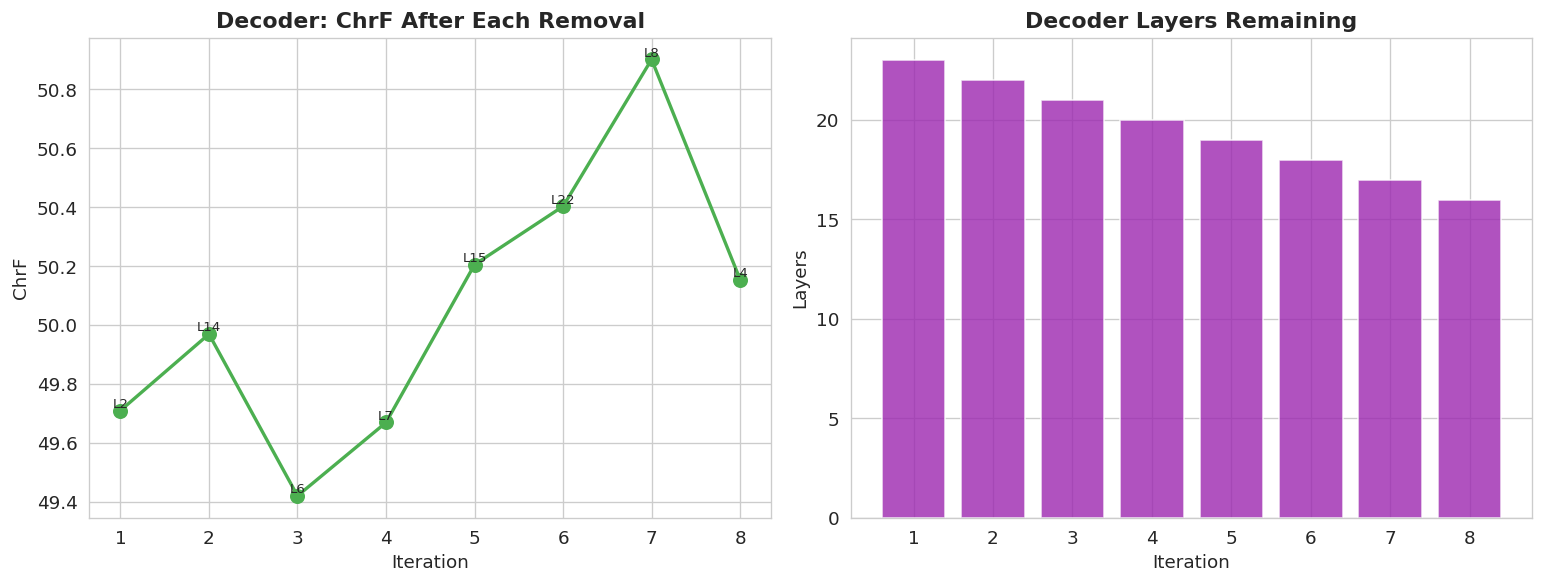

In [35]:
if p3_log:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    iters = [e['iter'] for e in p3_log]
    chrfs = [e['chrf'] for e in p3_log]
    ax1.plot(iters, chrfs, 'o-', color='#4CAF50', lw=2, ms=8)
    for e in p3_log: ax1.annotate(f'L{e["removed"]}', (e['iter'], e['chrf']), fontsize=8, ha='center', va='bottom')
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('ChrF'); ax1.set_title('Decoder: ChrF After Each Removal', fontweight='bold')
    ax2.bar(iters, [e['remaining'] for e in p3_log], color='#9C27B0', alpha=0.8)
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Layers'); ax2.set_title('Decoder Layers Remaining', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase3_dec.png'); plt.show()

In [36]:
[layer.self_attn.layer_idx for layer in model_p3.text_decoder.layers]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [37]:
def reindex_text_decoder_layer_idx(mdl):
    dec = mdl.text_decoder
    for i, layer in enumerate(dec.layers):
        layer.self_attn.layer_idx = i
        layer.cross_attention.layer_idx = i

reindex_text_decoder_layer_idx(model_p3)
sync_model_config(model_p3)
if hasattr(model_p3, "_cache"):
    delattr(model_p3, "_cache")  # avoid reusing a cache sized for an older depth

  [config] sync done.


In [38]:
[layer.self_attn.layer_idx for layer in model_p3.text_decoder.layers]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


  BENCHMARK: P3_DecPrune
  Samples: 25  Target: ben

  GPU mem: 4.78 GB alloc / 6.18 GB reserved
  [ 1/25] BLEU= 16.5 ChrF= 42.1 RTF=0.319  id=1660
              pred: রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন লেখক যেমন গোথ, ফিচ এবং
[audio] Saved P3_DecPrune_s1in.wav (0.3 MB)
  P3_DecPrune_s1in.wav  (10.7s | sr=16000)


[audio] Saved P3_DecPrune_s1out.wav (0.2 MB)
  P3_DecPrune_s1out.wav  (6.5s | sr=16000)


  [ 2/25] BLEU= 39.4 ChrF= 65.5 RTF=0.194  id=1662
              pred: অ্যালোয়গুলি মূলত দুই বা ততোধিক ধাতুর মিশ্রণ, পিরিওডিক টেবলে অনেক উপাদান রয়েছে 
[audio] Saved P3_DecPrune_s2in.wav (0.3 MB)
  P3_DecPrune_s2in.wav  (8.4s | sr=16000)


[audio] Saved P3_DecPrune_s2out.wav (0.2 MB)
  P3_DecPrune_s2out.wav  (6.2s | sr=16000)


  [ 3/25] BLEU= 13.0 ChrF= 44.0 RTF=0.225  id=1674
              pred: কিছু এলাকায় এক মিনিটের জন্য উড়ন্ত জল যথেষ্ট, অন্যদের কয়েক মিনিট প্রয়োজন।
  [ 4/25] BLEU=  8.5 ChrF= 43.4 RTF=0.167  id=1675
              pred: শব্দের পাশে সব নামকথা সবসময় বড় হাত দিয়ে শুরু হবে, এমনকি বাক্যের মাঝামাঝিমে।
  [ 5/25] BLEU=  6.9 ChrF= 53.0 RTF=0.224  id=1704
              pred: নবম শতাব্দীতে এটি মরুভূমির বালির হুমকির কারণে বিপন্ন বিশ্ব ঐতিহ্যবাহী স্থানের তা
  [ 6/25] BLEU= 16.2 ChrF= 52.6 RTF=0.173  id=1713
              pred: যদিও গোমা বেশ নিরাপদ, উত্তর কিউউ প্রদেশে যুদ্ধের অবস্থা বোঝার জন্য গোমার বাইরে য
  [ 7/25] BLEU=  5.5 ChrF= 33.5 RTF=0.212  id=1720
              pred: গরম চকোলেট বেলজিয়ামের স্ট্যান্ডার্ডের মতো, ফলের রস দামী কিন্তু দুর্দান্ত।
  [ 8/25] BLEU=  4.3 ChrF= 35.2 RTF=0.130  id=1732
              pred: মধ্যযুগকে সাধারণত উচ্চ মধ্যযুগ, ইউরোপীয় ইতিহাসের 11 তম, 12 তম এবং 13 তম শতাব্দী
  [ 9/25] BLEU= 38.0 ChrF= 68.8 RTF=0.224  id=1736
              pred: রোল্যান্ডো মেন্ডোজা তার এম-১৭

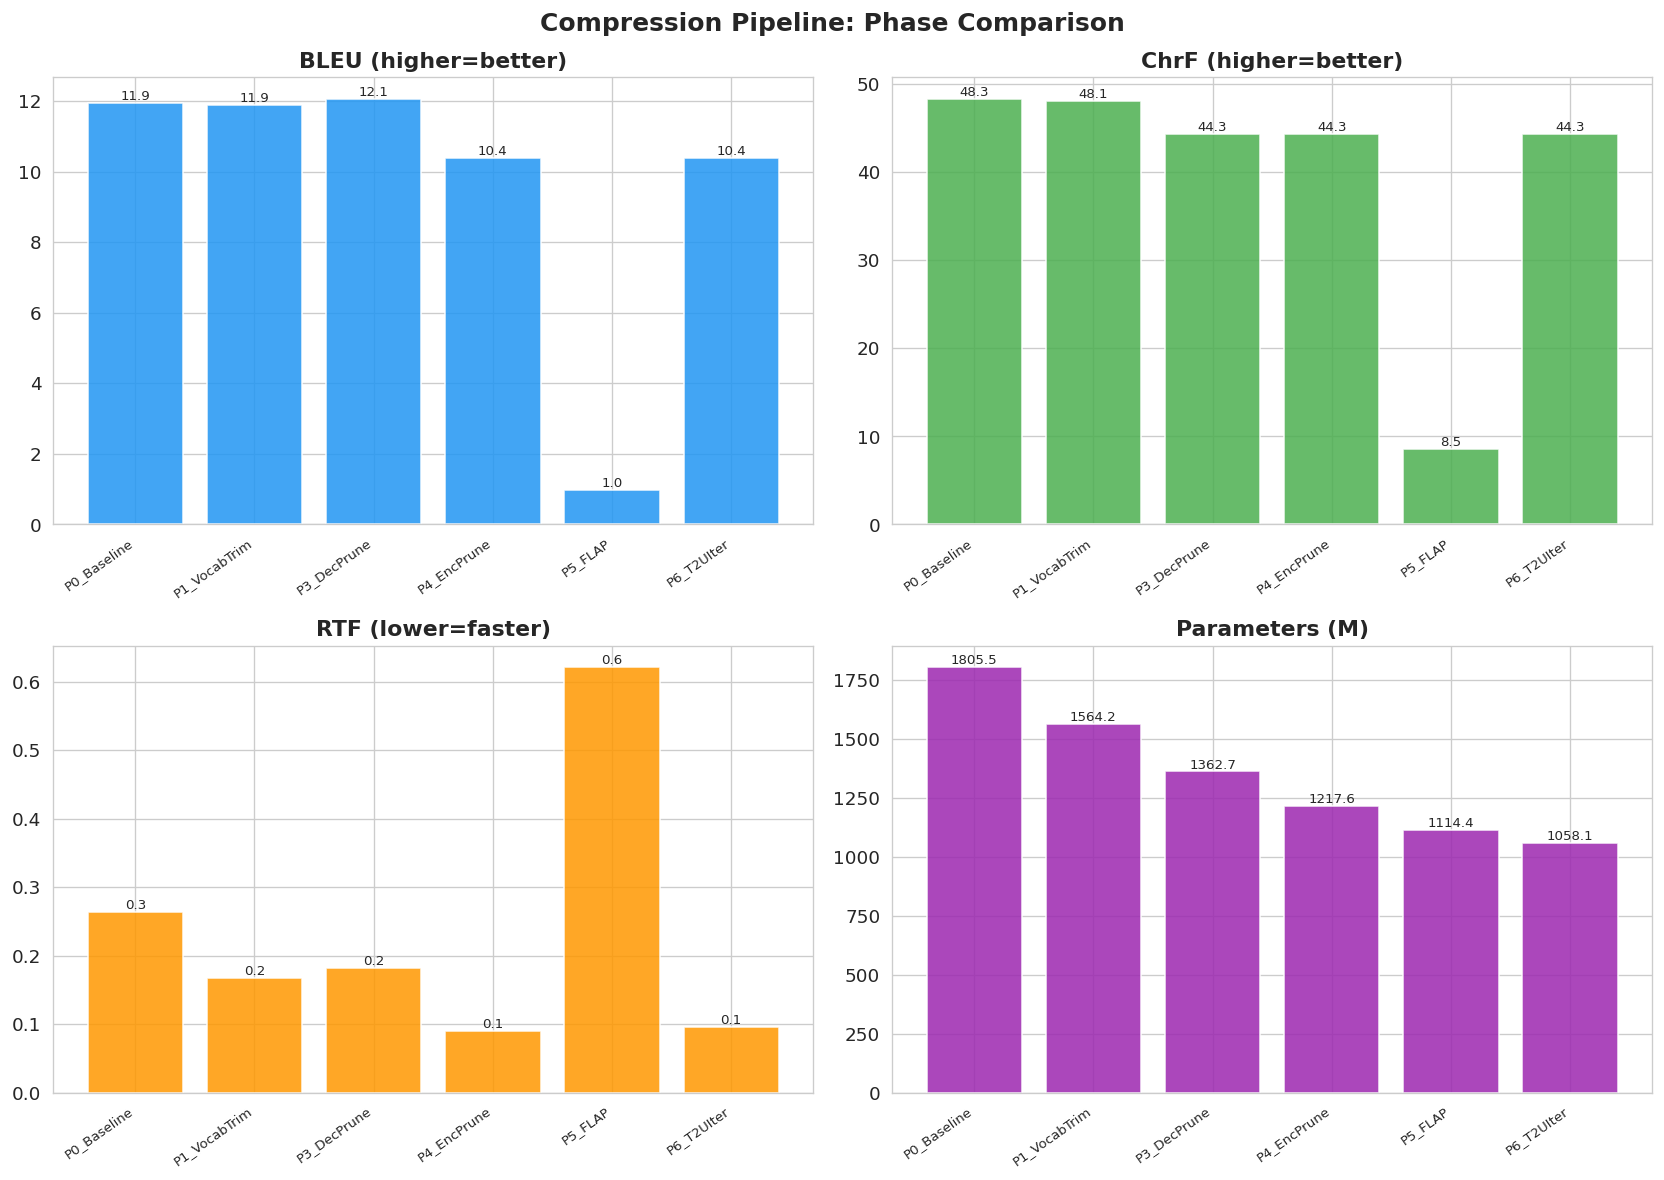

In [39]:
p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

[ckpt] Loaded phase3_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P3_DecPrune (6 total)


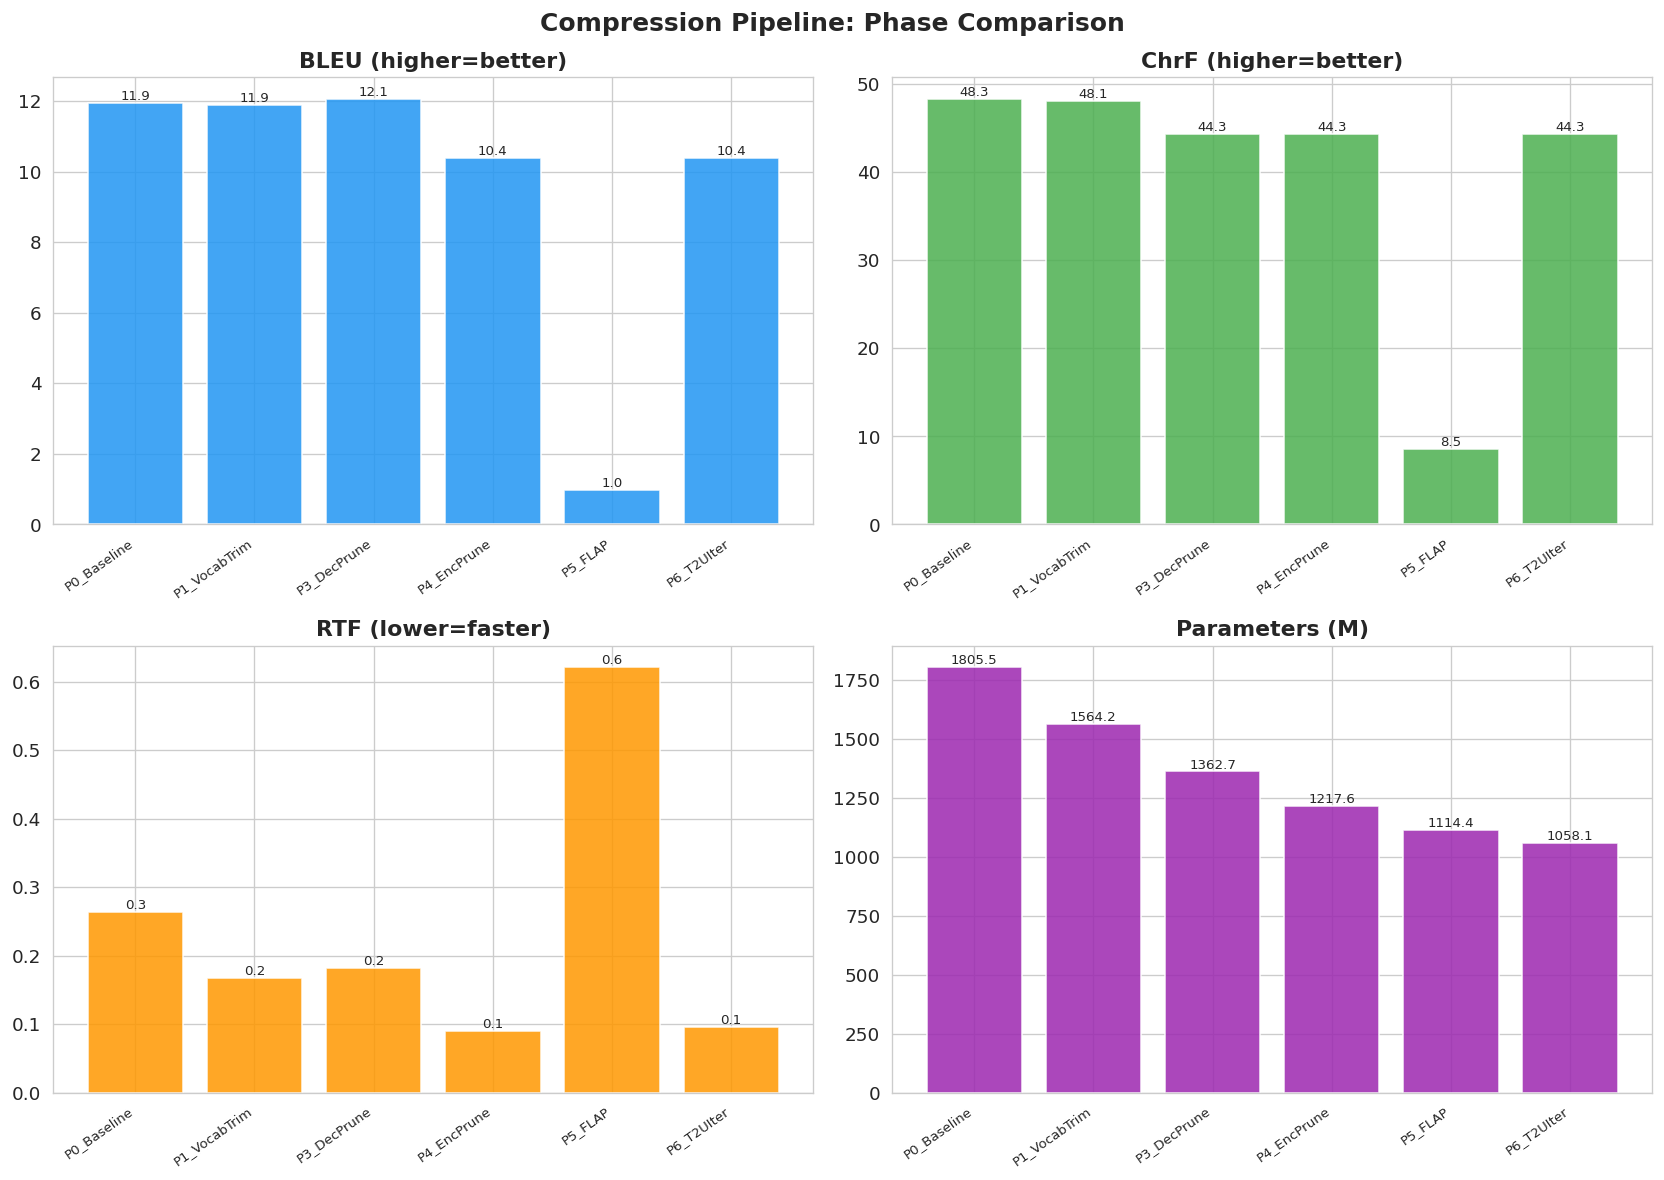

In [40]:
p3b = load_latest_checkpoint('phase3_benchmark')
if p3b: p3_results, p3_summary = p3b['results'], p3b['summary']
else:
    p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
    save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

---
# Phase 4: Speech Encoder Iterative Layer Pruning
**Paper:** ShortGPT (ACL 2025) for Block Influence; Moslem (IWSLT 2025) for iterative greedy

Target: remove 6-8 of 24 speech encoder layers.

In [41]:
def get_speech_encoder_layers(mdl):
    enc = mdl.speech_encoder
    if hasattr(enc, 'layers') and isinstance(enc.layers, torch.nn.ModuleList) and len(enc.layers) > 0:
        return enc, 'layers'
    if hasattr(enc, 'encoder') and hasattr(enc.encoder, 'layers') and len(enc.encoder.layers) > 0:
        return enc.encoder, 'layers'
    for child_name, child in enc.named_children():
        if hasattr(child, 'layers') and isinstance(child.layers, torch.nn.ModuleList) and len(child.layers) > 0:
            print(f'  Found layers at speech_encoder.{child_name}.layers')
            return child, 'layers'
    raise RuntimeError(
        f"Cannot find layers. speech_encoder children: "
        f"{[n for n,_ in enc.named_children()]}\n"
        f"encoder children: "
        f"{[n for n,_ in enc.encoder.named_children()] if hasattr(enc, 'encoder') else 'N/A'}"
    )


def compute_block_influence(mdl, samples, max_n=50):
    """
    Block Influence (ShortGPT, ACL 2025): BI(l) = 1 - cos(input_l, output_l).

    Measures how much each layer transforms its input — low BI means the
    layer barely changes the hidden states and is a prime pruning candidate.
    Used here to PRE-RANK layers before iterative ChrF search, so we only
    evaluate cheap candidates rather than all layers every iteration.
    """
    parent, la = get_speech_encoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []

    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0]
                if x is None or not isinstance(x, torch.Tensor): return
                y = out[0] if isinstance(out, tuple) else out
                if y is None or not isinstance(y, torch.Tensor): return
                x = x.detach().float().reshape(-1, x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1, y.shape[-1])
                cos = F.cosine_similarity(x, y, dim=-1).mean().item()
                bi[idx].append(1.0 - cos)
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))

    mdl.eval()
    dev = next(mdl.speech_encoder.parameters()).device
    ok = 0
    for idx, s in enumerate(samples[:max_n]):
        if idx % 10 == 0:
            print(f'  Calibrating {idx}/{min(max_n, len(samples))}...')
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            feats = {k: v.to(dev) for k, v in inputs.items()}
            with torch.no_grad():
                mdl.speech_encoder(**feats)
            ok += 1
        except Exception as e:
            print(f'  Sample {idx} failed: {e}')

    for h in hooks: h.remove()

    scores = {i: float(np.mean(v)) if v else 0.0 for i, v in bi.items()}
    print(f'  Calibrated on {ok}/{min(max_n, len(samples))} samples.')
    nonzero = sum(1 for v in scores.values() if v > 1e-6)
    print(f'  Non-zero BI scores: {nonzero}/{n}')
    if nonzero == 0:
        raise RuntimeError("All BI scores are zero — hooks did not fire.")

    # Print ranking so user can see what BI identified
    ranked = sorted(scores.items(), key=lambda x: x[1])
    print(f'\n  BI ranking (lowest = most redundant → pruning candidates):')
    for rank, (layer_i, bi_val) in enumerate(ranked):
        print(f'    Rank {rank+1:>2}  L{layer_i:>2}  BI={bi_val:.4f}')

    return scores


def iterative_enc_prune(mdl, samples, n_remove, tgt_lang='ben', max_eval=10,
                        ckpt_name='phase4_enc_pruning',
                        bi_scores=None,
                        bi_candidate_ratio=0.5,
                        protected=None):
    """
    BI-guided iterative greedy encoder pruning.

    Paper alignment:
    - ShortGPT (ACL 2025): BI scores rank layers by redundancy. We use them
      to restrict the candidate pool each iteration to the bottom bi_candidate_ratio
      fraction by BI score. This is the key improvement — instead of evaluating
      all N layers every iteration (O(N²) ChrF calls), we only evaluate the
      bottom-K BI candidates (O(N·K) calls), cutting runtime by ~50%.
    - Moslem IWSLT 2025: iterative greedy selection by ChrF, one layer at a time.
    - Custom rule: protected layers (first, middle, last) are never candidates.

    Args:
        bi_scores: dict {orig_layer_idx: bi_score}. If provided, only the
                   bottom bi_candidate_ratio fraction are evaluated each iter.
                   If None, falls back to evaluating all candidates (old behavior).
        bi_candidate_ratio: fraction of remaining layers to consider as candidates
                            based on BI ranking (default 0.5 = bottom 50%).
        protected: set of original layer indices to never prune.
    """
    parent, la = get_speech_encoder_layers(mdl)
    current  = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    n_total  = len(current)
    removed, log = [], []

    # ── Protected indices (never prunable) ──
    if protected is None:
        protected = {0, n_total // 2, n_total - 1}
    print(f'  Protected layers (first/mid/last): {sorted(protected)}')

    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos)
                orig_idx.pop(pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)
    baseline = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
    print(f'  Baseline ChrF (before any removal): {baseline:.2f}')

    for it in range(start_iter, n_remove):
        # ── Determine eligible candidates ──
        # 1. Exclude protected original indices
        eligible_positions = [
            pos for pos in range(len(current))
            if orig_idx[pos] not in protected
        ]

        # 2. BI-guided pre-filtering (ShortGPT ACL 2025):
        #    Among eligible positions, only evaluate the bottom bi_candidate_ratio
        #    by BI score — these are the most redundant layers per BI theory.
        if bi_scores and len(eligible_positions) > 2:
            # Sort eligible positions by ascending BI score (lowest BI = most redundant)
            eligible_by_bi = sorted(
                eligible_positions,
                key=lambda pos: bi_scores.get(orig_idx[pos], float('inf'))
            )
            # Keep only the bottom fraction as candidates
            n_candidates = max(2, int(len(eligible_by_bi) * bi_candidate_ratio))
            candidate_positions = eligible_by_bi[:n_candidates]
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain)')
            print(f'  BI pre-filter: {len(candidate_positions)}/{len(eligible_positions)} '
                  f'eligible layers selected as candidates (bottom {bi_candidate_ratio*100:.0f}% by BI)')
            skipped = [orig_idx[p] for p in eligible_by_bi[n_candidates:]]
            if skipped:
                print(f'  Skipped (high BI / important): {skipped}')
        else:
            # Fallback: evaluate all eligible (original behavior, no BI available)
            candidate_positions = eligible_positions
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
                  f'no BI pre-filter — evaluating all {len(candidate_positions)} eligible)')

        if not candidate_positions:
            print(f'  WARNING: No eligible candidates left. Stopping early.')
            break

        # ── Evaluate each candidate via ChrF ──
        scores = {}
        for pos in candidate_positions:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, torch.nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[pos] = (orig_idx[pos], sc)
            bi_note = f'  BI={bi_scores.get(orig_idx[pos], 0):.4f}' if bi_scores else ''
            print(f'    Remove L{orig_idx[pos]:>2} -> ChrF={sc:.2f}{bi_note}')
        setattr(parent, la, torch.nn.ModuleList(current))

        # ── Pick best removal (highest remaining ChrF) ──
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos)
        orig_idx.pop(best_pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current),
                        bi_score=bi_scores.get(best_orig, None) if bi_scores else None))
        print(f'  -> Removed original layer {best_orig}  '
              f'(ChrF={best_sc:.2f}'
              + (f', BI={bi_scores.get(best_orig, 0):.4f}' if bi_scores else '') + ')')

        # Update BI scores: remove pruned layer from tracking
        # (so next iteration's ranking reflects current architecture)
        if bi_scores and best_orig in bi_scores:
            del bi_scores[best_orig]

        save_checkpoint(
            dict(removed=removed, log=log,
                 bi_scores=bi_scores if bi_scores else {}),
            name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()

    return removed, log


print('Phase 4 helpers ready (BI-guided iterative pruning).')
parent, la = get_speech_encoder_layers(model_p3)
print(f'Speech encoder layers found: {len(getattr(parent, la))} '
      f'at .speech_encoder.{type(parent).__name__}.{la}')

Phase 4 helpers ready (BI-guided iterative pruning).
Speech encoder layers found: 24 at .speech_encoder.SeamlessM4Tv2ConformerEncoder.layers


In [42]:
# ── Uncomment and run ONCE to wipe corrupt Phase 4 results, then re-comment ──

# # 1. Local checkpoints
# for f in glob.glob(f'{CKPT_DIR}/phase4_enc_pruning_step*.pt'):
#     os.remove(f)
#     print(f'Deleted local ckpt: {f}')

# # 2. Local saved model
# local_model = f'{MODEL_DIR}/phase4_enc_pruned'
# if os.path.exists(local_model):
#     shutil.rmtree(local_model)
#     print(f'Deleted local model: {local_model}')

# # 3. Remote cleanup — platform-aware
# if ON_KAGGLE:
#     subprocess.run(f'rclone delete "{GDRIVE_ROOT}/checkpoints/phase4_enc_pruning_step000000.pt"',
#                    shell=True)
#     subprocess.run(f'rclone purge "{GDRIVE_ROOT}/phase4_enc_pruned"',
#                    shell=True)
#     r = subprocess.run(f'rclone ls "{GDRIVE_ROOT}/checkpoints/"',
#                        shell=True, capture_output=True, text=True)
#     print('Remaining on remote:', r.stdout or '(none)')
# else:
#     # Colab: just deleting local IS deleting Drive (they're the same)
#     print('Colab: local deletion above already removed files from Drive.')

# ck = load_latest_checkpoint('phase4_enc_pruning')
# print('Phase 4 checkpoint after cleanup:', ck)

In [43]:
# # Run once to fix model_p3 in memory before phase 3 benchmark
# sync_model_config(model_p3)

# # Run once to fix model_p4 in memory before phase 4 benchmark
# sync_model_config(model_p4)

In [83]:
!rm -rf '/kaggle/working/models/phase4_enc_pruned'
!rm -rf '/kaggle/working/checkpoints/phase6*.pt'

In [45]:
# ── Phase 4: Speech Encoder Iterative Layer Pruning ──────────────────────────
# Paper: ShortGPT (ACL 2025) — BI pre-ranks layers by redundancy.
#        Moslem IWSLT 2025 — iterative greedy ChrF-guided removal.
# Integration: BI restricts the candidate pool each iteration to the
#              bottom 50% by BI score, halving ChrF evaluation cost.
# Custom rule: protect first (L0), middle (L12), last (L23) layers.

N_ENC_REMOVE = 6
ENC_BI_CANDIDATE_RATIO = 0.5   # evaluate only the bottom 50% by BI each iter

p4_ckpt = load_latest_checkpoint('phase4_enc_pruning')
p4_complete = p4_ckpt and len(p4_ckpt.get('removed', [])) >= N_ENC_REMOVE

if p4_complete:
    removed_enc = p4_ckpt['removed']
    bi_scores   = p4_ckpt.get('bi_scores', {})
    p4_log      = p4_ckpt['log']
    print(f'Phase 4 complete: removed {removed_enc}')
    try:
        model_p4, processor = load_model_from_drive('phase4_enc_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p3...')
        model_p4 = model_p3
        parent, la = get_speech_encoder_layers(model_p4)
        cur  = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_enc]
        setattr(parent, la, torch.nn.ModuleList([cur[i] for i in keep]))
        print(f'  Rebuilt from checkpoint: {len(keep)} layers remain')
        save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')
else:
    done_so_far = len(p4_ckpt['removed']) if p4_ckpt else 0
    print(f'{"Resuming" if done_so_far else "Running"} Phase 4: '
          f'encoder pruning ({done_so_far}/{N_ENC_REMOVE} done)...')

    model_p4 = model_p3
    model_p4 = _consolidate_to_single_gpu(model_p4)

    sanity = quick_eval_chrf(model_p4, eval_samples, TARGET_LANG, 5)
    print(f'  Sanity check ChrF = {sanity:.2f}  (expect ~40-55, abort if < 10)')
    assert sanity > 10, f'ChrF={sanity:.2f} is too low — model or vocab remap is broken!'

    # ── Step 1: Compute BI scores (ShortGPT ACL 2025) ──────────────────────
    # BI = 1 - cosine_similarity(layer_input, layer_output)
    # Low BI → layer barely transforms hidden states → redundant candidate.
    # We use BI to PRE-FILTER candidates each iteration rather than just plotting.
    if not (p4_ckpt and p4_ckpt.get('bi_scores')):
        print('Step 1: Computing Block Influence scores (ShortGPT ACL 2025)...')
        bi_scores = compute_block_influence(model_p4, eval_samples, max_n=50)
        plot_layer_scores(bi_scores, 'Speech Encoder Block Influence', 'phase4_bi.png')
        # Save BI scores immediately so resume works
        save_checkpoint(
            dict(removed=[], log=[], bi_scores=bi_scores),
            name='phase4_enc_pruning', step=0)
    else:
        bi_scores = p4_ckpt['bi_scores']
        print(f'  BI scores loaded from checkpoint ({len(bi_scores)} layers), '
              f'skipping recomputation.')

    # Determine protected set: first, middle, last of the ORIGINAL encoder
    parent_tmp, la_tmp = get_speech_encoder_layers(model_p4)
    n_enc_layers = len(getattr(parent_tmp, la_tmp))
    enc_protected = {0, n_enc_layers // 2, n_enc_layers - 1}
    print(f'\n  Encoder protected layers: {sorted(enc_protected)} '
          f'(of {n_enc_layers} total)')

    # ── Step 2: BI-guided iterative pruning (Moslem IWSLT 2025 + ShortGPT) ──
    # Each iteration: evaluate only bottom-50% BI candidates (not all layers).
    # This directly uses BI as a meaningful pre-filter, not just a plot.
    print(f'\nStep 2: BI-guided iterative pruning ({N_ENC_REMOVE} layers, '
          f'candidate ratio={ENC_BI_CANDIDATE_RATIO})...')
    removed_enc, p4_log = iterative_enc_prune(
        model_p4, eval_samples, N_ENC_REMOVE, TARGET_LANG,
        max_eval=10,
        ckpt_name='phase4_enc_pruning',
        bi_scores=bi_scores,                        # ← NOW ACTUALLY USED
        bi_candidate_ratio=ENC_BI_CANDIDATE_RATIO,  # ← evaluate bottom 50% by BI
        protected=enc_protected,                    # ← first/mid/last protected
    )

    print('Syncing config after encoder pruning...')
    sync_model_config(model_p4)

    save_checkpoint(
        dict(removed=removed_enc, log=p4_log, bi_scores=bi_scores),
        name='phase4_enc_pruning', step=0)
    save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')

print(f'\nEncoder layers removed: {removed_enc}')
print_model_breakdown(model_p4, 'After Phase 4: Encoder Pruned')

[ckpt] Loaded phase4_enc_pruning_step000000.pt
Phase 4 complete: removed [19, 15, 9, 3, 2, 10]
[model] Not in local cache, pulling from remote...
[rclone] Pulled phase4_enc_pruned → /kaggle/working/models/phase4_enc_pruned
[model] Loading phase4_enc_pruned from /kaggle/working/models/phase4_enc_pruned ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']

Encoder layers removed: [19, 15, 9, 3, 2, 10]

--- After Phase 4: Encoder Pruned ---
  speech_encoder                         490.0M  ( 40.2%)
  text_decoder                           423.9M  ( 34.8%)
  t2u_model                              261.8M  ( 21.5%)
  vocoder                                 41.9M  (  3.4%)
  shared                                  20.9M  (  1.7%)
  lm_head                                 20.9M  (  1.7%)
  TOTAL                                 1217.6M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1217.583365}

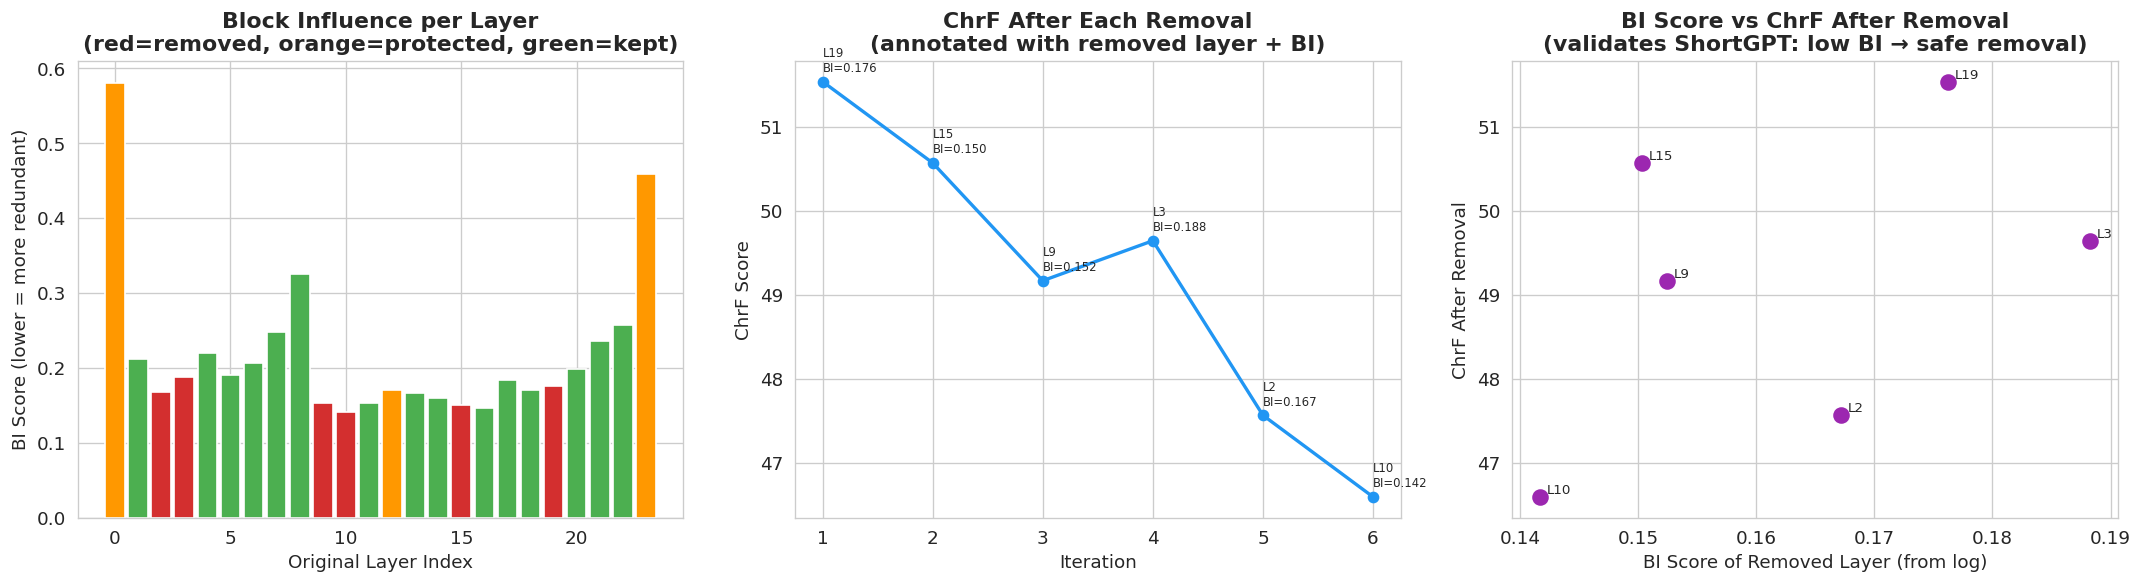

Saved phase4_enc_bi_analysis.png


In [46]:
if bi_scores and p4_log:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # BI at removal time (always use for removed layers + plot 3)
    bi_at_removal = {e['removed']: e.get('bi_score') for e in p4_log if 'removed' in e}

    def bi_value_for_index(i):
        if i in bi_scores:
            return bi_scores[i]
        b = bi_at_removal.get(i)
        return b if b is not None else 0.0

    # ── Plot 1: BI scores with removed/protected/kept labels ──
    ax1 = axes[0]
    parent_tmp, la_tmp = get_speech_encoder_layers(model_p4)
    n_enc = len(getattr(parent_tmp, la_tmp)) + len(removed_enc)
    enc_protected = {0, n_enc // 2, n_enc - 1}

    all_indices = sorted(
        set(bi_scores.keys()) | set(removed_enc) | set(bi_at_removal.keys())
    )
    vals = [bi_value_for_index(i) for i in all_indices]
    colors = []
    for i in all_indices:
        if i in removed_enc:
            colors.append('#d32f2f')
        elif i in enc_protected:
            colors.append('#ff9800')
        else:
            colors.append('#4caf50')

    ax1.bar(all_indices, vals, width=0.85, color=colors, edgecolor='white')
    ax1.set_title(
        'Block Influence per Layer\n(red=removed, orange=protected, green=kept)',
        fontweight='bold',
    )
    ax1.set_xlabel('Original Layer Index')
    ax1.set_ylabel('BI Score (lower = more redundant)')

    # ── Plot 2: ChrF after each removal ──
    ax2 = axes[1]
    iters = [e['iter'] for e in p4_log]
    chrfs = [e['chrf'] for e in p4_log]
    ax2.plot(iters, chrfs, 'o-', color='#2196F3', lw=2)
    for e in p4_log:
        bi_val = e.get('bi_score', None)
        label = f'L{e["removed"]}'
        if bi_val is not None:
            label += f'\nBI={bi_val:.3f}'
        ax2.annotate(
            label, (e['iter'], e['chrf']), fontsize=7,
            textcoords='offset points', xytext=(0, 6),
        )
    ax2.set_title(
        'ChrF After Each Removal\n(annotated with removed layer + BI)',
        fontweight='bold',
    )
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('ChrF Score')

    # ── Plot 3: BI of removed layer vs ChrF after that removal ──
    ax3 = axes[2]
    _filtered = [
        (e['bi_score'], e['chrf'])
        for e in p4_log
        if e.get('bi_score') is not None
    ]
    bi_vals_removed = [x for x, _ in _filtered]
    chrf_vals = [y for _, y in _filtered]

    if len(_filtered) >= 2:
        ax3.scatter(bi_vals_removed, chrf_vals, color='#9c27b0', s=80, zorder=3)
        for e in p4_log:
            if e.get('bi_score') is not None:
                ax3.annotate(
                    f'L{e["removed"]}',
                    (e['bi_score'], e['chrf']),
                    fontsize=8, textcoords='offset points', xytext=(4, 2),
                )
        ax3.set_xlabel('BI Score of Removed Layer (from log)')
        ax3.set_ylabel('ChrF After Removal')
        ax3.set_title(
            'BI Score vs ChrF After Removal\n(validates ShortGPT: low BI → safe removal)',
            fontweight='bold',
        )
    else:
        ax3.text(
            0.5, 0.5, 'Not enough data\nfor correlation plot',
            ha='center', va='center', transform=ax3.transAxes,
        )
        ax3.set_title('BI vs ChrF Correlation', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase4_enc_bi_analysis.png', dpi=120)
    plt.show()
    print('Saved phase4_enc_bi_analysis.png')

[ckpt] Loaded phase4_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P4_EncPrune (6 total)


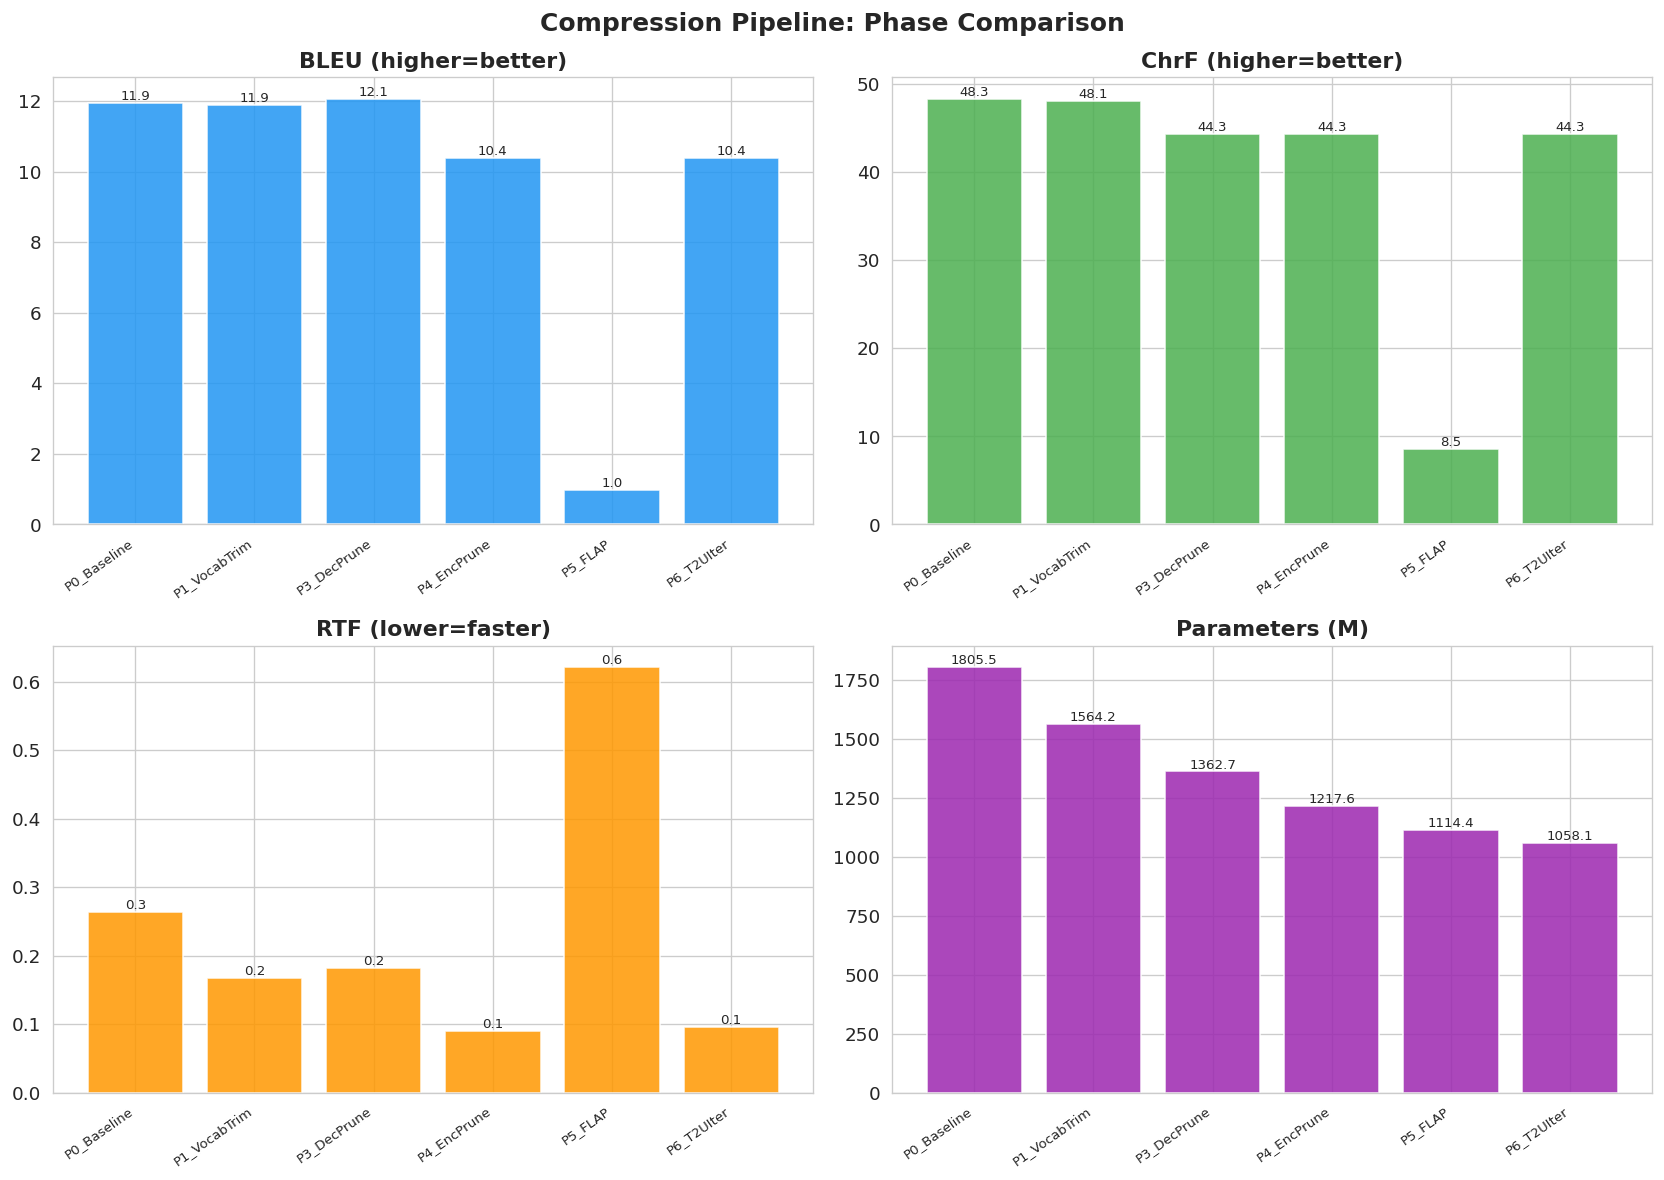

In [47]:
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b: p4_results, p4_summary = p4b['results'], p4b['summary']
else:
    p4_results, p4_summary = run_benchmark(model_p4, eval_samples, label='P4_EncPrune', save_n=2)
    save_checkpoint(dict(results=p4_results, summary=p4_summary), name='phase4_benchmark', step=0)
store_summary(p4_summary); plot_phase_comparison()

---
# Phase 5: Width Pruning (FLAP)
**Paper:** FLAP (AAAI 2024)

Structurally remove FFN neurons (shrink weight matrices). Creates smaller dense
matrices for real GPU speedup, unlike zeroing which keeps full-size matrices.

In [48]:
# ── Phase 5 Cell 1: FLAP helpers ─────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from collections import defaultdict

# ── Step 1: Find all FFN pairs in any component ──────────────────────────────

def find_all_ffn_layers(model, component_name):
    """
    Walk a component and return all (parent_module, in_attr, out_attr, display_name)
    tuples for every FFN pair found.

    Handles:
      - Text decoder / standard FFN:     layer.ffn.fc1 / .fc2
      - Speech encoder (Conformer):      layer.ffn1|ffn2.intermediate_dense / .output_dense
      - T2U (and adapter):               layer.ffn.fc1 / .fc2
    """
    component = getattr(model, component_name)
    results = []

    def _pair_ok(lin1, lin2):
        return (
            isinstance(lin1, nn.Linear)
            and isinstance(lin2, nn.Linear)
            and lin1.out_features == lin2.in_features
        )

    def _scan(module, prefix):
        # Conformer FFN (speech encoder blocks)
        if hasattr(module, 'intermediate_dense') and hasattr(module, 'output_dense'):
            if _pair_ok(module.intermediate_dense, module.output_dense):
                results.append(
                    (module, 'intermediate_dense', 'output_dense', prefix)
                )

        # Standard HF FFN (decoder, T2U, adapter)
        if hasattr(module, 'fc1') and hasattr(module, 'fc2'):
            if _pair_ok(module.fc1, module.fc2):
                results.append((module, 'fc1', 'fc2', prefix))

        for name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                _scan(child, f'{prefix}.{name}' if prefix else name)

    _scan(component, component_name)
    return results


def test_ffn_detection(model):
    """Verify we find FFN pairs in all components before running pruning."""
    for comp in ['speech_encoder', 'text_decoder', 't2u_model']:
        pairs = find_all_ffn_layers(model, comp)
        print(f'  {comp}: {len(pairs)} FFN pairs found')
        if pairs:
            sample = pairs[0]
            fc1 = getattr(sample[0], sample[1])
            fc2 = getattr(sample[0], sample[2])
            print(f'    Sample: {sample[3]} | fc1={fc1.in_features}→{fc1.out_features} | fc2={fc2.in_features}→{fc2.out_features}')

print('Running FFN detection on model_p4...')
test_ffn_detection(model_p4)

Running FFN detection on model_p4...
  speech_encoder: 38 FFN pairs found
    Sample: speech_encoder.encoder.layers.0.ffn1 | fc1=1024→4096 | fc2=4096→1024
  text_decoder: 16 FFN pairs found
    Sample: text_decoder.layers.0.ffn | fc1=1024→8192 | fc2=8192→1024
  t2u_model: 6 FFN pairs found
    Sample: t2u_model.model.encoder.layers.0.ffn | fc1=1024→8192 | fc2=8192→1024


In [49]:
# ── Phase 5 Cell 2: Calibration — single generate() pass fires ALL hooks ──────
#
# ROOT CAUSE OF 37-LAYER WARNING:
#   model.speech_encoder(inp_feat) was called directly, but SeamlessM4T's
#   ConformerEncoder expects inputs in a different format than what the processor
#   returns, so it silently failed (except: pass swallowed the error).
#   Only generate() reliably runs the full pipeline: speech_encoder → text_decoder
#   → t2u_model. So we collect stats for ALL components in ONE generate() pass.
#
# APPROACH: Register hooks for ALL FFN layers across all components at once,
#   run generate() once per sample, all hooks fire naturally.

import torch
import torch.nn as nn
import numpy as np


def collect_ffn_calibration_stats(model, component_name, calibration_wavs,
                                   processor, n_samples=64, device=None):
    """
    Collect per-channel input L2-norm stats for every FFN layer in component_name.

    Runs model.generate() (full pipeline) so ALL layers — including speech encoder
    Conformer FFNs — are guaranteed to fire. Hooks are scoped to component_name only.

    Stats collected per channel j:
        sq_sum  = Σ_tokens x_j²          (for Wanda: rms = sqrt(sq_sum/count))
        sum_x   = Σ_tokens x_j            (for bias compensation: mean)
    """
    if device is None:
        device = next(model.parameters()).device

    ffn_pairs = find_all_ffn_layers(model, component_name)
    if not ffn_pairs:
        print(f'  [calib] No FFN pairs in {component_name}, skipping.')
        return {}

    # Build stats dict keyed by id(parent)
    stats = {}
    for (parent, fc1_attr, fc2_attr, name) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        cin = fc1.in_features
        key = id(parent)
        stats[key] = {
            'sum_x':  torch.zeros(cin, dtype=torch.float64),
            'sq_sum': torch.zeros(cin, dtype=torch.float64),
            'count':  0,
            'module': parent,
            'fc1':    fc1_attr,
            'fc2':    fc2_attr,
            'name':   name,
        }

    hooks = []

    def make_hook(key):
        def hook(module, inp, out):
            # inp[0]: input tensor to this Linear, shape [*, cin]
            x = inp[0].detach().float()
            if x.dim() == 3:
                x = x.reshape(-1, x.shape[-1])
            elif x.dim() == 1:
                x = x.unsqueeze(0)
            # x: [T, cin]
            s = stats[key]
            s['count']  += x.shape[0]
            s['sum_x']  += x.sum(dim=0).double()
            s['sq_sum'] += x.pow(2).sum(dim=0).double()
        return hook

    # Register hooks on the fc1 Linear of each FFN pair
    for (parent, fc1_attr, fc2_attr, name) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        key = id(parent)
        hooks.append(fc1.register_forward_hook(make_hook(key)))

    model.eval()
    n_actual = min(n_samples, len(calibration_wavs))
    print(f'  [calib] Collecting activations from {n_actual} samples '
          f'for {component_name} (via full generate pass)...')

    with torch.no_grad():
        for i, wav in enumerate(calibration_wavs[:n_actual]):
            if i % 20 == 0:
                print(f'  [calib] {i}/{n_actual}')
            try:
                inputs = processor(audio=wav, sampling_rate=16000,
                                   return_tensors='pt')
                # Send inputs to the device where the speech encoder lives
                # (may differ from `device` if model spans GPUs)
                speech_device = next(model.speech_encoder.parameters()).device
                inputs = {k: v.to(speech_device) for k, v in inputs.items()}

                # Full generate() — runs speech_encoder + text_decoder + t2u
                # ALL registered hooks fire during this single call.
                model.generate(
                    **inputs,
                    tgt_lang='ben',
                    generate_speech=False,   # skip vocoder, saves time
                    max_new_tokens=40,
                )
            except Exception as e:
                pass  # skip bad samples; most will succeed

    for h in hooks:
        h.remove()

    # Diagnostics
    fired     = sum(1 for s in stats.values() if s['count'] > 0)
    not_fired = len(stats) - fired
    total_toks = sum(s['count'] for s in stats.values())
    print(f'  [calib] Layers fired: {fired}/{len(stats)}  '
          f'total token-vectors: {total_toks}')
    if not_fired > 0:
        names = [s['name'] for s in stats.values() if s['count'] == 0]
        print(f'  [calib] WARNING: {not_fired} layers still got 0 — '
              f'will use weight-norm fallback for: {names[:3]}{"..." if len(names)>3 else ""}')

    # Finalize statistics
    for key, s in stats.items():
        n = max(s['count'], 1)
        mean_x  = (s['sum_x']  / n).float()
        sq_norm = (s['sq_sum'] / n).float()          # E[x²] per channel
        var     = (sq_norm - mean_x.pow(2)).clamp(min=0)

        s['mean']    = mean_x
        s['var']     = var
        s['sq_norm'] = sq_norm

    print(f'  [calib] Done. {len(stats)} FFN layers instrumented.')
    return stats


print('Calibration helpers ready.')


Calibration helpers ready.


In [50]:
# ── Phase 5 Cell 3: Neuron importance scoring (Wanda-sp + FLAP) ──────────────
#
# Wanda-sp (structured Wanda): score(k) = sum_j |W1[k,j]| * ||X_j||_2
#   where ||X_j||_2 = sqrt(E[x_j^2]) — the RMS of channel j inputs
#
# FLAP-row: score(k) = sum_j Var(X_j) * W1[k,j]^2
#
# We use Wanda-sp as primary (proven robust, never zero if layer fires),
# and fall back to pure row-norm if sq_norm is also zero (truly dead layer).

import torch
import torch.nn as nn
import numpy as np


def wanda_neuron_scores(fc1_weight, sq_norm):
    """
    Wanda-sp per-neuron score (ICLR 2024, structured variant).

    score(k) = sum_j |W1[k,j]| * sqrt(E[x_j^2])
             = |W1| @ rms_x          where rms_x = sqrt(sq_norm)

    fc1_weight : [ffn_hidden, model_hidden]
    sq_norm    : [model_hidden]  E[x_j^2] per channel

    Returns [ffn_hidden] scores. Falls back to row-L2-norm if sq_norm ~ 0.
    """
    W1 = fc1_weight.float().cpu()
    rms = sq_norm.float().cpu().clamp(min=0).sqrt()   # [model_hidden]

    if rms.max().item() < 1e-10:
        # Layer never fired or truly dead — use weight row-norm only
        return W1.pow(2).sum(dim=1).sqrt()

    return (W1.abs() * rms.unsqueeze(0)).sum(dim=1)   # [ffn_hidden]


def flap_neuron_scores(fc1_weight, var_x):
    """
    FLAP per-neuron score (AAAI 2024, Eq. 5 applied to rows).
    score(k) = sum_j Var(X_j) * W1[k,j]^2
    Falls back to row-norm if var is zero.
    """
    W1 = fc1_weight.float().cpu()
    v  = var_x.float().cpu().clamp(min=0)

    if v.max().item() < 1e-10:
        return W1.pow(2).sum(dim=1)

    return (W1.pow(2) * v.unsqueeze(0)).sum(dim=1)


def neuron_importance_scores(fc1_weight, var_x, sq_norm=None):
    """
    Primary scoring function: use Wanda-sp if sq_norm available, else FLAP.
    """
    if sq_norm is not None and sq_norm.max().item() > 1e-10:
        return wanda_neuron_scores(fc1_weight, sq_norm)
    if var_x is not None and var_x.max().item() > 1e-10:
        return flap_neuron_scores(fc1_weight, var_x)
    # Pure weight magnitude fallback
    return fc1_weight.float().cpu().pow(2).sum(dim=1)


def standardize_scores(scores):
    """FLAP Eq.6: standardize to zero mean, unit std for cross-layer comparison."""
    mu    = scores.mean()
    sigma = scores.std(unbiased=False)
    if sigma < 1e-8:
        return torch.zeros_like(scores)
    return (scores - mu) / sigma


def structural_prune_ffn(parent, fc1_attr, fc2_attr,
                          channel_mean, keep_idx, device):
    """
    Structurally prune one FFN pair using pre-computed keep_idx.
    Applies FLAP bias compensation (Eq.4) to recover pruned contribution.
    """
    fc1 = getattr(parent, fc1_attr)
    fc2 = getattr(parent, fc2_attr)
    ffn_dim = fc1.out_features

    fc1_device = fc1.weight.device
    fc2_device = fc2.weight.device

    # Bias compensation: B0 = W2[:, pruned] @ activate(W1[pruned] @ mean_x + b1[pruned])
    all_idx    = torch.arange(ffn_dim)
    pruned_mask = torch.ones(ffn_dim, dtype=torch.bool)
    pruned_mask[keep_idx] = False
    pruned_idx = all_idx[pruned_mask]

    mean_x = channel_mean.to(fc1_device).to(fc1.weight.dtype)
    if len(pruned_idx) > 0:
        pidx     = pruned_idx.to(fc1_device)
        baseline = fc1.weight.data[pidx] @ mean_x
        if fc1.bias is not None:
            baseline = baseline + fc1.bias.data[pidx]
        # Ignore nonlinearity for bias comp (standard FLAP approximation)
        bias_comp = (fc2.weight.data[:, pidx.to(fc2_device)].float()
                     @ baseline.float().to(fc2_device))
        bias_comp = bias_comp.to(fc2.weight.dtype)
    else:
        bias_comp = torch.zeros(fc2.out_features,
                                dtype=fc2.weight.dtype, device=fc2_device)

    n_keep   = len(keep_idx)
    kidx_fc1 = keep_idx.to(fc1_device)
    kidx_fc2 = keep_idx.to(fc2_device)

    new_fc1 = nn.Linear(fc1.in_features, n_keep,
                         bias=(fc1.bias is not None),
                         device=fc1_device, dtype=fc1.weight.dtype)
    new_fc1.weight.data.copy_(fc1.weight.data[kidx_fc1])
    if fc1.bias is not None:
        new_fc1.bias.data.copy_(fc1.bias.data[kidx_fc1])

    new_fc2 = nn.Linear(n_keep, fc2.out_features,
                         bias=True, device=fc2_device, dtype=fc2.weight.dtype)
    new_fc2.weight.data.copy_(fc2.weight.data[:, kidx_fc2])
    existing_bias = (fc2.bias.data if fc2.bias is not None
                     else torch.zeros(fc2.out_features,
                                      dtype=fc2.weight.dtype, device=fc2_device))
    new_fc2.bias.data.copy_(existing_bias + bias_comp.to(fc2_device))

    setattr(parent, fc1_attr, new_fc1)
    setattr(parent, fc2_attr, new_fc2)

    return n_keep, ffn_dim


print('Neuron scoring + structural pruning helpers ready.')


Neuron scoring + structural pruning helpers ready.


In [51]:
# ── Phase 5 Cell 4: apply_flap_to_component — robust top-k pruning ───────────

def apply_flap_to_component(model, component_name, calib_stats,
                              global_prune_ratio=0.20,
                              min_keep_frac=0.50,
                              device=None):
    """
    Structured FFN width pruning using Wanda-sp / FLAP neuron scores.

    global_prune_ratio : target fraction of neurons to prune (e.g. 0.20 = 20%)
    min_keep_frac      : per-layer floor — never prune a single layer below this
                         fraction of its original size (default 0.50 = keep ≥50%)

    Algorithm (faithful to FLAP paper):
      1. Score every neuron in every layer (Wanda-sp metric)
      2. Standardize scores per-layer (FLAP Eq.6) for cross-layer comparison
      3. Pool all standardized scores, find global threshold at global_prune_ratio
      4. Per layer: keep neurons above threshold, enforce min_keep_frac floor
      5. Structurally remove pruned rows/cols, add bias compensation (FLAP Eq.4)
    """
    if device is None:
        device = next(model.parameters()).device

    if not calib_stats:
        print(f'  [FLAP] No calib stats for {component_name}, skipping.')
        return {}

    # ── Step 1 & 2: score + standardize ─────────────────────────────────────
    all_std_scores  = {}
    all_raw_scores  = {}

    n_zero_var = 0
    for key, s in calib_stats.items():
        fc1   = getattr(s['module'], s['fc1'])
        W1    = fc1.weight.float().cpu()
        var_x  = s.get('var',     torch.zeros(W1.shape[1]))
        sq_norm = s.get('sq_norm', torch.zeros(W1.shape[1]))

        raw = neuron_importance_scores(W1, var_x, sq_norm)
        if raw.max().item() < 1e-10:
            n_zero_var += 1

        all_raw_scores[key] = raw
        all_std_scores[key] = standardize_scores(raw)

    if n_zero_var:
        print(f'  [FLAP] WARNING: {n_zero_var}/{len(calib_stats)} layers used '
              f'weight-only fallback (calibration did not fire for those layers).')

    # ── Step 3: global threshold ─────────────────────────────────────────────
    all_std_flat  = torch.cat(list(all_std_scores.values()))
    total_neurons = len(all_std_flat)
    n_prune_total = int(total_neurons * global_prune_ratio)

    sorted_scores, _ = torch.sort(all_std_flat)
    threshold = sorted_scores[max(0, n_prune_total - 1)].item()

    print(f'  [FLAP] {component_name}: {total_neurons} total neurons, '
          f'pruning ≤{n_prune_total} ({global_prune_ratio*100:.0f}%), '
          f'threshold={threshold:.4f}')
    print(f'         score range [{all_std_flat.min():.3f}, {all_std_flat.max():.3f}]  '
          f'mean={all_std_flat.mean():.3f}  std={all_std_flat.std():.3f}')

    # ── Step 4 & 5: per-layer prune ──────────────────────────────────────────
    results       = {}
    total_kept    = 0
    total_orig    = 0

    for key, s in calib_stats.items():
        std_scores = all_std_scores[key]
        fc1 = getattr(s['module'], s['fc1'])
        ffn_dim = fc1.out_features

        # How many neurons score above the global threshold?
        n_above = int((std_scores > threshold).sum().item())

        # Enforce per-layer minimum
        min_keep = max(1, int(ffn_dim * min_keep_frac))
        n_keep   = max(min_keep, n_above)
        n_keep   = min(ffn_dim, n_keep)   # can't keep more than we have

        # Top-k selection (stable, threshold-independent)
        _, keep_idx = torch.topk(std_scores, n_keep)
        keep_idx = keep_idx.sort().values

        structural_prune_ffn(
            s['module'], s['fc1'], s['fc2'],
            channel_mean=s['mean'],
            keep_idx=keep_idx,
            device=device
        )

        pct_kept = n_keep / ffn_dim * 100
        total_kept += n_keep
        total_orig += ffn_dim
        results[s['name']] = {
            'kept': n_keep, 'original': ffn_dim, 'pct': pct_kept
        }

    avg_kept = total_kept / max(total_orig, 1) * 100
    print(f'  [FLAP] Done. Kept {total_kept}/{total_orig} neurons '
          f'({avg_kept:.1f}%) across {len(results)} layers.')
    return results


print('apply_flap_to_component ready.')


apply_flap_to_component ready.


In [52]:
# ── Phase 5 Cell 5: Build calibration wavs from eval_samples ─────────────────
# Reuse your existing eval_samples as calibration (or use ft_samples if loaded)

calib_wavs = [s['wav'] for s in eval_samples]
# Optionally extend with ft_samples for better coverage:
# calib_wavs = [s['wav'] for s in (eval_samples + ft_samples[:80])]

print(f'Calibration corpus: {len(calib_wavs)} samples')
print(f'  Duration range: {min(len(w)/16000 for w in calib_wavs):.1f}s – '
      f'{max(len(w)/16000 for w in calib_wavs):.1f}s')

Calibration corpus: 25 samples
  Duration range: 5.6s – 19.1s


In [53]:
# # ── Phase 5 Cell 6: RUN PHASE 5 ──────────────────────────────────────────────
# import gc as _stdlib_gc  # avoid shadowing if `gc` was reused elsewhere in the notebook

# FLAP_RATIO = 0.15

# try:
#     0/0
#     model_p5, processor = load_model_from_drive('phase5_flap_pruned')
#     print('Loaded Phase 5 from Drive.')
#     p5_loaded = True
# except Exception:
#     p5_loaded = False

# if not p5_loaded:
#     model_p5 = model_p4
#     device = next(model_p5.parameters()).device

#     if str(device) != 'cuda:0':
#         model_p5 = model_p5.to('cuda:0')
#         device = torch.device('cuda:0')
#         print(f'  Consolidated to {device}')

#     pre_params = count_params(model_p5)
#     print(f'Pre-pruning: {pre_params:.1f}M params')

#     all_calib_stats = {}
#     prune_results = {}

#     for comp_name in ['text_decoder', 'speech_encoder', 't2u_model']:
#         print(f'\n── Collecting calibration for {comp_name} ──')
#         calib = collect_ffn_calibration_stats(
#             model_p5, comp_name, calib_wavs, processor,
#             n_samples=min(64, len(calib_wavs)),
#             device=device
#         )
#         all_calib_stats[comp_name] = calib
#         _stdlib_gc.collect()
#         torch.cuda.empty_cache()

#         print(f'\n── Applying FLAP to {comp_name} ──')
#         results = apply_flap_to_component(
#             model_p5, comp_name, calib,
#             global_prune_ratio=FLAP_RATIO,
#             device=device
#         )
#         prune_results[comp_name] = results
#         _stdlib_gc.collect()
#         torch.cuda.empty_cache()

#     post_params = count_params(model_p5)
#     print(f'\nWidth pruning: {pre_params:.1f}M → {post_params:.1f}M '
#           f'(saved {pre_params - post_params:.1f}M params)')

#     sync_model_config(model_p5)

#     for comp, res in prune_results.items():
#         if res:
#             avg_kept = np.mean([v['pct'] for v in res.values()])
#             print(f'  {comp}: avg {avg_kept:.1f}% neurons kept ({len(res)} layers)')

#     save_checkpoint({'prune_results': prune_results, 'flap_ratio': FLAP_RATIO},
#                     name='phase5_flap', step=0)
#     sync_model_config(model_p5)
#     save_model_to_drive(model_p5, processor, 'phase5_flap_pruned')

# print_model_breakdown(model_p5, 'After Phase 5: FLAP Width Pruned')

Pre-pruning: 1217.6M params

── Collecting calibration for text_decoder ──
  [calib] Collecting activations from 25 samples for text_decoder (via full generate pass)...
  [calib] 0/25
  [calib] 20/25
  [calib] Layers fired: 0/16  total token-vectors: 0
  [calib] WARNING: 16 layers still got 0 — will use weight-norm fallback for: ['text_decoder.layers.0.ffn', 'text_decoder.layers.1.ffn', 'text_decoder.layers.2.ffn']...
  [calib] Done. 16 FFN layers instrumented.

── Applying FLAP to text_decoder ──
  [FLAP] text_decoder: 131072 total neurons, pruning ≤19660 (15%), threshold=-0.5924
         score range [-7.789, 24.612]  mean=0.000  std=1.000
  [FLAP] Done. Kept 111412/131072 neurons (85.0%) across 16 layers.

── Collecting calibration for speech_encoder ──
  [calib] Collecting activations from 25 samples for speech_encoder (via full generate pass)...
  [calib] 0/25
  [calib] 20/25
  [calib] Layers fired: 0/38  total token-vectors: 0
  [calib] WARNING: 38 layers still got 0 — will use we

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2261 MB in 8 files.
[model] Pushing to rclone remote...
[model] Verified 8 files on remote.

--- After Phase 5: FLAP Width Pruned ---
  speech_encoder                         442.1M  ( 39.7%)
  text_decoder                           383.7M  ( 34.4%)
  t2u_model                              246.7M  ( 22.1%)
  vocoder                                 41.9M  (  3.8%)
  shared                                  20.9M  (  1.9%)
  lm_head                                 20.9M  (  1.9%)
  TOTAL                                 1114.4M
---


{'shared': 20.9152,
 'speech_encoder': 442.126989,
 'text_decoder': 383.663924,
 'lm_head': 20.9152,
 't2u_model': 246.654519,
 'vocoder': 41.911362,
 'TOTAL': 1114.356794}

In [68]:
model_p4, processor = load_model_from_drive('phase4_enc_pruned')

[model] Not in local cache, pulling from remote...
[rclone] Pulled phase4_enc_pruned → /kaggle/working/models/phase4_enc_pruned
[model] Loading phase4_enc_pruned from /kaggle/working/models/phase4_enc_pruned ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']


In [69]:
print_model_breakdown(model_p4, 'After Phase 4:')


--- After Phase 4: ---
  speech_encoder                         490.0M  ( 40.2%)
  text_decoder                           423.9M  ( 34.8%)
  t2u_model                              261.8M  ( 21.5%)
  vocoder                                 41.9M  (  3.4%)
  shared                                  20.9M  (  1.7%)
  lm_head                                 20.9M  (  1.7%)
  TOTAL                                 1217.6M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1217.583365}

In [56]:
# # ── Phase 5 Cell 6: RUN PHASE 5 (active run cell) ────────────────────────────
# import gc as _stdlib_gc
# import copy as _copy

# FLAP_RATIO   = 0.05   # prune 15% of neurons globally per component
# MIN_KEEP_FRAC = 0.80  # never shrink any single layer below 50% of original

# # ── Try loading a completed Phase 5 from Drive ────────────────────────────────
# try:
#     model_p5, processor = load_model_from_drive('phase5_flap_pruned2')
#     sync_model_config(model_p5)
#     model_p5 = _consolidate_to_single_gpu(model_p5)
#     device   = next(model_p5.parameters()).device
#     print('Loaded Phase 5 from Drive.')
#     p5_loaded = True
# except Exception as _e:
#     print(f'No Phase 5 on Drive ({_e}), pruning from model_p4...')
#     p5_loaded = False

# if not p5_loaded:
#     # ── CRITICAL: deepcopy so pruning never mutates model_p4 ─────────────────
#     print('Deep-copying model_p4 → model_p5...')
#     model_p5 = _copy.deepcopy(model_p4)
#     model_p5 = _consolidate_to_single_gpu(model_p5)
#     device   = next(model_p5.parameters()).device
#     print(f'  device: {device}')

#     pre_params = count_params(model_p5)
#     print(f'Pre-pruning: {pre_params:.1f}M params')

#     prune_results = {}

#     # ── Calibrate + prune each component separately ───────────────────────────
#     # NOTE: collect_ffn_calibration_stats now uses full generate() internally,
#     # so all FFN hooks fire regardless of component_name.
#     for comp_name in ['text_decoder', 'speech_encoder', 't2u_model']:
#         print(f'\n── Collecting calibration for {comp_name} ──')
#         calib = collect_ffn_calibration_stats(
#             model_p5, comp_name, calib_wavs, processor,
#             n_samples=min(64, len(calib_wavs)),
#             device=device,
#         )
#         _stdlib_gc.collect(); torch.cuda.empty_cache()

#         print(f'\n── Applying FLAP to {comp_name} ──')
#         results = apply_flap_to_component(
#             model_p5, comp_name, calib,
#             global_prune_ratio=FLAP_RATIO,
#             min_keep_frac=MIN_KEEP_FRAC,
#             device=device,
#         )
#         prune_results[comp_name] = results
#         _stdlib_gc.collect(); torch.cuda.empty_cache()

#     post_params = count_params(model_p5)
#     print(f'\nWidth pruning: {pre_params:.1f}M → {post_params:.1f}M '
#           f'(saved {pre_params - post_params:.1f}M params)')

#     sync_model_config(model_p5)

#     for comp, res in prune_results.items():
#         if res:
#             avg_kept = np.mean([v['pct'] for v in res.values()])
#             print(f'  {comp}: avg {avg_kept:.1f}% neurons kept ({len(res)} layers)')

#     save_checkpoint({'prune_results': prune_results, 'flap_ratio': FLAP_RATIO},
#                     name='phase5_flap2', step=0)
#     sync_model_config(model_p5)
#     save_model_to_drive(model_p5, processor, 'phase5_flap_pruned2')

# print_model_breakdown(model_p5, 'After Phase 5: FLAP Width Pruned2')


[model] Not in local cache, pulling from remote...
[rclone] Pulled phase5_flap_pruned2 → /kaggle/working/models/phase5_flap_pruned2
[model] Loading phase5_flap_pruned2 from /kaggle/working/models/phase5_flap_pruned2 ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: /kaggle/working/models/phase5_flap_pruned2
Key                                                                   | Status   |                                                                                             
----------------------------------------------------------------------+----------+---------------------------------------------------------------------------------------------
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc1.weight      | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5798, 1024]) vs model:torch.Size([8192, 1024])
speech_encoder.encoder.layers.{0...17}.ffn1.output_dense.weight       | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1024, 1986]) vs model:torch.Size([1024, 4096])
speech_encoder.encoder.layers.{0...17}.ffn2.intermediate_dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2210]) vs model:torch.Size([4096])            
speech_encoder.encoder.layer

No Phase 5 on Drive (You set `ignore_mismatched_sizes` to `False`, thus raising an error. For details look at the above report!), pruning from model_p4...
Deep-copying model_p4 → model_p5...
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0
  device: cuda:0
Pre-pruning: 1217.6M params

── Collecting calibration for text_decoder ──
  [calib] Collecting activations from 25 samples for text_decoder (via full generate pass)...
  [calib] 0/25
  [calib] 20/25
  [calib] Layers fired: 0/16  total token-vectors: 0
  [calib] WARNING: 16 layers still got 0 — will use weight-norm fallback for: ['text_decoder.layers.0.ffn', 'text_decoder.layers.1.ffn', 'text_decoder.layers.2.ffn']...
  [calib] Done. 16 FFN layers instrumented.

── Applying FLAP to text_decoder ──
  [FLAP] text_decoder: 131072 total neurons, pruning ≤6553 (5%), threshold=-0.8821
         score range [-7.789, 24.612]  mean=0.000  std=1.000
  [FLAP] Done. Kept 124519/131072 neurons (95.0%) across 16 layers

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2398 MB in 8 files.
[model] Pushing to rclone remote...
[model] Verified 8 files on remote.

--- After Phase 5: FLAP Width Pruned2 ---
  speech_encoder                         474.0M  ( 40.1%)
  text_decoder                           410.5M  ( 34.7%)
  t2u_model                              256.7M  ( 21.7%)
  vocoder                                 41.9M  (  3.5%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1183.2M
---


{'shared': 20.9152,
 'speech_encoder': 474.019674,
 'text_decoder': 410.520167,
 'lm_head': 20.9152,
 't2u_model': 256.725354,
 'vocoder': 41.911362,
 'TOTAL': 1183.176557}

In [57]:
# ── Phase 5 Cell 7: Sanity check before full benchmark ───────────────────────
print('Quick sanity check (3 samples)...')
model_p5.eval()

for i, s in enumerate(eval_samples[:3]):
    wav = s['wav']
    ref = s['ref']
    try:
        pred, _wav_out = run_s2st(model_p5, wav, tgt_lang='ben')
        chrf = compute_chrf(pred, ref)
        print(f'  [{i+1}] ChrF={chrf:.1f}  pred: {pred[:80]!r}')
    except Exception as e:
        print(f'  [{i+1}] ERROR: {e}')

Quick sanity check (3 samples)...
  [1] ChrF=41.5  pred: 'রোমান্টিকতাবাদবাদবাদবাদবাদবাদ, গোথ, ফিশটটটটটটট, শ্লেগগেল এর মতো সাংস্কৃতিক নির্ধ'
  [2] ChrF=0.5  pred: 'এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল এল'
  [3] ChrF=31.7  pred: 'কিছু কিছু কিছু অংশে এক মিনিটের জন্য উষ্ণ জল এবং অন্য কয়েক মিনিটের জন্য যথেষ্ট প'


[ckpt] Loaded phase5_benchmark_step000000.pt
Loaded P5 benchmark: BLEU=0.99 ChrF=8.53
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P5_FLAP (6 total)


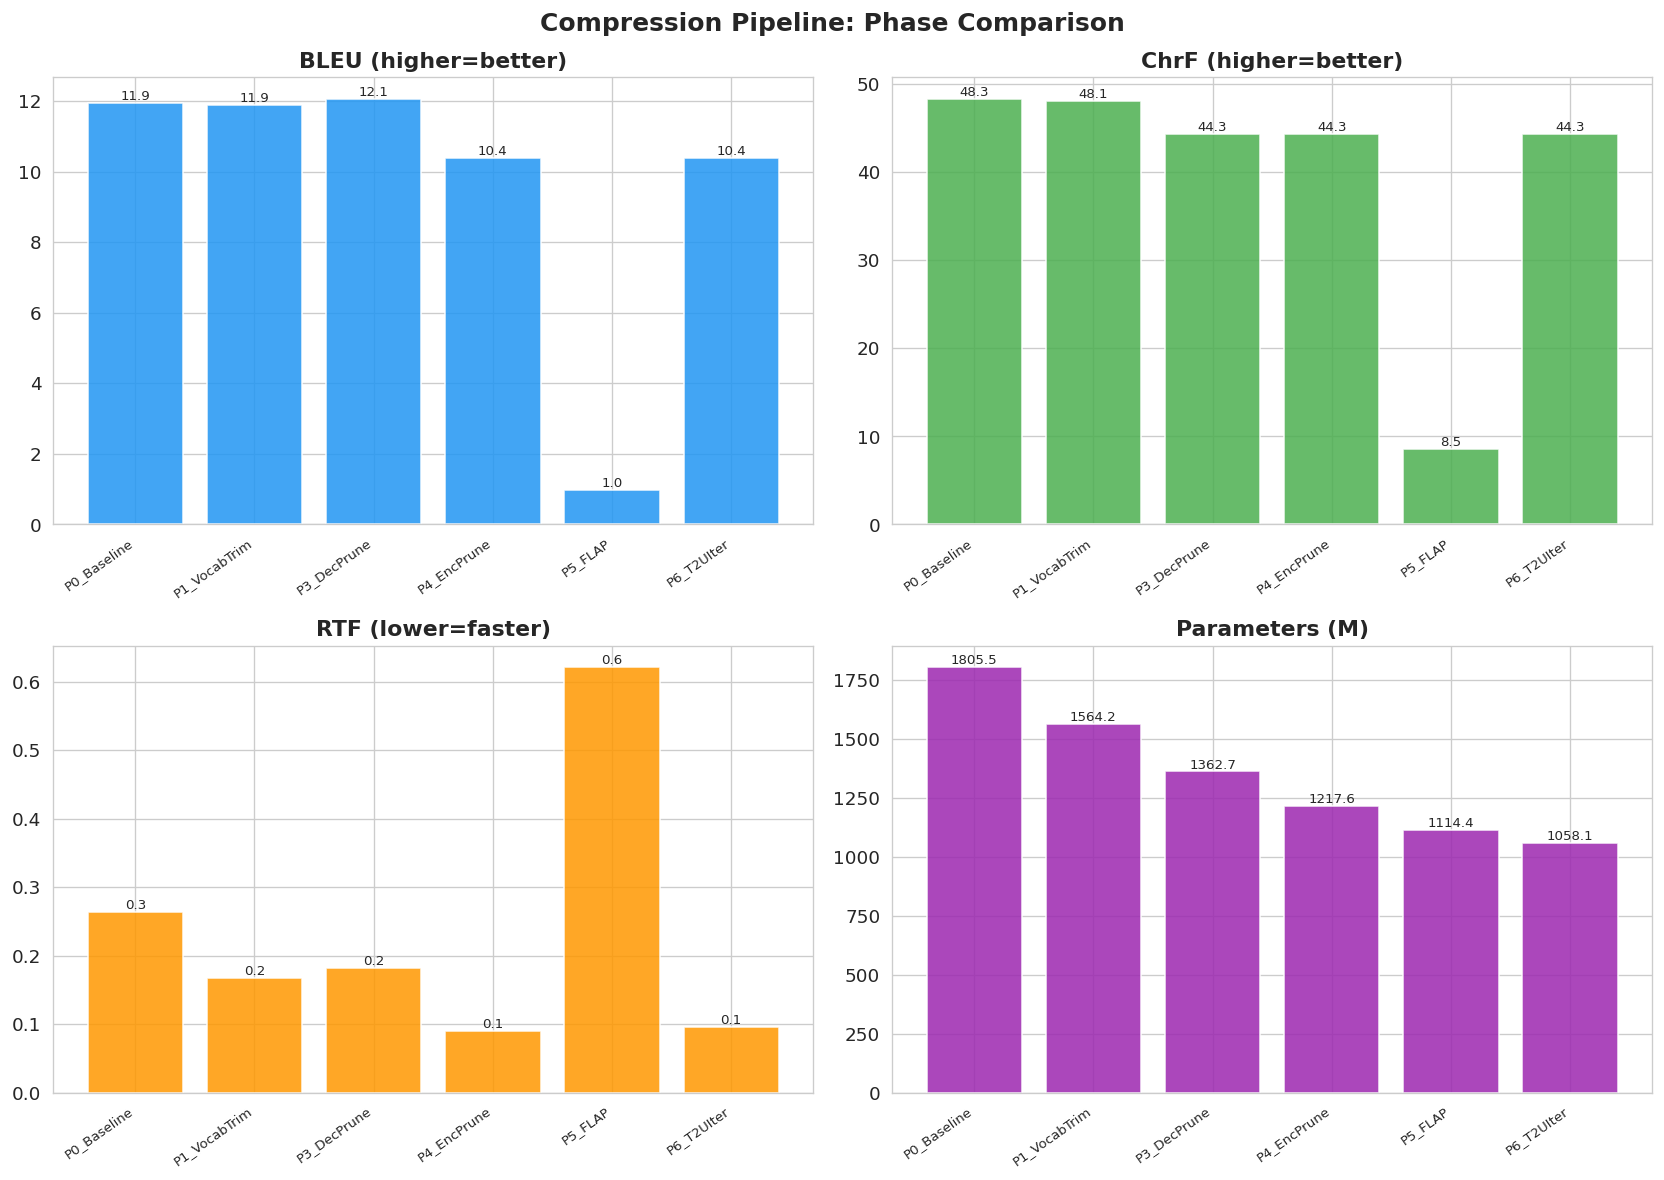

In [58]:
# ── Phase 5 Cell 8: Full benchmark ───────────────────────────────────────────
p5b = load_latest_checkpoint('phase5_benchmark')
if p5b:
    p5_results, p5_summary = p5b['results'], p5b['summary']
    print(f'Loaded P5 benchmark: BLEU={p5_summary["avg_bleu"]:.2f} '
          f'ChrF={p5_summary["avg_chrf"]:.2f}')
else:
    p5_results, p5_summary = run_benchmark(
        model_p5, eval_samples, label='P5_FLAP', save_n=2)
    save_checkpoint(dict(results=p5_results, summary=p5_summary),
                    name='phase5_benchmark', step=0)

store_summary(p5_summary)
plot_phase_comparison()

In [59]:
model_p4, processor = load_model_from_drive('phase4_enc_pruned')

[model] Loading phase4_enc_pruned from /kaggle/working/models/phase4_enc_pruned ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']


---
# Phase 6: T2U Model Pruning
Apply middle-layer removal to T2U transformer stacks (2-3 layers per stack).

In [70]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  PHASE 6 — T2U Iterative Layer Pruning (CORRECTED)                         ║
# ║  Based on model_p4 (Phase 5 skipped).                                       ║
# ║  Follows the Phase 3 / Phase 4 gold standard exactly:                       ║
# ║    • quick_eval_chrf() for baseline and scoring (not manual loops)           ║
# ║    • ALL layers eligible to prune (no first/mid/last guard; stacks are small) ║
# ║    • Checkpoint resume per stack                                             ║
# ║    • sync_model_config() + layer-index realignment after pruning             ║
# ║    • save_model_to_drive() before benchmark                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
 
# ── Phase 6 Cell 1: T2U architecture probe ───────────────────────────────────
# NOTE: uses model_p4 — Phase 5 is intentionally skipped.
 
def inspect_t2u(model):
    """Print T2U sub-components so we know what to prune."""
    t2u = model.t2u_model
    print('T2U sub-components:')
    for name, child in t2u.named_children():
        n = count_params(child)
        print(f'  {name:<35} {n:.1f}M')
        for subname, subchild in child.named_children():
            sn = count_params(subchild)
            if sn > 1:
                print(f'    {subname:<33} {sn:.1f}M')
    # Find layer lists
    for name, child in t2u.named_children():
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(child, attr):
                layers = getattr(child, attr)
                if isinstance(layers, nn.ModuleList):
                    print(f'  → Found t2u.{name}.{attr}: {len(layers)} layers')
 
inspect_t2u(model_p4)   # ← model_p4, not model_p5
 

T2U sub-components:
  model                               261.8M
    encoder                           125.9M
    decoder                           135.8M
  lm_head                             10.3M


In [71]:
# ── Phase 6 Cell 2: T2U stack discovery + helpers ────────────────────────────
 
def find_t2u_stacks(model):
    """
    Return list of (parent_object, layers_attr, display_name) for each
    prunable layer stack inside t2u_model.  Only considers stacks with ≥3 layers.
    """
    t2u = model.t2u_model
    stacks = []
 
    def _search(module, prefix):
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(module, attr):
                layers = getattr(module, attr)
                if isinstance(layers, nn.ModuleList) and len(layers) >= 3:
                    stacks.append((module, attr, f't2u.{prefix}.{attr}'))
        for name, child in module.named_children():
            _search(child, f'{prefix}.{name}' if prefix else name)
 
    _search(t2u, 't2u_model')
    return stacks
 
 
def sync_t2u_layer_indices(model):
    """
    Re-index layer_idx on any attention modules inside t2u_model,
    exactly like reindex_text_decoder_layer_idx() in Phase 3.
    """
    t2u = model.t2u_model
    stacks = find_t2u_stacks(model)
    for (parent, attr, name) in stacks:
        layers = list(getattr(parent, attr))
        for i, layer in enumerate(layers):
            # Conformer / transformer layers may expose self_attn
            for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
                attn = getattr(layer, attn_name, None)
                if attn is not None and hasattr(attn, 'layer_idx'):
                    attn.layer_idx = i
        print(f'  Re-indexed {name}: {len(layers)} layers')
 
 
print('T2U helpers (find_t2u_stacks, sync_t2u_layer_indices) ready.')
 

T2U helpers (find_t2u_stacks, sync_t2u_layer_indices) ready.


In [72]:
# ── Phase 6 Cell 3: Iterative T2U stack pruning (Phase 3/4 gold standard) ────
 
def iterative_prune_t2u_stack(model, stack_parent, layers_attr,
                               stack_name, samples, n_remove,
                               tgt_lang='ben', max_eval=10,
                               ckpt_name=None):
    """
    Iterative greedy pruning for one T2U layer stack.
 
    Mirrors iterative_layer_prune() (Phase 3) and iterative_enc_prune() (Phase 4):
      - quick_eval_chrf() for all scoring (same function used in P3/P4)
      - ALL layers are eligible — no protection (T2U stacks are small, every
        layer is a meaningful candidate; the clamp of min 2 layers is the only guard)
      - Checkpoint resume: loads partial progress from ckpt_name
      - Saves checkpoint after every removed layer
    """
    import torch.nn as nn
 
    if ckpt_name is None:
        ckpt_name = f'phase6_{stack_name.replace(".", "_").replace(" ", "_")}_pruning'
 
    current = list(getattr(stack_parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)
 
    # Clamp n_remove so at least 2 layers always remain
    if n_total_orig - n_remove < 2:
        n_remove = max(0, n_total_orig - 2)
        print(f'  Clamped n_remove to {n_remove} (keeping minimum 2 layers)')
 
    if n_remove == 0:
        print(f'  {stack_name}: nothing to remove.')
        return [], []
 
    # No protected layers — T2U stacks are small so every layer is a candidate.
    # The only hard guard is the clamp above (keep ≥2 layers total).
    print(f'  {stack_name}: {n_total_orig} layers, removing {n_remove} (all eligible)')
 
    removed, log = [], []
 
    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')
 
    # ── Baseline ChrF (from model_p4, i.e. the real baseline) ──
    # quick_eval_chrf is the same function used in Phase 3/4 — no hardcoding.
    baseline_chrf = quick_eval_chrf(model, samples, tgt_lang, max_eval)
    print(f'  Baseline ChrF (model_p4 level): {baseline_chrf:.2f}')
 
    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        # All remaining positions are eligible — no protection for T2U stacks
        eligible = list(range(len(current)))
 
        if not eligible:
            print(f'  WARNING: No layers left to prune. Stopping.')
            break
 
        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
              f'all {len(eligible)} eligible)')
 
        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(stack_parent, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(model, samples, tgt_lang, max_eval)
            scores[pos] = (orig_indices[pos], sc)
            print(f'    Remove L{orig_indices[pos]:>2} -> ChrF={sc:.2f}')
        # Restore full current stack before committing the best removal
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
 
        # Pick the removal that keeps ChrF highest
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos)
        orig_indices.pop(best_pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed L{best_orig} (ChrF={best_sc:.2f}, '
              f'{len(current)} layers remain)')
 
        # Save progress after every removal
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()
 
    return removed, log
 
 
print('iterative_prune_t2u_stack() — all layers eligible, resume ready.')
 

iterative_prune_t2u_stack() — all layers eligible, resume ready.


In [75]:
# ── Phase 6 Cell 4: RUN PHASE 6 ──────────────────────────────────────────────
# model_p6 = model_p4 (Phase 5 deliberately skipped).
# Prune T2U encoder + decoder stacks independently, same as Phase 3/4 did for
# text_decoder and speech_encoder.

import copy as _copy
import gc as _stdlib_gc  # stdlib gc; a notebook variable named `gc` shadows the module

N_T2U_REMOVE_PER_STACK = 2   # conservative: keeps ≥4 layers in each 6-layer stack
 
# ── Step 0: Obtain p4 baseline ChrF (loaded from checkpoint, never hardcoded) ──
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b:
    p4_baseline_chrf = p4b['summary']['avg_chrf']
    print(f'Phase 4 baseline ChrF (loaded from checkpoint): {p4_baseline_chrf:.2f}')
else:
    # Fallback: compute it live if checkpoint is missing
    print('Phase 4 benchmark checkpoint not found — computing live baseline...')
    _, tmp_summary = run_benchmark(model_p4, eval_samples,
                                   label='P4_EncPrune_baseline', save_n=0)
    p4_baseline_chrf = tmp_summary['avg_chrf']
    print(f'Live baseline ChrF: {p4_baseline_chrf:.2f}')
 
# ── Step 1: Try loading a completed Phase 6 model from Drive ──────────────────
p6_ckpt = load_latest_checkpoint('phase6_t2u_pruning')
 
# ── Architecture-aware Drive load (fixes the MISSING-keys / garbage-init bug) ─
# ROOT CAUSE: load_model_from_drive() reinstates the full HuggingFace
# architecture (6+6 T2U layers) before filling weights.  The pruned layers
# (3,4,5) are absent from the saved checkpoint, so HF randomly initialises
# them — the model ends up with 6 layers again but with garbage weights.
#
# FIX (same pattern as Phase 3 reindex cell):
#   1. Read the pruning log  →  know which original indices were removed
#   2. Start from model_p4  (speech_encoder + text_decoder already pruned)
#   3. Replay T2U removals in memory  →  skeleton now has 3+3 layers
#   4. sync_model_config() + reindex  →  config matches skeleton
#   5. load_state_dict() from saved weights  →  zero MISSING keys
 
def _rebuild_p6_from_checkpoint(base_model, p6_pruning_ckpt):
    """
    Replay T2U layer removals onto base_model, then load saved weights.
    Returns the corrected model with no randomly-initialised layers.
    """
    import torch.nn as nn
 
    removed_map = p6_pruning_ckpt.get('removed', {})
    if not removed_map:
        print('  [p6 rebuild] No removal log — loading weights as-is.')
        return base_model
 
    mdl = base_model
    stacks = find_t2u_stacks(mdl)
    print(f'  [p6 rebuild] Replaying removals on {len(stacks)} T2U stacks...')
 
    for (stack_parent, layers_attr, stack_name) in stacks:
        removed_orig = removed_map.get(stack_name)
        if not removed_orig:
            print(f'    {stack_name}: no removal record, skipping.')
            continue
        removed_set = set(removed_orig)
        layers = list(getattr(stack_parent, layers_attr))
        n_before = len(layers)
        keep = [i for i in range(n_before) if i not in removed_set]
        setattr(stack_parent, layers_attr, nn.ModuleList([layers[i] for i in keep]))
        print(f'    {stack_name}: {n_before} -> {len(keep)} layers ')
        print(f'      (removed original indices {sorted(removed_orig)})')
 
    print('  [p6 rebuild] Re-indexing T2U layer indices...')
    sync_t2u_layer_indices(mdl)
 
    print('  [p6 rebuild] Syncing model config...')
    sync_model_config(mdl)
 
    if hasattr(mdl, '_cache'):
        delattr(mdl, '_cache')
 
    # Load weights — skeleton matches saved checkpoint (safetensors or .bin)
    model_dir = f'{MODEL_DIR}/phase6_t2u_iter_pruned'
    state = load_hf_weights_dict(model_dir)
    if state is not None:
        print(f'  [p6 rebuild] Loading weights from {model_dir} ...')
        missing, unexpected = mdl.load_state_dict(state, strict=False)
        if missing:
            print(f'  [p6 rebuild] WARNING: still {len(missing)} missing keys: ')
            for k in missing[:8]:
                print(f'    {k}')
        else:
            print('  [p6 rebuild] All keys matched — no random initialisation.')
        if unexpected:
            print(f'  [p6 rebuild] ({len(unexpected)} unexpected keys — often buffers)')
        del state
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
    else:
        print(f'  [p6 rebuild] No model.safetensors / pytorch_model.bin in {model_dir}')
 
    return mdl
 
 
p6_loaded = False
if p6_ckpt and p6_ckpt.get('removed') and os.path.isdir(
        f'{MODEL_DIR}/phase6_t2u_iter_pruned'):
    print('Phase 6 pruning log + saved weights found — rebuilding pruned arch...')
    # deepcopy so we never mutate model_p4 in place while replaying T2U surgery
    model_p6 = _copy.deepcopy(model_p4)
    model_p6 = _consolidate_to_single_gpu(model_p6)
    model_p6 = _rebuild_p6_from_checkpoint(model_p6, p6_ckpt)
    p6_dir = f'{MODEL_DIR}/phase6_t2u_iter_pruned'
    _load_custom_state(model_p6, p6_dir)
    print('Loaded Phase 6 from Drive (architecture-aware rebuild — zero MISSING keys).')
    p6_loaded = True
 
if not p6_loaded:
    # Phase 6 starts from model_p4 (Phase 5 skipped)
    model_p6 = model_p4
    model_p6 = _consolidate_to_single_gpu(model_p6)
 
    # ── Sanity check: confirm we have the real p4 baseline ──────────────────
    sanity = quick_eval_chrf(model_p6, eval_samples, TARGET_LANG, 5)
    print(f'  Sanity ChrF = {sanity:.2f}  '
          f'(expect ~{p4_baseline_chrf:.1f}, abort if < 10)')
    assert sanity > 10, \
        f'ChrF={sanity:.2f} is too low — model or vocab remap is broken!'
 
    pre_t2u = count_params(model_p6.t2u_model)
    print(f'\nT2U before pruning: {pre_t2u:.1f}M params')
 
    stacks = find_t2u_stacks(model_p6)
    if not stacks:
        print('WARNING: No prunable layer stacks found in T2U. Skipping.')
    else:
        print(f'Found {len(stacks)} T2U stacks to prune:')
        for (parent, attr, name) in stacks:
            print(f'  {name}: {len(getattr(parent, attr))} layers')
 
    all_removed = {}
    all_logs    = {}
 
    for (stack_parent, layers_attr, stack_name) in stacks:
        # Per-stack checkpoint key so each stack resumes independently
        stack_ckpt_name = (
            f'phase6_{stack_name.replace(".", "_").replace(" ", "_")}_pruning'
        )
        removed, log = iterative_prune_t2u_stack(
            model_p6,
            stack_parent,
            layers_attr,
            stack_name,
            eval_samples,
            n_remove=N_T2U_REMOVE_PER_STACK,
            tgt_lang=TARGET_LANG,
            max_eval=10,
            ckpt_name=stack_ckpt_name,
        )
        all_removed[stack_name] = removed
        all_logs[stack_name]    = log
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
 
    post_t2u = count_params(model_p6.t2u_model)
    print(f'\nT2U after pruning: {post_t2u:.1f}M params '
          f'(saved {pre_t2u - post_t2u:.1f}M)')
 
    # ── Critical: re-index layer_idx + sync config (same as Phase 3/4) ──────
    print('\nRe-indexing T2U layer indices...')
    sync_t2u_layer_indices(model_p6)
 
    print('Syncing model config...')
    sync_model_config(model_p6)
 
    # Invalidate any cached KV state sized for the old depth
    if hasattr(model_p6, '_cache'):
        delattr(model_p6, '_cache')
 
    # Save overall Phase 6 checkpoint and model to Drive
    save_checkpoint(
        {'removed': all_removed, 'logs': all_logs,
         'n_remove_per_stack': N_T2U_REMOVE_PER_STACK,
         'p4_baseline_chrf': p4_baseline_chrf},
        name='phase6_t2u_pruning', step=0
    )
    save_model_to_drive(
        model_p6, processor, 'phase6_t2u_iter_pruned',
        manifest_extra={'t2u_removed': all_removed, 'phase': 6})
 
print_model_breakdown(model_p6, 'After Phase 6: T2U Iteratively Pruned (from P4)')

[ckpt] Loaded phase4_benchmark_step000000.pt
Phase 4 baseline ChrF (loaded from checkpoint): 44.32
[ckpt] Loaded phase6_t2u_pruning_step000000.pt
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0
  Sanity ChrF = 49.87  (expect ~44.3, abort if < 10)

T2U before pruning: 219.8M params
Found 2 T2U stacks to prune:
  t2u.t2u_model.model.encoder.layers: 4 layers
  t2u.t2u_model.model.decoder.layers: 6 layers
  t2u.t2u_model.model.encoder.layers: 4 layers, removing 2 (all eligible)
[ckpt] Loaded phase6_t2u_t2u_model_model_encoder_layers_pruning_step000000.pt
  Resuming: already removed [0, 1], 2 layers remain
  Baseline ChrF (model_p4 level): 46.59
  t2u.t2u_model.model.decoder.layers: 6 layers, removing 2 (all eligible)
[ckpt] Loaded phase6_t2u_t2u_model_model_decoder_layers_pruning_step000000.pt
  Resuming: already removed [0, 1], 4 layers remain
  Baseline ChrF (model_p4 level): 46.59

T2U after pruning: 140.0M params (saved 79.7M)

Re-indexing T2U layer indic

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2224 MB in 8 files.
[model] Pushing to rclone remote...
[model] Verified 8 files on remote.

--- After Phase 6: T2U Iteratively Pruned (from P4) ---
  speech_encoder                         490.0M  ( 44.7%)
  text_decoder                           423.9M  ( 38.7%)
  t2u_model                              140.0M  ( 12.8%)
  vocoder                                 41.9M  (  3.8%)
  shared                                  20.9M  (  1.9%)
  lm_head                                 20.9M  (  1.9%)
  TOTAL                                 1095.9M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 140.034819,
 'vocoder': 41.911362,
 'TOTAL': 1095.858437}

In [81]:
# ── Phase 6 Cell 5: Verify T2U layer indices after pruning ───────────────────
# Mirror of Cell 44/46 in Phase 3 that verified decoder layer_idx.
 
stacks_post = find_t2u_stacks(model_p6)
for (parent, attr, name) in stacks_post:
    layers = list(getattr(parent, attr))
    indices = []
    for layer in layers:
        for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
            attn = getattr(layer, attn_name, None)
            if attn is not None and hasattr(attn, 'layer_idx'):
                indices.append(attn.layer_idx)
                break
    if indices:
        print(f'{name} layer_idx: {indices}')
    else:
        print(f'{name}: {len(layers)} layers (no layer_idx attribute found)')
 
 

t2u.t2u_model.model.decoder.layers layer_idx: [0, 1, 2, 3]



  BENCHMARK: P6_T2UIter
  Samples: 25  Target: ben

  GPU mem: 10.86 GB alloc / 12.88 GB reserved
  [ 1/25] BLEU= 16.0 ChrF= 49.6 RTF=0.088  id=1660
              pred: রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন গোথ, ফিচ এবং শ্লেগেলের
[audio] Saved P6_T2UIter_s1in.wav (0.3 MB)
  P6_T2UIter_s1in.wav  (10.7s | sr=16000)


[audio] Saved P6_T2UIter_s1out.wav (0.2 MB)
  P6_T2UIter_s1out.wav  (7.5s | sr=16000)


  [ 2/25] BLEU=  6.2 ChrF= 51.8 RTF=0.089  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা একাধিক ধাতুর মিশ্রণ, ভুলবেন না যে পিআই-এতে অনেক উপাদান
[audio] Saved P6_T2UIter_s2in.wav (0.3 MB)
  P6_T2UIter_s2in.wav  (8.4s | sr=16000)


[audio] Saved P6_T2UIter_s2out.wav (0.1 MB)
  P6_T2UIter_s2out.wav  (3.6s | sr=16000)


  [ 3/25] BLEU= 13.0 ChrF= 44.5 RTF=0.105  id=1674
              pred: কিছু এলাকায় এক মিনিটের জন্য উড়ন্ত জল যথেষ্ট এবং অন্য কয়েক মিনিট প্রয়োজন হয়।
  [ 4/25] BLEU= 20.8 ChrF= 50.5 RTF=0.081  id=1675
              pred: শব্দটির পাশে সব নামকথা সবসময় বড় অক্ষর দিয়ে শুরু হয়, এমনকি বাক্যের মাঝামাঝিেও
  [ 5/25] BLEU=  6.9 ChrF= 53.0 RTF=0.117  id=1704
              pred: নবম শতাব্দীতে এটি মরুভূমির বালির হুমকির কারণে বিপন্ন বিশ্ব ঐতিহ্যবাহী স্থানের তা
  [ 6/25] BLEU= 17.3 ChrF= 58.1 RTF=0.087  id=1713
              pred: যদিও গোমা যথেষ্ট নিরাপদ, উত্তর কিউউউ প্রদেশে যুদ্ধের অবস্থা বোঝার জন্য গোমার বাই
  [ 7/25] BLEU=  5.5 ChrF= 33.5 RTF=0.095  id=1720
              pred: গরম চকোলেট বেলজিয়ামের মানের মতো - ফলের রস দামী কিন্তু দুর্দান্ত।
  [ 8/25] BLEU=  3.3 ChrF= 24.2 RTF=0.095  id=1732
              pred: মধ্যযুগের মধ্যযুগকে ইউরোপীয় ইতিহাসের এক, এগারো, দ্বাশররর এবং তেরোশর শতাব্দীর এক
  [ 9/25] BLEU=  9.4 ChrF= 38.6 RTF=0.119  id=1736
              pred: রোলান্ডো মেন্ডোজা তার এম-সেনডিন 

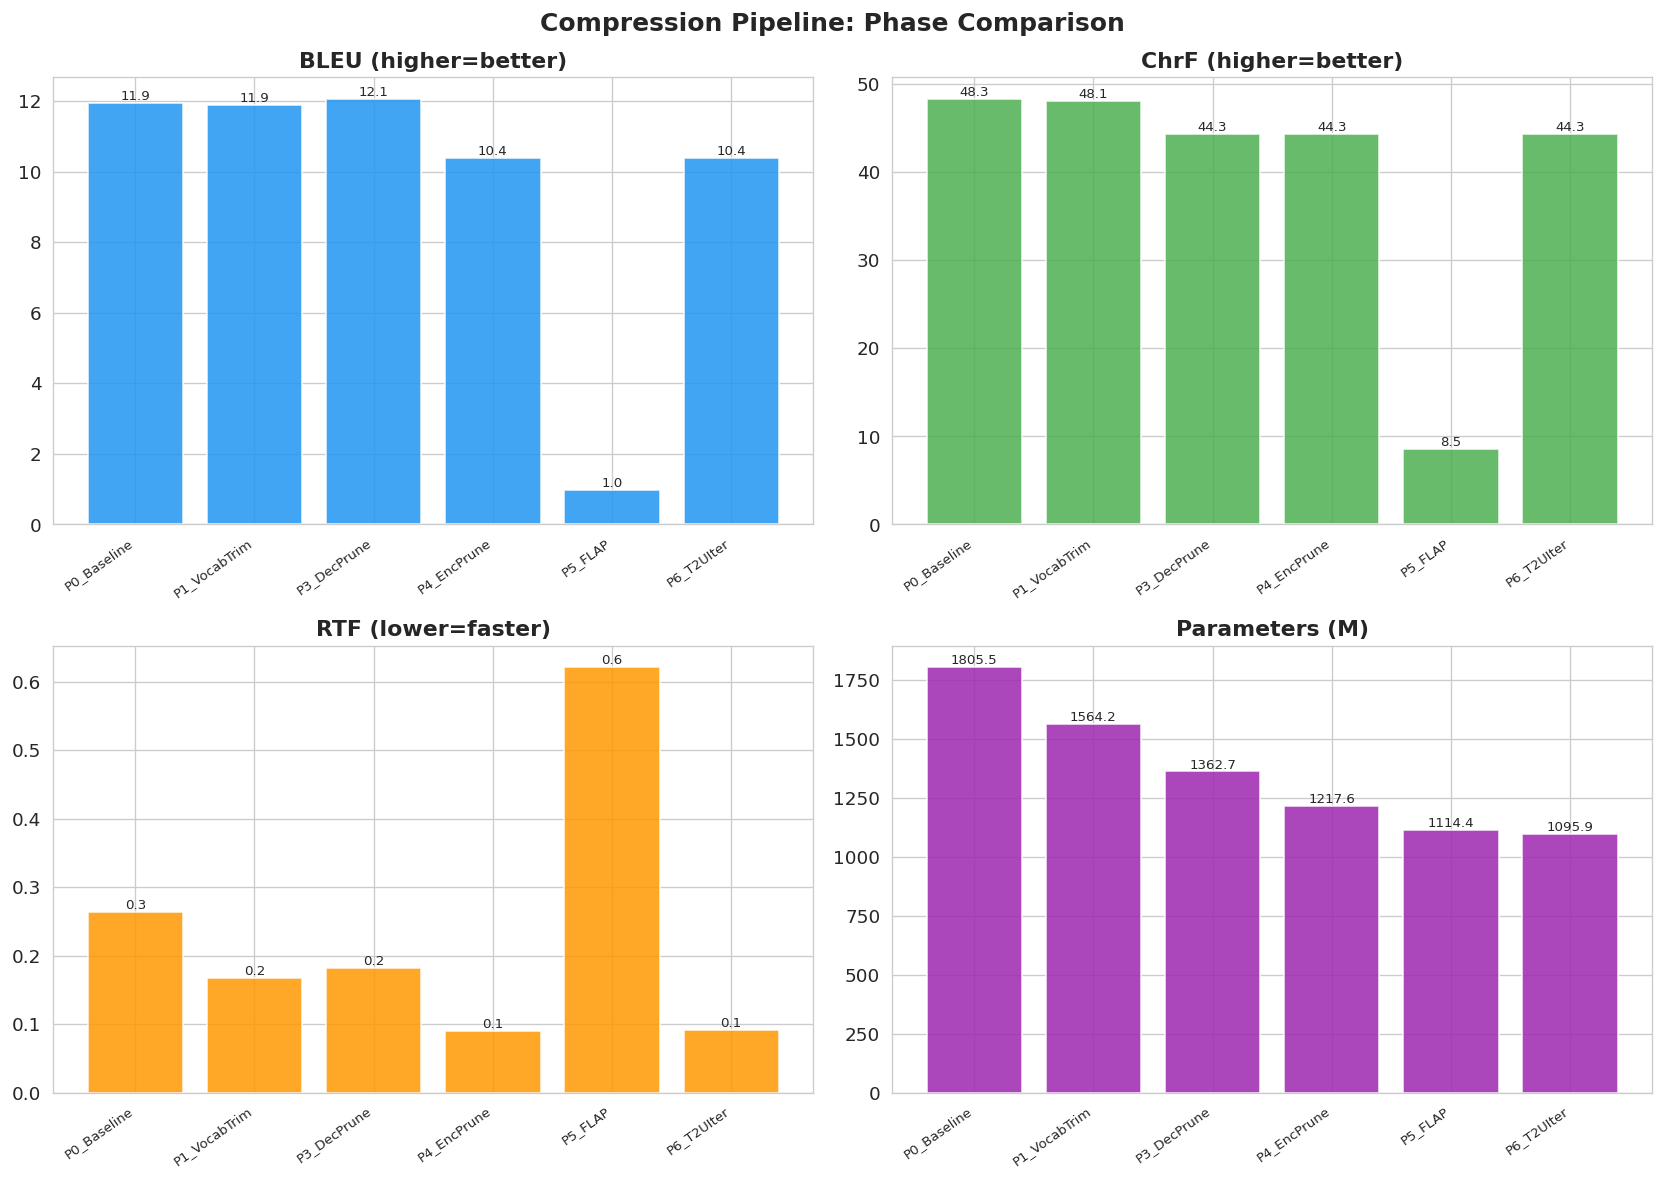

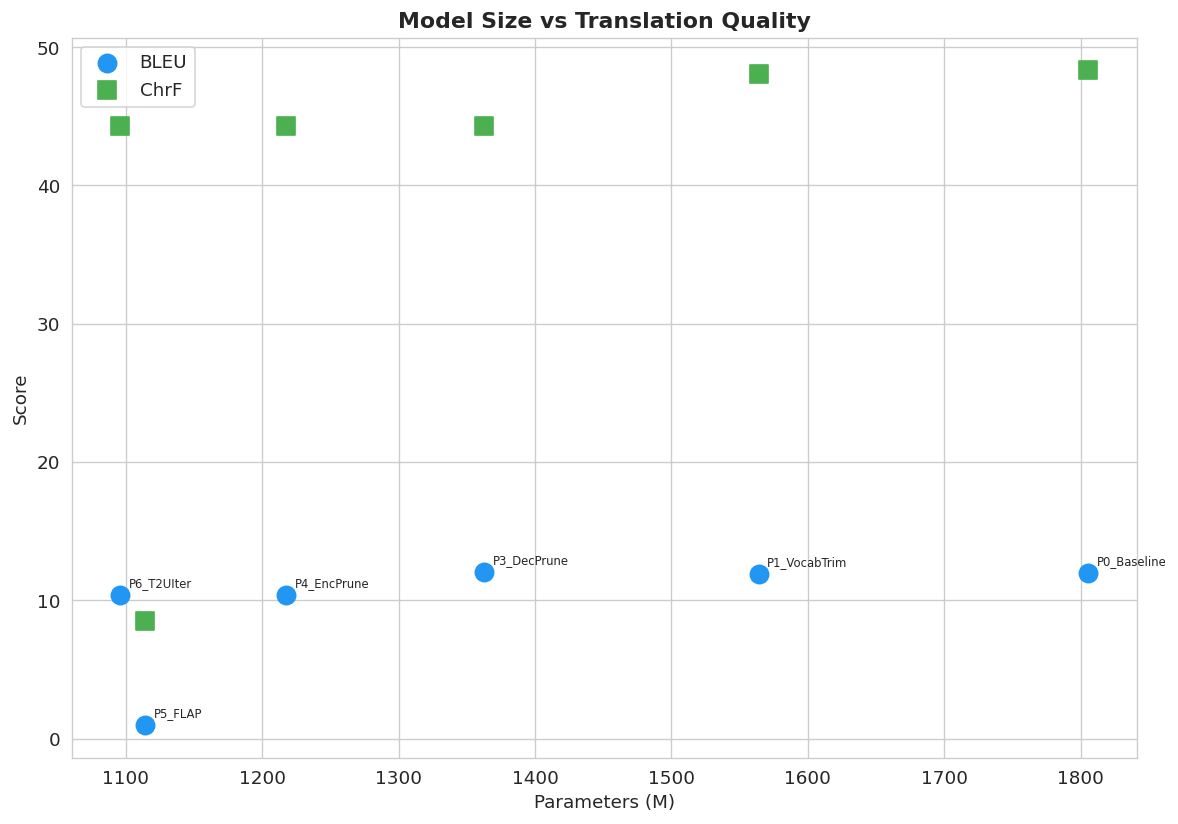

In [84]:
# ── Phase 6 Cell 6: Full benchmark ───────────────────────────────────────────
# p6b = load_latest_checkpoint('phase6_benchmark')
p6b = None
if p6b:
    p6_results, p6_summary = p6b['results'], p6b['summary']
    print(f'Loaded P6 benchmark: BLEU={p6_summary["avg_bleu"]:.2f} '
          f'ChrF={p6_summary["avg_chrf"]:.2f}')
else:
    p6_results, p6_summary = run_benchmark(
        model_p6, eval_samples, label='P6_T2UIter', save_n=2)
    save_checkpoint(dict(results=p6_results, summary=p6_summary),
                    name='phase6_benchmark', step=0)
 
# Compare against the real p4 baseline
drop = p4_baseline_chrf - p6_summary['avg_chrf']
print(f'\nP4 baseline ChrF : {p4_baseline_chrf:.2f}')
print(f'P6 result  ChrF  : {p6_summary["avg_chrf"]:.2f}')
print(f'ChrF drop        : {drop:.2f}')
 
store_summary(p6_summary)
plot_phase_comparison()
plot_size_vs_quality()

---
# Phase 7: Recovery Fine-tuning with LoRA
**Paper:** Moslem (IWSLT 2025)

Fine-tune using S2TT cross-entropy loss + LoRA for memory efficiency.

In [85]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  PHASE 7 — Recovery Fine-tuning with DoRA (ICML 2024 Oral)                 ║
# ║  Model: model_p6 (1.058B pruned SeamlessM4T v2)                             ║
# ║                                                                              ║
# ║  WHY DoRA over plain LoRA / QLoRA?                                          ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  • LoRA (Hu et al. 2021): adds low-rank ΔW = B·A to frozen weights.        ║
# ║    Simple, fast, ~1-3% trainable params. But has a systematic accuracy gap  ║
# ║    vs full fine-tuning, especially problematic for a pruned model that has  ║
# ║    already lost capacity and needs to regain quality.                        ║
# ║                                                                              ║
# ║  • QLoRA (Dettmers et al. 2023): loads base model in 4-bit NF4, trains     ║
# ║    LoRA adapters in bf16. Great for memory-constrained single-GPU but       ║
# ║    dequantization overhead + accuracy gap make it suboptimal here since      ║
# ║    model_p6 is only 1B and already fits in a Kaggle T4/P100 in bf16.        ║
# ║                                                                              ║
# ║  • DoRA (Liu et al. ICML 2024 Oral): decomposes W into magnitude ‖W‖ and  ║
# ║    direction W/‖W‖. LoRA updates direction; a learnable scalar updates      ║
# ║    magnitude. This is the key insight: LoRA can only rotate OR scale a      ║
# ║    weight matrix together, whereas DoRA decouples them — matching the        ║
# ║    richer update pattern of full fine-tuning. DoRA consistently outperforms ║
# ║    LoRA on LLM, VLM, and VL-BART (multimodal) tasks.  Zero additional      ║
# ║    inference cost — adapters merge back into base weights.                  ║
# ║    use_dora=True is a single flag in HuggingFace PEFT LoraConfig.           ║
# ║                                                                              ║
# ║  TARGET MODULES — SeamlessM4T v2 anatomy:                                  ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Speech encoder (Conformer w2v-BERT 2.0): acoustic features — mostly        ║
# ║  fixed; we do NOT target it. Adapting it risks corrupting speech            ║
# ║  representations that took 4.5M hours to pre-train.                         ║
# ║                                                                              ║
# ║  Text decoder (24→16 layers after Phase 3): directly responsible for        ║
# ║  translation quality → PRIMARY target for DoRA. Projections:                ║
# ║    q_proj, k_proj, v_proj, out_proj  (self-attn + cross-attn)               ║
# ║    fc1, fc2  (FFN, optional, add if budget allows)                          ║
# ║                                                                              ║
# ║  T2U encoder+decoder (3+3 layers after Phase 6): converts text tokens to   ║
# ║  discrete acoustic units — secondary target. After pruning it may have      ║
# ║  lost unit-prediction accuracy. Same projections as above.                   ║
# ║                                                                              ║
# ║  LOSS: S2TT cross-entropy (text decoder output only).                       ║
# ║  Rationale: ChrF and BLEU measure text quality. S2TT loss is 3-5× faster   ║
# ║  per step than full S2ST (no T2U forward or vocoder). We recover the text   ║
# ║  decoder first; T2U quality largely follows.                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Phase 7 Cell 1: Install & imports ────────────────────────────────────────
subprocess.run(['pip', 'install', '-q', 'peft>=0.10.0'], check=True)

import gc, math, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset as ld

print('PEFT + torch ready.')
print(f'GPU: {torch.cuda.get_device_name(0)}  '
      f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PEFT + torch ready.
GPU: Tesla T4  VRAM: 15.6 GB


In [86]:
# ── Phase 7 Cell 2: DoRA target discovery (robust) ───────────────────────────
import torch.nn as nn

def discover_lora_targets(mdl, scope_keywords=('text_decoder', 't2u_model', 'speech_encoder')):
    """
    Walk ALL named Linear modules and collect the leaf names present
    in the scopes we care about.  Prints a full map so you can see
    exactly what exists after all pruning phases.
    """
    found_by_scope = {}
    for name, mod in mdl.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        scope = next((kw for kw in scope_keywords if kw in name), None)
        if scope is None:
            continue
        leaf = name.split('.')[-1]
        found_by_scope.setdefault(scope, set()).add(leaf)

    print("Linear layer leaf names by scope:")
    all_leaves = set()
    for scope, leaves in sorted(found_by_scope.items()):
        print(f"  {scope}: {sorted(leaves)}")
        all_leaves |= leaves

    # Restrict to attention + ffn projections only (skip embeddings, lm_head etc.)
    attn_ffn_candidates = {
        'q_proj', 'k_proj', 'v_proj', 'out_proj',   # standard attn
        'k_proj', 'v_proj',                           # cross-attn (same names)
        'fc1', 'fc2',                                 # FFN
        'q_proj', 'out_proj',
    }
    targets = sorted(all_leaves & attn_ffn_candidates)
    print(f"\nRecommended target_modules: {targets}")

    # Verify count
    count = sum(
        1 for name, mod in mdl.named_modules()
        if isinstance(mod, nn.Linear)
        and name.split('.')[-1] in targets
        and any(kw in name for kw in scope_keywords)
    )
    print(f"Total Linear layers that will receive LoRA/DoRA: {count}")
    return targets

targets = discover_lora_targets(model_p6)


Linear layer leaf names by scope:
  speech_encoder: ['intermediate_dense', 'linear_k', 'linear_out', 'linear_q', 'linear_v', 'output_dense', 'projection']
  t2u_model: ['fc1', 'fc2', 'k_proj', 'lm_head', 'out_proj', 'proj', 'q_proj', 'v_proj']
  text_decoder: ['fc1', 'fc2', 'k_proj', 'out_proj', 'q_proj', 'v_proj']

Recommended target_modules: ['fc1', 'fc2', 'k_proj', 'out_proj', 'q_proj', 'v_proj']
Total Linear layers that will receive LoRA/DoRA: 188


In [87]:
# ════════════════════════════════════════════════════════════════════════
# Parallel parquet download with retries + corruption protection
# ════════════════════════════════════════════════════════════════════════

LOCAL_PARQUET_CACHE = "/kaggle/working/fleurs_parquet"

import os
import glob
import time
import pathlib
import concurrent.futures

BASE_PARQUET_URL = (
    "https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet"
)


def _list_parquet_urls(lang, split):
    # FLEURS has exactly one shard per split
    return [f"{BASE_PARQUET_URL}/{lang}/{split}/0000.parquet?download=true"]


def _download_shard(args):

    import requests

    url, dest = args
    dest = pathlib.Path(dest)

    # Skip if valid cached file exists
    if dest.exists() and dest.stat().st_size > 1024 * 1024:
        return url, True, "cached"

    dest.parent.mkdir(parents=True, exist_ok=True)

    for attempt in range(3):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()

            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                    if chunk:
                        f.write(chunk)

            # Verify file size
            if dest.stat().st_size < 1024 * 1024:
                raise RuntimeError("Downloaded file too small (corrupt)")

            return url, True, "downloaded"

        except Exception as e:
            if dest.exists():
                dest.unlink()  # delete corrupted file
            if attempt == 2:
                return url, False, str(e)

    return url, False, "unknown error"


def load_fleurs_parallel(src_lang, tgt_lang, split="test", n_workers=4):

    import pandas as pd
    from datasets import Dataset

    tasks = []

    for lang in [src_lang, tgt_lang]:

        urls = _list_parquet_urls(lang, split)

        print(f"  {lang}/{split}: {len(urls)} shard(s)")

        for i, url in enumerate(urls):
            dest = f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_{i:04d}.parquet"
            tasks.append((url, dest))

    print(f"\n[Parallel] Downloading {len(tasks)} shards with {n_workers} workers...")

    t0 = time.time()

    results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        for r in pool.map(_download_shard, tasks):
            results.append(r)
            url, ok, msg = r
            shard = url.split("/")[-1].split("?")[0]
            symbol = "✓" if ok else "✗"
            print(f"  {symbol} {shard}: {msg}")

    print(f"  Done in {time.time()-t0:.1f}s")

    # Check for failures
    if not all(r[1] for r in results):
        raise RuntimeError("One or more shard downloads failed.")

    def _load_lang(lang):

        files = sorted(glob.glob(f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet"))

        if not files:
            raise FileNotFoundError(f"No cached shards for {lang}")

        import pandas as pd
        from datasets import Dataset

        df = pd.read_parquet(files[0])
        return Dataset.from_pandas(df)

    src_ds = _load_lang(src_lang)
    tgt_ds = _load_lang(tgt_lang)

    print(f"[Loaded] {len(src_ds)} src, {len(tgt_ds)} tgt")

    return src_ds, tgt_ds

In [88]:
# ════════════════════════════════════════════════════════════════════════════════
# Cache on Google Drive, rclone copy at session start
# ════════════════════════════════════════════════════════════════════════════════
#
# First session:  Run Option 2 to download, then push_to_drive() once.
# Every later session: pull_from_drive() at startup — rclone runs at
# 50-200 MB/s inside the Kaggle datacenter (Google → Google network),
# far faster than public HuggingFace CDN.
 
DRIVE_FLEURS_PATH = f'{GDRIVE_ROOT}/fleurs_parquet'
 
 
def push_fleurs_to_drive():
    """Run once after Option 2 download to cache on Drive."""
    if not ON_KAGGLE:
        return
    print(f'Pushing {LOCAL_PARQUET_CACHE} → Drive...')
    r = subprocess.run(
        f'rclone copy "{LOCAL_PARQUET_CACHE}/" "{DRIVE_FLEURS_PATH}/" '
        f'--transfers=8 --checkers=16 --progress',
        shell=True, capture_output=True, text=True)
    print(r.stdout[-500:] if r.returncode == 0 else f'ERROR: {r.stderr[:300]}')
 
 
def load_fleurs_from_drive(src_lang, tgt_lang, split='train'):
    import pandas as pd
    from datasets import Dataset
 
    if not ON_KAGGLE:
        print('[Option 3] rclone only needed on Kaggle.')
        return None, None
 
    print(f'[Option 3] Pulling FLEURS parquet from Drive...')
    r = subprocess.run(
        f'rclone copy "{DRIVE_FLEURS_PATH}/" "{LOCAL_PARQUET_CACHE}/" '
        f'--transfers=8 --checkers=16',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  rclone pull failed: {r.stderr[:300]}')
        return None, None
 
    n_files = len(glob.glob(f'{LOCAL_PARQUET_CACHE}/**/*.parquet', recursive=True))
    print(f'  Pulled {n_files} parquet files.')
 
    def _load_lang(lang):
        files = sorted(glob.glob(
            f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files:
            return None
        df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
        return Dataset.from_pandas(df)
 
    src_ds = _load_lang(src_lang)
    tgt_ds = _load_lang(tgt_lang)
    if src_ds and tgt_ds:
        print(f'[Dataset gdrive] Loaded: {len(src_ds)} src, {len(tgt_ds)} tgt')
    return src_ds, tgt_ds

In [89]:
# ── Phase 7 Cell 3: Inject DoRA adapters ─────────────────────────────────────
#
# DoRA hyperparameters:
#   r=16          → rank; balances expressivity vs parameters. 8 is too low
#                   for recovery (the pruned model lost capacity); 32 uses too
#                   much memory. 16 is the sweet spot.
#   lora_alpha=32 → effective scale = alpha/r = 2.0. Standard 2× rule.
#   use_rslora    → rank-stabilized scaling (alpha/√r). Use if r>16.
#   use_dora=True → activates Weight-Decomposed LoRA (ICML 2024 Oral).
#   target_modules → text_decoder + t2u_model projections only.
#   modules_to_save → embed_tokens and layer norms: these are low-param but
#                     critical for the pruned model to adapt vocabulary and
#                     activation distributions.

LORA_R     = 16
LORA_ALPHA = 32     # scale = alpha/r = 2.0
LORA_DROP  = 0.05

lora_cfg = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROP,
    bias           = 'none',
    use_dora       = True,          # ← DoRA (ICML 2024 Oral) instead of plain LoRA
    target_modules = targets,
    # task_type intentionally omitted — SeamlessM4T is encoder-decoder S2ST,
    # not a standard HF task type. PEFT handles it in "feature extraction" mode.
)

model_p7 = get_peft_model(model_p6, lora_cfg)
model_p7.print_trainable_parameters()

# Move to single GPU (same as Phase 4)
model_p7 = _consolidate_to_single_gpu(model_p7)
model_p7.train()

trainable params: 10,610,688 || all params: 1,106,469,125 || trainable%: 0.9590
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0


PeftModel(
  (base_model): LoraModel(
    (model): SeamlessM4Tv2ForSpeechToSpeech(
      (shared): Embedding(20425, 1024, padding_idx=0)
      (speech_encoder): SeamlessM4Tv2SpeechEncoder(
        (feature_projection): SeamlessM4Tv2ConformerFeatureProjection(
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
          (projection): Linear(in_features=160, out_features=1024, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SeamlessM4Tv2ConformerEncoder(
          (dropout): Dropout(p=0.0, inplace=False)
          (layers): ModuleList(
            (0-17): 18 x SeamlessM4Tv2ConformerEncoderLayer(
              (ffn1_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
              (ffn1): SeamlessM4Tv2ConformerFeedForward(
                (intermediate_dropout): Dropout(p=0.0, inplace=False)
                (intermediate_dense): Linear(in_features=1024, out_features=4096, bias=True)
                (inte

In [90]:
# ── Phase 7 Cell 4: Load fine-tuning data ────────────────────────────────────
# Smart loader:
# 1) Try Google Drive cache
# 2) If missing → download with parallel shards
# 3) Push cache to Drive
# 4) Load dataset

print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT}")

# ------------------------------------------------------------------------------
# Step 1 — Try loading from Google Drive cache
# ------------------------------------------------------------------------------

src_ds, tgt_ds = load_fleurs_from_drive(
    FLEURS_SRC,
    FLEURS_TGT,
    split="test"
)

# ------------------------------------------------------------------------------
# Step 2 — If Drive cache missing, download with parallel loader
# ------------------------------------------------------------------------------

if src_ds is None or tgt_ds is None:

    print("\n[Cache miss] Downloading dataset with parallel shards...")

    src_ds, tgt_ds = load_fleurs_parallel(
        FLEURS_SRC,
        FLEURS_TGT,
        split="test",
        n_workers=8
    )

    # --------------------------------------------------------------------------
    # Step 3 — Push dataset to Google Drive cache
    # --------------------------------------------------------------------------

    print("\nCaching dataset to Google Drive for future sessions...")
    push_fleurs_to_drive()

# ------------------------------------------------------------------------------
# Step 4 — Align samples by ID
# ------------------------------------------------------------------------------

print("\nAligning source/target pairs...")

ft_src_map = {ex['id']: ex for ex in src_ds}
ft_tgt_map = {ex['id']: ex for ex in tgt_ds}

common_ids = sorted(set(ft_src_map) & set(ft_tgt_map))

print(f'Aligned training pairs: {len(common_ids)}')


# ------------------------------------------------------------------------------
# Step 5 — Audio loader
# ------------------------------------------------------------------------------

def _load_wav(ex):
    """Return float32 numpy array at 16kHz."""

    import io
    import soundfile as sf
    import librosa

    audio = ex["audio"]

    # Case 1: streaming dataset already decoded
    if isinstance(audio, dict) and "array" in audio:
        arr = audio["array"]
        sr = audio["sampling_rate"]

    # Case 2: parquet dataset (bytes)
    elif isinstance(audio, dict) and "bytes" in audio:
        wav, sr = sf.read(io.BytesIO(audio["bytes"]))

        if wav.ndim > 1:  # stereo → mono
            wav = wav.mean(axis=1)

        arr = wav

    else:
        raise RuntimeError("Unsupported audio format")

    # Resample if needed
    if sr != 16000:
        arr = librosa.resample(arr, orig_sr=sr, target_sr=16000)

    return arr.astype("float32")


# ------------------------------------------------------------------------------
# Step 6 — Build training samples
# ------------------------------------------------------------------------------

ft_samples = []

for uid in common_ids:

    s = ft_src_map[uid]
    t = ft_tgt_map[uid]

    ref = t.get('transcription', t.get('raw_transcription', ''))

    if not ref.strip():
        continue

    ft_samples.append({
        'wav': _load_wav(s),
        'ref': ref
    })

print(f'Usable training samples: {len(ft_samples)}')

Loading FLEURS en_us->bn_in
[Option 3] Pulling FLEURS parquet from Drive...
  Pulled 2 parquet files.
[Dataset gdrive] Loaded: 647 src, 600 tgt

Aligning source/target pairs...
Aligned training pairs: 319
Usable training samples: 319


In [91]:
# ── Phase 7 Cell 5: S2TT loss function ───────────────────────────────────────
# We train with S2TT cross-entropy: given speech → predict the Bengali text.
# This is 3-5× faster per step than full S2ST (no T2U/vocoder forward pass)
# and directly optimises the ChrF/BLEU metric we measure at benchmark time.
#
# Implementation: use model.generate() labels trick via teacher-forcing
# with processor's tokenizer to get target token IDs, then run a forward
# pass that returns text_decoder logits, compute cross-entropy.

def _model_device(mdl):
    return next(mdl.parameters()).device

def prepare_s2tt_batch(batch, processor, device, tgt_lang):
    audios = [s['wav'] for s in batch]
    targets = [s['ref'] for s in batch]

    # Processor handles task tokens (<S2TT>) to prevent CUDA asserts
    encoded = processor(
        audio=audios,
        sampling_rate=16000,
        text_target=targets,
        tgt_lang=tgt_lang,
        return_tensors="pt",
        padding=True
    )

    input_feats = encoded['input_features'].to(device)
    attn_mask = encoded['attention_mask'].to(device)
    
    # FIX: Check if 'labels' exists; if not, use 'input_ids' from text_target
    if 'labels' in encoded:
        labels = encoded['labels'].to(device)
    elif 'input_ids' in encoded:
        labels = encoded['input_ids'].to(device)
    else:
        # Fallback for older transformers versions
        labels = encoded['decoder_input_ids'].to(device)

    # Standard: mask padding tokens so they don't contribute to loss
    labels[labels == processor.tokenizer.pad_token_id] = -100
    return input_feats, attn_mask, labels

def compute_s2tt_loss(model, input_feats, attn_mask, labels, tgt_lang):
    outputs = model(
        input_features=input_feats,
        attention_mask=attn_mask,
        labels=labels,
        tgt_lang=tgt_lang,
        return_dict=True
    )
    return outputs.loss

In [92]:
# # Temporary Debug Check
# if labels.max() >= model_p7.config.vocab_size:
#     print(f"FATAL: Token ID {labels.max()} is out of bounds for vocab {model_p7.config.vocab_size}")
#     # This would mean your processor/tokenizer version is mismatched with the model weights.

In [93]:
# Debug: check the structure of your data
sample = ft_samples[0]
print(f"Available keys: {sample.keys()}")
# Look for keys like 'speech', 'audio_array', 'input_values', or 'path'

Available keys: dict_keys(['wav', 'ref'])


In [ ]:
import torch
import random
import time
import logging
import gc as _stdlib_gc  # never use bare `gc = ...`; that shadows the stdlib module

# 1. Hyperparameters
MAX_STEPS  = 2000
BATCH_SIZE = 2        
GRAD_ACCUM = 4        
LR         = 3e-4     
GRAD_CLIP  = 1.0
LOG_EVERY  = 50
SAVE_EVERY = 250

# 2. Re-identify trainable parameters (Fixes 'trainable' NameError)
# This assumes model_p7 is already loaded in your environment. 
# If it isn't, you must run your model loading cell before this.
trainable = [p for p in model_p7.parameters() if p.requires_grad]

# 3. Re-initialize Optimizer and Scheduler (Fixes NameErrors)
optimizer = torch.optim.AdamW(trainable, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS)

# 4. S2TT batching (audio + target text are separate — Processor does not return 'labels')
#
# SeamlessM4TProcessor mirrors the tokenizer rule: do not mix audio= and text in one
# __call__ expecting a merged 'labels' key. Build features from audio, then labels
# from tokenizer(text_target=..., tgt_lang=...) like prepare_seq2seq_batch does internally.

def prepare_s2tt_batch(batch, processor, device, tgt_lang, mdl):
    audios = [s['wav'] for s in batch]
    targets = [s['ref'] for s in batch]

    audio_enc = processor(
        audio=audios,
        sampling_rate=16000,
        return_tensors='pt',
        padding=True,
    )
    input_feats = audio_enc['input_features'].to(device)
    attn_mask = audio_enc['attention_mask'].to(device)

    tok = processor.tokenizer
    text_enc = tok(
        text_target=targets,
        tgt_lang=tgt_lang,
        return_tensors='pt',
        padding=True,
    )
    labels = text_enc['input_ids'].to(device)
    pad = tok.pad_token_id
    if pad is not None:
        labels = labels.masked_fill(labels == pad, -100)
    labels = remap_label_ids(labels, mdl)
    return input_feats, attn_mask, labels


def compute_s2tt_loss(model, input_feats, attn_mask, labels):
    # S2S class uses the same encoder+text-decoder CE path as ForSpeechToText (T2U unused here).
    # Transformers logs a warning each time; we raise that logger's level around the training loop.
    outputs = model(
        input_features=input_feats,
        attention_mask=attn_mask,
        labels=labels,
        return_dict=True,
    )
    return outputs.loss

# 5. Resume logic
try:
    ft_ckpt = load_latest_checkpoint('phase7_ft')
except NameError:
    ft_ckpt = None # Handle case where helper function isn't defined

start_step = 0
loss_log = []

if ft_ckpt and ft_ckpt.get('step', 0) > 0:
    start_step = ft_ckpt['step']
    loss_log = ft_ckpt.get('loss_log', [])
    ostate = ft_ckpt.get('optimizer_state') or ft_ckpt.get('opt')
    sstate = ft_ckpt.get('scheduler_state') or ft_ckpt.get('sched')
    if ostate:
        optimizer.load_state_dict(ostate)
    if sstate:
        scheduler.load_state_dict(sstate)
    print(f'Resuming from step {start_step}')
else:
    print("Starting Phase 7 from scratch.")

# 6. The Training Loop
# HF warns on every forward: training uses the S2TT path inside the S2S class (no T2U). Expected.
_m4t_train_log = logging.getLogger(
    'transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2')
_prev_hf_level = _m4t_train_log.level
_m4t_train_log.setLevel(logging.ERROR)
try:
    model_p7.train()
    device = next(model_p7.parameters()).device
    optim_steps = start_step
    micro_step = 0
    consecutive_errors = 0
    optimizer.zero_grad()
    t0 = time.time()

    while optim_steps < MAX_STEPS:
        batch = random.sample(ft_samples, min(BATCH_SIZE, len(ft_samples)))

        try:
            input_feats, attn_mask, labels = prepare_s2tt_batch(
                batch, processor, device, TARGET_LANG, model_p7)

            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                loss = compute_s2tt_loss(model_p7, input_feats, attn_mask, labels)
                loss = loss / GRAD_ACCUM

            loss.backward()
            consecutive_errors = 0

        except Exception as e:
            consecutive_errors += 1
            print(f'  [ERR] Step {optim_steps}: {e}')
            if consecutive_errors > 5:
                print('CRITICAL: Too many errors. Stop and check definitions.')
                break
            continue

        loss_log.append(loss.item() * GRAD_ACCUM)

        if (micro_step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            optim_steps += 1

            if optim_steps % LOG_EVERY == 0:
                avg_loss = sum(loss_log[-LOG_EVERY:]) / LOG_EVERY
                print(f'Step {optim_steps}/{MAX_STEPS} | loss: {avg_loss:.4f}')

            if optim_steps % SAVE_EVERY == 0:
                model_p7.save_pretrained(f'{MODEL_DIR}/phase7_dora_adapter')
                save_checkpoint(
                    dict(
                        step=optim_steps,
                        loss_log=loss_log,
                        optimizer_state=optimizer.state_dict(),
                        scheduler_state=scheduler.state_dict(),
                    ),
                    name='phase7_ft',
                    step=optim_steps,
                )

        micro_step += 1
finally:
    _m4t_train_log.setLevel(_prev_hf_level)

[ckpt] No checkpoint for 'phase7_ft'
Starting Phase 7 from scratch.
Step 50/2000 | loss: 5.6147
Step 100/2000 | loss: 3.9031
Step 150/2000 | loss: 3.2325
Step 200/2000 | loss: 2.8904
Step 250/2000 | loss: 2.6469
[ckpt] Saved phase7_ft_step000250.pt (74.0 MB)
Step 300/2000 | loss: 2.3816
Step 350/2000 | loss: 2.2611
Step 400/2000 | loss: 2.0742
Step 450/2000 | loss: 1.8687
Step 500/2000 | loss: 1.6362
[ckpt] Saved phase7_ft_step000500.pt (74.0 MB)
Step 550/2000 | loss: 1.6045
Step 600/2000 | loss: 1.4887
Step 650/2000 | loss: 1.3735
Step 700/2000 | loss: 1.3173
Step 750/2000 | loss: 1.3474
[ckpt] Saved phase7_ft_step000750.pt (74.0 MB)
Step 800/2000 | loss: 1.2470
Step 850/2000 | loss: 1.3614


In [ ]:
# ── Phase 7 Cell 8: Merge DoRA adapters into base model ──────────────────────
# After training, merge the DoRA adapter weights back into the base model.
# This eliminates ALL inference overhead — the merged model is identical in
# speed to model_p6.  Only do this once training is complete.

import gc as _stdlib_gc  # avoid shadowing if a cell assigned `gc = ...`

print('Merging DoRA adapters into base model...')
model_p7_merged = model_p7.merge_and_unload()
model_p7_merged.eval()
_stdlib_gc.collect(); torch.cuda.empty_cache()
print('Merge complete. model_p7_merged has no adapter overhead.')

# Sync config after merge (DoRA merge can affect hidden sizes in config)
sync_model_config(model_p7_merged)

# Save merged model to Drive for next session
save_model_to_drive(model_p7_merged, processor, 'phase7_dora_merged')
print_model_breakdown(model_p7_merged, 'After Phase 7: DoRA Fine-tuned & Merged')

In [ ]:
# ── Phase 7 Cell 7: Loss curve plot ──────────────────────────────────────────
ft_ckpt = load_latest_checkpoint('phase7_ft')
if ft_ckpt and ft_ckpt.get('loss_log'):
    losses = ft_ckpt['loss_log']
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(losses, alpha=0.25, color='steelblue', lw=0.5, label='Raw')
    # EMA smoothing
    ema, val = [], losses[0]
    for l in losses:
        val = 0.05 * l + 0.95 * val
        ema.append(val)
    ax.plot(ema, color='steelblue', lw=2, label='EMA')
    ax.set_xlabel('Step'); ax.set_ylabel('S2TT Cross-Entropy Loss')
    ax.set_title('Phase 7: DoRA Fine-tuning Loss')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'phase7_loss.png')
    plt.show()

In [ ]:
# ── Phase 7 Cell 9: Full benchmark ───────────────────────────────────────────
p7b = load_latest_checkpoint('phase7_benchmark')
if p7b:
    p7_results, p7_summary = p7b['results'], p7b['summary']
    print(f'Loaded P7 benchmark: BLEU={p7_summary["avg_bleu"]:.2f}  '
          f'ChrF={p7_summary["avg_chrf"]:.2f}')
else:
    p7_results, p7_summary = run_benchmark(
        model_p7_merged, eval_samples, label='P7_DoRA', save_n=4)
    save_checkpoint(dict(results=p7_results, summary=p7_summary),
                    name='phase7_benchmark', step=0)

# ── Recovery delta against p4 and p6 baselines ───────────────────────────────
p4b = load_latest_checkpoint('phase4_benchmark')
p6b = load_latest_checkpoint('phase6_benchmark')
p4_chrf = p4b['summary']['avg_chrf'] if p4b else 0.0
p6_chrf = p6b['summary']['avg_chrf'] if p6b else 0.0
p7_chrf = p7_summary['avg_chrf']

print(f'\n{"="*55}')
print(f'  Phase 4 (before T2U pruning) ChrF : {p4_chrf:.2f}')
print(f'  Phase 6 (after T2U pruning)  ChrF : {p6_chrf:.2f}  '
      f'(drop: {p4_chrf - p6_chrf:.2f})')
print(f'  Phase 7 (DoRA fine-tuned)    ChrF : {p7_chrf:.2f}  '
      f'(recovery: +{p7_chrf - p6_chrf:.2f})')
print(f'{"="*55}')

store_summary(p7_summary)
plot_phase_comparison()
plot_size_vs_quality()


# ── Phase 7 Cell 10: Load Phase 7 from Drive (future sessions) ───────────────
# Use this cell at the start of a new session instead of rerunning training.
#
# IMPORTANT: Phase 7 saved a MERGED model — no adapter overhead at inference.
# Loading is identical to loading any other phase model.
#
# def load_p7():
#     model_p7_merged, processor = load_model_from_drive('phase7_dora_merged')
#     sync_model_config(model_p7_merged)
#     custom = load_latest_checkpoint('_custom_state')
#     if custom and '_vocab_remap_to_old' in custom:
#         model_p7_merged._vocab_remap_to_old = custom['_vocab_remap_to_old']
#     return model_p7_merged, processor
#
# If you want to reload without merging (e.g., to continue training):
#
# def load_p7_with_adapter():
#     from peft import PeftModel
#     # Start from model_p6 (already pruned architecture)
#     base = model_p6
#     model_p7 = PeftModel.from_pretrained(
#         base, f'{MODEL_DIR}/phase7_dora_adapter')
#     return model_p7

In [ ]:
from datasets import load_dataset as ld
print('Loading FLEURS training data...')
ft_src = ld('google/fleurs', FLEURS_SRC, split='train', trust_remote_code=True)
ft_tgt = ld('google/fleurs', FLEURS_TGT, split='train', trust_remote_code=True)
fs = {ex['id']: ex for ex in ft_src}
ft = {ex['id']: ex for ex in ft_tgt}
ft_samples = []
for sid in sorted(set(fs) & set(ft)):
    wav = np.array(fs[sid]['audio']['array'], dtype=np.float32)
    sr = fs[sid]['audio']['sampling_rate']
    if sr != 16000: wav = torchaudio.functional.resample(torch.tensor(wav), sr, 16000).numpy()
    ft_samples.append(dict(wav=wav[:16000*15], ref=ft[sid]['transcription']))
print(f'Loaded {len(ft_samples)} training pairs.')

In [ ]:
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import random

MAX_STEPS, LOG_EVERY, SAVE_EVERY, LR = 2000, 50, 500, 1e-5

ft_ckpt = load_latest_checkpoint('phase7_ft')
start_step = ft_ckpt['step'] if ft_ckpt else 0

if start_step >= MAX_STEPS:
    print(f'Fine-tuning complete at step {start_step}.')
    try: model_p7, processor = load_model_from_drive('phase7_finetuned')
    except: model_p7 = model_p6
else:
    model_p7 = model_p6
    targets = set()
    for name, mod in model_p7.named_modules():
        if isinstance(mod, nn.Linear):
            sn = name.split('.')[-1]
            if sn in ['q_proj','k_proj','v_proj','out_proj','fc1','fc2']:
                targets.add(sn)
    targets = list(targets) or ['q_proj', 'v_proj']
    print(f'  LoRA targets: {targets}')

    try:
        model_p7 = get_peft_model(model_p7, LoraConfig(
            r=16, lora_alpha=32, target_modules=targets, lora_dropout=0.05, bias='none'))
        tr = sum(p.numel() for p in model_p7.parameters() if p.requires_grad)/1e6
        print(f'  LoRA trainable: {tr:.1f}M')
    except Exception as e:
        print(f'  LoRA failed ({e}), unfreezing speech_encoder only')
        for p in model_p7.parameters(): p.requires_grad = False
        for p in model_p7.speech_encoder.parameters(): p.requires_grad = True

    opt = AdamW([p for p in model_p7.parameters() if p.requires_grad], lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, MAX_STEPS, eta_min=1e-7)
    if ft_ckpt and 'opt' in ft_ckpt:
        try: opt.load_state_dict(ft_ckpt['opt'])
        except: pass

    model_p7.train()
    loss_log = ft_ckpt.get('loss_log', []) if ft_ckpt else []
    step = start_step
    random.shuffle(ft_samples)
    print(f'\n  Starting from step {step}...')

    while step < MAX_STEPS:
        s = ft_samples[step % len(ft_samples)]
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            _dev = _model_input_device(model_p7)
            inputs = {k: v.to(_dev) for k, v in inputs.items()}
            lab = processor.tokenizer(
                text_target=s['ref'],
                tgt_lang=TARGET_LANG,
                return_tensors='pt',
                padding=True,
            ).input_ids.to(_dev)
            pad = processor.tokenizer.pad_token_id
            if pad is not None:
                lab = lab.masked_fill(lab == pad, -100)
            labels = remap_label_ids(lab, model_p7)
            opt.zero_grad()
            with torch.amp.autocast('cuda', dtype=torch.float16):
                loss = model_p7(**inputs, labels=labels).loss
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_p7.parameters(), 1.0)
            opt.step(); sched.step()
            loss_log.append(loss.item()); step += 1
            if step % LOG_EVERY == 0:
                print(f'  Step {step:>5}/{MAX_STEPS}  loss={np.mean(loss_log[-LOG_EVERY:]):.4f}  lr={sched.get_last_lr()[0]:.2e}')
            if step % SAVE_EVERY == 0:
                save_checkpoint(dict(step=step, loss_log=loss_log, opt=opt.state_dict()),
                                name='phase7_ft', step=step)
        except RuntimeError as e:
            if 'out of memory' in str(e): torch.cuda.empty_cache(); continue
            raise

    model_p7.eval()
    if hasattr(model_p7, 'merge_and_unload'):
        print('  Merging LoRA weights...')
        model_p7 = model_p7.merge_and_unload()
    print(f'  Done. Final loss: {np.mean(loss_log[-50:]):.4f}')
    save_model_to_drive(model_p7, processor, 'phase7_finetuned')


In [ ]:
ft_ckpt = load_latest_checkpoint('phase7_ft')
if ft_ckpt and 'loss_log' in ft_ckpt:
    losses = ft_ckpt['loss_log']
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(losses, alpha=0.3, color='steelblue', lw=0.5, label='Raw')
    ema, val = [], losses[0]
    for l in losses: val = 0.02*l + 0.98*val; ema.append(val)
    ax.plot(ema, color='firebrick', lw=2, label='EMA')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.set_title('Phase 7: Fine-tuning Loss', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase7_loss.png'); plt.show()

In [ ]:
p7b = load_latest_checkpoint('phase7_benchmark')
if p7b: p7_results, p7_summary = p7b['results'], p7b['summary']
else:
    p7_results, p7_summary = run_benchmark(model_p7, eval_samples, label='P7_FineTuned', save_n=4)
    save_checkpoint(dict(results=p7_results, summary=p7_summary), name='phase7_benchmark', step=0)
store_summary(p7_summary); plot_phase_comparison()

---
# Phase 8: Final Results + Paper Table

In [ ]:
sc = load_latest_checkpoint('all_summaries')
if sc and 'summaries' in sc: ALL_SUMMARIES = sc['summaries']

print('\n' + '='*80)
print('  FINAL: SeamlessM4T v2 Large  Structured Compression')
print('  Task: English to Bengali Speech Translation (FLEURS test)')
print('='*80)
hdr = f'{"Phase":<25} {"Params(M)":>10} {"Delta":>8} {"BLEU":>7} {"ChrF":>7} {"RTF":>7}'
print(hdr); print('-'*len(hdr))
bp = ALL_SUMMARIES[0]['params_M'] if ALL_SUMMARIES else 2300
for s in ALL_SUMMARIES:
    d = (1 - s['params_M']/bp)*100 if bp else 0
    ds = f'-{d:.1f}%' if d > 0 else 'base'
    print(f'  {s["label"]:<23} {s["params_M"]:>8.1f}  {ds:>7}  {s["avg_bleu"]:>6.2f}  {s["avg_chrf"]:>6.2f}  {s["avg_rtf"]:>6.4f}')
print('='*80)
if len(ALL_SUMMARIES) >= 2:
    f, b = ALL_SUMMARIES[-1], ALL_SUMMARIES[0]
    print(f'  Param reduction: {(1-f["params_M"]/b["params_M"])*100:.1f}%')
    print(f'  Speed (RTF): {b["avg_rtf"]/f["avg_rtf"]:.2f}x faster' if f['avg_rtf']>0 else '')

In [ ]:
if len(ALL_SUMMARIES) >= 2:
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('SeamlessM4T Compression Pipeline Results', fontsize=16, fontweight='bold')
    labels = [s['label'] for s in ALL_SUMMARIES]
    x = range(len(labels))

    ax1 = fig.add_subplot(2, 3, 1)
    ps = [s['params_M'] for s in ALL_SUMMARIES]
    ax1.bar(x, ps, color='#9C27B0', alpha=0.85)
    ax1.set_ylabel('Params (M)'); ax1.set_title('Model Size', fontweight='bold')
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(x, [s['avg_bleu'] for s in ALL_SUMMARIES], 'o-', color='#2196F3', lw=2)
    ax2.set_ylabel('BLEU'); ax2.set_title('BLEU (higher=better)', fontweight='bold')
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(x, [s['avg_chrf'] for s in ALL_SUMMARIES], 's-', color='#4CAF50', lw=2)
    ax3.set_ylabel('ChrF'); ax3.set_title('ChrF (higher=better)', fontweight='bold')
    ax3.set_xticks(x); ax3.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(x, [s['avg_rtf'] for s in ALL_SUMMARIES], color='#FF9800', alpha=0.85)
    ax4.set_ylabel('RTF'); ax4.set_title('RTF (lower=faster)', fontweight='bold')
    ax4.set_xticks(x); ax4.set_xticklabels(labels, rotation=40, ha='right', fontsize=7)

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.scatter(ps, [s['avg_bleu'] for s in ALL_SUMMARIES], s=100, c='#2196F3', label='BLEU')
    ax5.scatter(ps, [s['avg_chrf'] for s in ALL_SUMMARIES], s=100, c='#4CAF50', marker='s', label='ChrF')
    ax5.set_xlabel('Params (M)'); ax5.set_ylabel('Score')
    ax5.set_title('Size vs Quality', fontweight='bold'); ax5.legend(fontsize=8)

    ax6 = fig.add_subplot(2, 3, 6)
    bp = ALL_SUMMARIES[0]['params_M'] or 1
    bb = ALL_SUMMARIES[0]['avg_bleu'] or 1
    bc = ALL_SUMMARIES[0]['avg_chrf'] or 1
    comp = [(1-s['params_M']/bp)*100 for s in ALL_SUMMARIES]
    ax6.plot(comp, [s['avg_bleu']/bb*100 for s in ALL_SUMMARIES], 'o-', color='#2196F3', label='BLEU %')
    ax6.plot(comp, [s['avg_chrf']/bc*100 for s in ALL_SUMMARIES], 's-', color='#4CAF50', label='ChrF %')
    ax6.axhline(y=90, color='gray', ls='--', alpha=0.5)
    ax6.set_xlabel('Compression %'); ax6.set_ylabel('Quality Retention %')
    ax6.set_title('Compression vs Quality', fontweight='bold'); ax6.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/final_comprehensive.png', dpi=150)
    plt.show()

    # On Kaggle, figures are local so push them to remote.
    # On Colab, FIG_DIR is already on Drive — nothing to push.
    if ON_KAGGLE:
        subprocess.run(f'rclone sync "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/"',
                       shell=True, capture_output=True, text=True)
        print('Figures synced to Drive via rclone.')
    else:
        print(f'Colab: figures already on Drive at {FIG_DIR}')

In [ ]:
print('\nDone. All results saved to Drive.')
session_status()